In [13]:
% setup environment
% clear data and number format
clear; format short e
% set path to equilibrium solver
txt=pwd; n=length(txt); rootpath=txt;
n=strfind(rootpath,"USERS"); rootpath=txt(1:n-2);
PHREEQCpath=[rootpath,'/runPHREEQC']
addpath(PHREEQCpath);
JEQUILIBpath=[rootpath,'/JEQUILIB'];
addpath(JEQUILIBpath);
% turn off warnings
warning off
%graphics_toolkit ("notebook"); 
%graphics_toolkit ("plotly"); 
graphics_toolkit("gnuplot")
% delete phreeqcrunfile
%system("rm porttest.txt");
%system('export PATH="$PATH:PHREEQCpath"')
%system('phreeqc')


PHREEQCpath = /home/jupyter/DrSmith/GeochemEquilib/runPHREEQC


In [14]:
database=['llnl.dat'];

In [15]:
% variables

% amounts
XP=0.020; XPstr=num2str(XP);
XC=1e-6; XCstr=num2str(XC);
XW=0.0011; XWstr=num2str(XW);
logPCO2=-3.3;   % PCO2. measured at 468.4 ppm average in the room 
logPCO2str=num2str(logPCO2);

% Ksp values
KspP=0.00000660693; KspPstr=num2str(KspP); % from https://www.aqion.de/site/16 0.00000660693
KspC=10^-8.48; KspCstr=num2str(KspC); % for calcite from aquaion 
KspW=10^3.4; KspWstr=num2str(KspW); %google AI reported the value. combine with SiO3+H=HSiO3 Ka value

% rate constants

kP=9e-1; kPstr=num2str(kP); %port dissoltuion
kC=0.04e-2;  kCstr=num2str(kC); %calciate ppte
kCO2=0.63e-3; kCO2str=num2str(kCO2); % gas transfer
kW=3e-1; kWstr=num2str(kW); %wollastonite solubility rate

% time vector
logtime=0.05:0.05:2.2; time=[10.^logtime];
%timetry=[0.00 0.10 2.00 24.00 48.00 72.00 96.00 144.00]; time=timetry;

In [16]:
solutionboxtext=[...
{'SOLUTION 1\n'}
{'       pe      13.75\n'}
{'       pH      5.65\n'}
{'       temp    25\n'}
{'-units mol/kgw\n'}
   ];
[nolinesSOLN,length]=size(solutionboxtext);

In [17]:
rateboxtext=[...
{'RATES\n'}

{'Portlandite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. PARM(2) Ksp for portlandite \n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 OH=Act("OH-")\n'}
{'4 IAP=Ca*OH^2\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_pp=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_pp < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_pp))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Calcite\n'}
{'-start\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp calcite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 CO3=Act("CO3-2")\n'}
{'4 IAP=Ca*CO3\n'}
{'5 Ksp=PARM(2)\n'}
{'6 si_cc=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_cc))^0.48)\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'Wollastonite\n'}
{'-start\n'}
{'1   REM   PARM(1) = rate constant. Parm(2)=Ksp Wollastonite\n'}
{'2 Ca=Act("Ca+2")\n'}
{'3 HSiO3=Act("HSiO3-")\n'}
{'4 H=Act("H+")\n'}
{'5 IAP=(Ca*HSiO3)/H \n'}
{'6 Ksp=PARM(2)\n'}
{'7 si_ww=log(IAP/Ksp)\n'}
{'20  IF (M <= 0  and si_cc < 0) THEN GOTO 200\n'}
{'120 rate = PARM(1) *M* (1 - (10^(si_ww)))\n'}
{'140 moles = rate*TIME\n'}
{'200 SAVE moles\n'}
{'   -end\n'}

{'CO2_dissolution\n'}
{'-start\n'}
{'20 k = parm(2)\n'}
{'30 eq_HCO3 = 10^PARM(1)*10^LK_PHASE("CO2(g)")/ACT("H+")\n'}
{'40 act_HCO3 = ACT("HCO3-")\n'}
{'50 moles = k * (1-(act_HCO3/eq_HCO3)^0.2) * TIME\n'}
{'60 SAVE moles\n'}
{'   -end\n'}
];
[nolinesRATE,length]=size(rateboxtext);

In [18]:
m0Pline=['  -m0    ',XPstr,'\n'];
mPline=['  -m    ',XPstr,'\n'];
parmsPline=['  -parms ',kPstr,' ',KspPstr,'\n'];

m0Cline=['  -m0    ',XCstr,'\n'];
mCline=['  -m    ',XCstr,'\n'];
parmsCline=['  -parms ',kCstr,' ',KspCstr,'\n'];

m0Wline=['  -m0    ',XWstr,'\n'];
mWline=['  -m    ',XWstr,'\n'];
parmsWline=['  -parms ',kWstr,' ',KspWstr,'\n'];

parmsCO2line=['  -parms ',logPCO2str,' ',kCO2str,'\n'];
timestr=mat2str([0 time]); timestr = regexprep(timestr,'\[','');  timestr = regexprep(timestr,'\]','');
timeline=[' -steps ',timestr,' s\n'];

kineticsboxtext=[...
{'KINETICS 1\n'}

{'Portlandite\n'}
{'  -tol   1e-13\n'}
{m0Pline}
{mPline}
{parmsPline}

{'Calcite\n'}
{'  -tol   1e-13\n'}
{m0Cline}
{mCline}
{parmsCline}

{'Wollastonite\n'}
{'  -tol   1e-13\n'}
{m0Wline}
{mWline}
{parmsWline}

{'CO2_dissolution\n'}
{'  -tol   1e-13\n'}
{'-formula CO2 1\n'}
{parmsCO2line}
{timeline}

{'  -cvode\n'}
{'-runge_kutta      6\n'}
];

[nolinesKIN,length]=size(kineticsboxtext);

In [19]:
selectboxtext=[...
{' SELECTED_OUTPUT\n'}
{' -file portout.txt\n'}
{' -selected_out true\n'}
{' -user_punch true\n'}
{' -high_precision true\n'}
{' -reset false\n'}
{' -simulation false\n'}
{' -state false\n'}
{' -distance false\n'}
{' -time false\n'}
{' -step false\n'}
{' -ph false\n'}
{' -pe false\n'}
{' -reaction false\n'}
{' -temperature false\n'}
{' -alkalinity false\n'}
{' -ionic_strength false\n'}
{' -water false\n'}
{' -charge_balance false\n'}
{' -percent_error false\n'}
];
[nolinesSEL,length]=size(selectboxtext);

In [20]:
punchboxtext=[...
{'USER_PUNCH\n'}
{'        -headings seconds  Ca  pH Calcite  Portlandite DIC Si\n'}
{'  10 PUNCH SIM_TIME, TOT("Ca"), -LA("H+"), KIN("Calcite"), KIN("Portlandite"), TOT("C"), TOT("Si") \n'}
];
[nolinesPUNCH,length]=size(punchboxtext);

In [21]:
fileID=fopen('porttest.txt','w');

fprintf(fileID,'TITLE TEST PORTLANDITE DISSOLUTION\n');

for i=1:nolinesSOLN
    line=cell2mat(solutionboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesRATE
    line=cell2mat(rateboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesKIN
    line=cell2mat(kineticsboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesSEL
    line=cell2mat(selectboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
for i=1:nolinesPUNCH
    line=cell2mat(punchboxtext(i,:));
    fprintf(fileID,line)
end
fprintf(fileID,'\n');
fprintf(fileID,'END');
fclose(fileID);

In [22]:
str=['system("/home/jupyter/DrSmith/GeochemEquilib/runPHREEQC/phreeqc porttest.txt out.txt ', database,'");'];
eval(str); % output to the screen
%evalc(str); % so no screen output
fid = fopen('portout.txt','rt');
hdr = strtrim(regexp(fgetl(fid),'\t','split'));
hdr=hdr(1:7)';
mat = cell2mat(textscan(fid,repmat('%f',1,numel(hdr))));
[nsize,msize]=size(mat);
time=mat(2:nsize,1); Caphreeqc=mat(2:nsize,2); pHphreeqc=mat(2:nsize,3);
calcitephreeqc=mat(2:nsize,4); portlanditephreeqc=mat(2:nsize,5);
DIC=mat(2:nsize,6); Siaq=mat(2:nsize,7);

Input file: porttest.txt

Output file: out.txt

Database file: llnl.dat


Initializing...                                                                 







Simulation 1. Kinetic step 2.                                                  











Simulation 1. Kinetic step 3.                                                  







Simulation 1. Kinetic step 4.                                                  









Simulation 1. Kinetic step 5.                                                  











Simulation 1. Kinetic step 6.                                                  









Simulation 1. Kinetic step 7.                                                  







Simulation 1. Kinetic step 8.                                                  











Simulation 1. Kinetic step 8.                                                  









Simulation 1. Kinetic step 9.                                                  











Simulation 1. Kinetic step 10.   

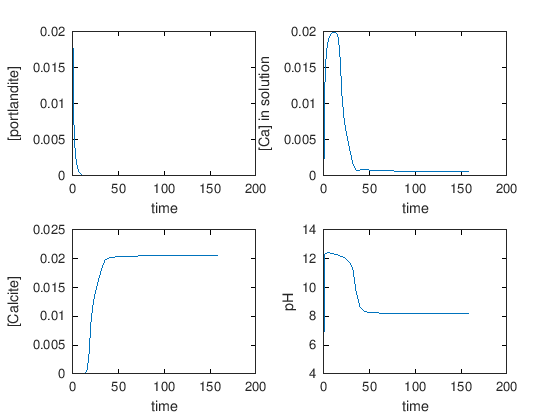

In [23]:

subplot(221); plot(time,portlanditephreeqc); ylabel('[portlandite]'); xlabel('time')
subplot(222); plot(time,Caphreeqc); ylabel('[Ca] in solution'); xlabel('time')
subplot(223); plot(time,calcitephreeqc); ylabel('[Calcite]'); xlabel('time')
subplot(224); plot(time,pHphreeqc); ylabel('pH'); xlabel('time')



In [24]:
% data
%6 g cement small size

data=[...
0.00	5.99	-0.5390	NaN	0.0452
0.10	12.21	-0.3095	12	17.3563
2.00	12.4	-0.3672	6900	15.9543
24.00	12.34	0.0195	8110	7.4363
48.00	11.76	-0.3485	5650	15.1085
72.00	8.01	0.5270	118	0.6850
96.00	7.97	0.5860	142	0.7448
144.00	8.04	0.4990	183	0.6708
];
sampletime=data(:,1); samplepH=data(:,2); sampleDIC=(data(:,3)*1e-3); conduct=data(:,4); sampleCa=(data(:,5)*1e-3); 
sampleSi=(data(:,6)*1e-3);


error: data(_,6): out of bound 5 (dimensions are 8x5)


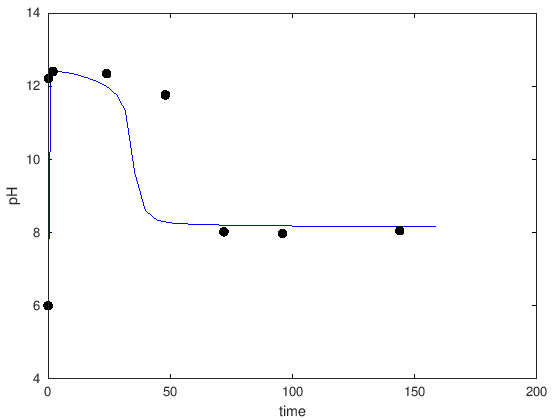

In [25]:
plot(time,pHphreeqc,'b-','linewidth',2); ylabel('pH'); xlabel('time')
hold on
%plot(timeres,pHres,'bo')
plot(sampletime,samplepH,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

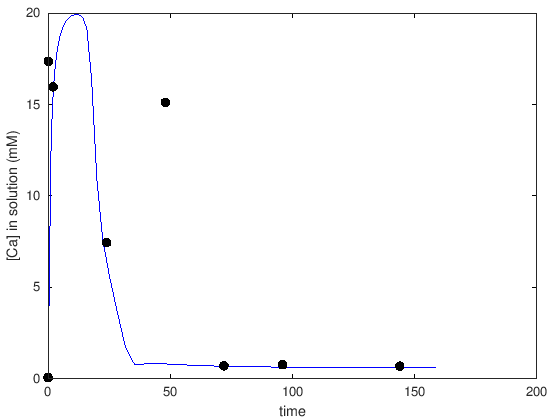

In [26]:
plot(time,(Caphreeqc*1e3),'b-','linewidth',2); ylabel('[Ca] in solution (mM)'); xlabel('time')
hold on
plot(sampletime,(sampleCa*1e3),'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

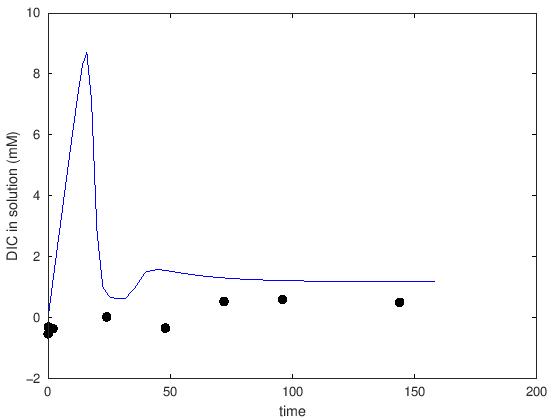

In [27]:
plot(time,1e3*DIC,'b-','linewidth',2); ylabel('DIC in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleDIC*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

error: 'sampleSi' undefined near line 1, column 17


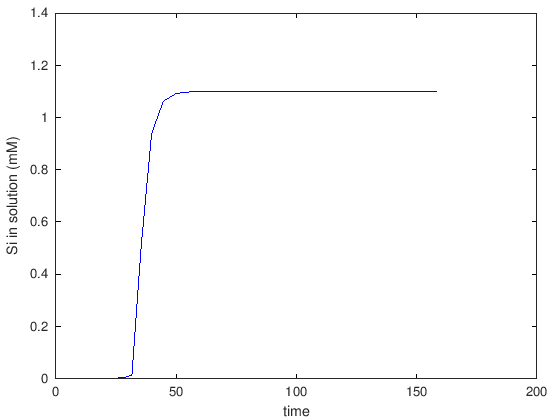

In [28]:
plot(time,1e3*(Siaq),'b-','linewidth',2); ylabel('Si in solution (mM)'); xlabel('time')
hold on
plot(sampletime,sampleSi*1e3,'ko','markersize',8,'markerfacecolor','k')
set(gca,'linewidth',2)

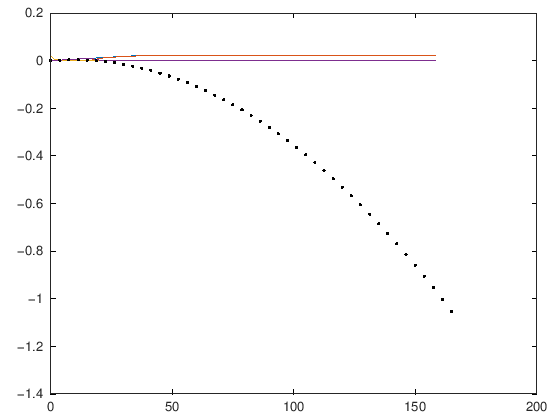

In [29]:
% plot total C that ends up in solution

CTsoln=DIC+calcitephreeqc;

%plot(time,CTsoln,time,calcite,time,port,time,DIC,sampletime,sampleDIC,'r.')
plot(time,CTsoln,time,calcitephreeqc,time,portlanditephreeqc,time,DIC,'linewidth',2)


data=[...
%Time (min)	Time(h)	Carbon dioxide(ppm)	CO2_input (mol)	CO2_out (mol)	△ CO2 consumed (mol)	CO2 capture rate （umol/5 min）	CO2 capture rate （umol/h）	CO2 capture （umol）
0	0	552	6.6700E-05	0.0000E+00	6.6700E-05	6.6700E+01	8.0040E+02	6.6700E+01
5	0.083333333	435	6.6700E-05	6.0417E-07	6.6096E-05	6.6096E+01	7.9315E+02	1.3280E+02
10	0.166666667	295	6.6700E-05	1.2083E-06	6.5492E-05	6.5492E+01	7.8590E+02	1.9829E+02
15	0.25	218	6.6700E-05	1.8125E-06	6.4888E-05	6.4888E+01	7.7865E+02	2.6318E+02
20	0.333333333	148	6.6700E-05	2.4167E-06	6.4283E-05	6.4283E+01	7.7140E+02	3.2746E+02
25	0.416666667	118	6.6700E-05	3.0208E-06	6.3679E-05	6.3679E+01	7.6415E+02	3.9114E+02
30	0.5	84	6.6700E-05	3.6250E-06	6.3075E-05	6.3075E+01	7.5690E+02	4.5421E+02
35	0.583333333	63	6.6700E-05	4.2292E-06	6.2471E-05	6.2471E+01	7.4965E+02	5.1668E+02
40	0.666666667	42	6.6700E-05	4.8333E-06	6.1867E-05	6.1867E+01	7.4240E+02	5.7855E+02
45	0.75	37	6.6700E-05	5.4375E-06	6.1263E-05	6.1263E+01	7.3515E+02	6.3981E+02
50	0.833333333	26	6.6700E-05	6.0417E-06	6.0658E-05	6.0658E+01	7.2790E+02	7.0047E+02
55	0.916666667	15	6.6700E-05	6.6458E-06	6.0054E-05	6.0054E+01	7.2065E+02	7.6053E+02
60	1	22	6.6700E-05	7.2500E-06	5.9450E-05	5.9450E+01	7.1340E+02	8.1998E+02
65	1.083333333	10	6.6700E-05	7.8542E-06	5.8846E-05	5.8846E+01	7.0615E+02	8.7882E+02
70	1.166666667	5	6.6700E-05	8.4583E-06	5.8242E-05	5.8242E+01	6.9890E+02	9.3706E+02
75	1.25	4	6.6700E-05	9.0625E-06	5.7638E-05	5.7638E+01	6.9165E+02	9.9470E+02
80	1.333333333	0	6.6700E-05	9.6667E-06	5.7033E-05	5.7033E+01	6.8440E+02	1.0517E+03
85	1.416666667	0	6.6700E-05	1.0271E-05	5.6429E-05	5.6429E+01	6.7715E+02	1.1082E+03
90	1.5	11	6.6700E-05	1.0875E-05	5.5825E-05	5.5825E+01	6.6990E+02	1.1640E+03
95	1.583333333	0	6.6700E-05	1.1479E-05	5.5221E-05	5.5221E+01	6.6265E+02	1.2192E+03
100	1.666666667	0	6.6700E-05	1.2083E-05	5.4617E-05	5.4617E+01	6.5540E+02	1.2738E+03
105	1.75	0	6.6700E-05	1.2688E-05	5.4013E-05	5.4013E+01	6.4815E+02	1.3278E+03
110	1.833333333	8	6.6700E-05	1.3292E-05	5.3408E-05	5.3408E+01	6.4090E+02	1.3812E+03
115	1.916666667	0	6.6700E-05	1.3896E-05	5.2804E-05	5.2804E+01	6.3365E+02	1.4341E+03
120	2	1	6.6700E-05	1.4500E-05	5.2200E-05	5.2200E+01	6.2640E+02	1.4863E+03
125	2.083333333	0	6.6700E-05	1.5104E-05	5.1596E-05	5.1596E+01	6.1915E+02	1.5378E+03
130	2.166666667	0	6.6700E-05	1.5708E-05	5.0992E-05	5.0992E+01	6.1190E+02	1.5888E+03
135	2.25	0	6.6700E-05	1.6313E-05	5.0388E-05	5.0388E+01	6.0465E+02	1.6392E+03
140	2.333333333	0	6.6700E-05	1.6917E-05	4.9783E-05	4.9783E+01	5.9740E+02	1.6890E+03
145	2.416666667	0	6.6700E-05	1.7521E-05	4.9179E-05	4.9179E+01	5.9015E+02	1.7382E+03
150	2.5	4	6.6700E-05	1.8125E-05	4.8575E-05	4.8575E+01	5.8290E+02	1.7868E+03
155	2.583333333	0	6.6700E-05	1.8729E-05	4.7971E-05	4.7971E+01	5.7565E+02	1.8347E+03
160	2.666666667	0	6.6700E-05	1.9333E-05	4.7367E-05	4.7367E+01	5.6840E+02	1.8821E+03
165	2.75	0	6.6700E-05	1.9938E-05	4.6763E-05	4.6763E+01	5.6115E+02	1.9289E+03
170	2.833333333	4	6.6700E-05	2.0542E-05	4.6158E-05	4.6158E+01	5.5390E+02	1.9750E+03
175	2.916666667	0	6.6700E-05	2.1146E-05	4.5554E-05	4.5554E+01	5.4665E+02	2.0206E+03
180	3	0	6.6700E-05	2.1750E-05	4.4950E-05	4.4950E+01	5.3940E+02	2.0655E+03
185	3.083333333	5	6.6700E-05	2.2354E-05	4.4346E-05	4.4346E+01	5.3215E+02	2.1099E+03
190	3.166666667	0	6.6700E-05	2.2958E-05	4.3742E-05	4.3742E+01	5.2490E+02	2.1536E+03
195	3.25	0	6.6700E-05	2.3563E-05	4.3138E-05	4.3138E+01	5.1765E+02	2.1968E+03
200	3.333333333	0	6.6700E-05	2.4167E-05	4.2533E-05	4.2533E+01	5.1040E+02	2.2393E+03
205	3.416666667	0	6.6700E-05	2.4771E-05	4.1929E-05	4.1929E+01	5.0315E+02	2.2812E+03
210	3.5	0	6.6700E-05	2.5375E-05	4.1325E-05	4.1325E+01	4.9590E+02	2.3225E+03
215	3.583333333	0	6.6700E-05	2.5979E-05	4.0721E-05	4.0721E+01	4.8865E+02	2.3633E+03
220	3.666666667	0	6.6700E-05	2.6583E-05	4.0117E-05	4.0117E+01	4.8140E+02	2.4034E+03
225	3.75	0	6.6700E-05	2.7188E-05	3.9513E-05	3.9513E+01	4.7415E+02	2.4429E+03
230	3.833333333	0	6.6700E-05	2.7792E-05	3.8908E-05	3.8908E+01	4.6690E+02	2.4818E+03
235	3.916666667	0	6.6700E-05	2.8396E-05	3.8304E-05	3.8304E+01	4.5965E+02	2.5201E+03
240	4	0	6.6700E-05	2.9000E-05	3.7700E-05	3.7700E+01	4.5240E+02	2.5578E+03
245	4.083333333	5	6.6700E-05	2.9604E-05	3.7096E-05	3.7096E+01	4.4515E+02	2.5949E+03
250	4.166666667	4	6.6700E-05	3.0208E-05	3.6492E-05	3.6492E+01	4.3790E+02	2.6314E+03
255	4.25	0	6.6700E-05	3.0813E-05	3.5888E-05	3.5888E+01	4.3065E+02	2.6673E+03
260	4.333333333	2	6.6700E-05	3.1417E-05	3.5283E-05	3.5283E+01	4.2340E+02	2.7026E+03
265	4.416666667	0	6.6700E-05	3.2021E-05	3.4679E-05	3.4679E+01	4.1615E+02	2.7372E+03
270	4.5	0	6.6700E-05	3.2625E-05	3.4075E-05	3.4075E+01	4.0890E+02	2.7713E+03
275	4.583333333	6	6.6700E-05	3.3229E-05	3.3471E-05	3.3471E+01	4.0165E+02	2.8048E+03
280	4.666666667	6	6.6700E-05	3.3833E-05	3.2867E-05	3.2867E+01	3.9440E+02	2.8377E+03
285	4.75	2	6.6700E-05	3.4438E-05	3.2263E-05	3.2263E+01	3.8715E+02	2.8699E+03
290	4.833333333	0	6.6700E-05	3.5042E-05	3.1658E-05	3.1658E+01	3.7990E+02	2.9016E+03
295	4.916666667	1	6.6700E-05	3.5646E-05	3.1054E-05	3.1054E+01	3.7265E+02	2.9326E+03
300	5	12	6.6700E-05	3.6250E-05	3.0450E-05	3.0450E+01	3.6540E+02	2.9631E+03
305	5.083333333	0	6.6700E-05	3.6854E-05	2.9846E-05	2.9846E+01	3.5815E+02	2.9929E+03
310	5.166666667	0	6.6700E-05	3.7458E-05	2.9242E-05	2.9242E+01	3.5090E+02	3.0222E+03
315	5.25	2	6.6700E-05	3.8063E-05	2.8638E-05	2.8638E+01	3.4365E+02	3.0508E+03
320	5.333333333	0	6.6700E-05	3.8667E-05	2.8033E-05	2.8033E+01	3.3640E+02	3.0788E+03
325	5.416666667	0	6.6700E-05	3.9271E-05	2.7429E-05	2.7429E+01	3.2915E+02	3.1063E+03
330	5.5	2	6.6700E-05	3.9875E-05	2.6825E-05	2.6825E+01	3.2190E+02	3.1331E+03
335	5.583333333	1	6.6700E-05	4.0479E-05	2.6221E-05	2.6221E+01	3.1465E+02	3.1593E+03
340	5.666666667	0	6.6700E-05	4.1083E-05	2.5617E-05	2.5617E+01	3.0740E+02	3.1849E+03
345	5.75	3	6.6700E-05	4.1688E-05	2.5013E-05	2.5013E+01	3.0015E+02	3.2099E+03
350	5.833333333	10	6.6700E-05	4.2292E-05	2.4408E-05	2.4408E+01	2.9290E+02	3.2343E+03
355	5.916666667	7	6.6700E-05	4.2896E-05	2.3804E-05	2.3804E+01	2.8565E+02	3.2582E+03
360	6	0	6.6700E-05	4.3500E-05	2.3200E-05	2.3200E+01	2.7840E+02	3.2814E+03
365	6.083333333	0	6.6700E-05	4.4104E-05	2.2596E-05	2.2596E+01	2.7115E+02	3.3039E+03
370	6.166666667	0	6.6700E-05	4.4708E-05	2.1992E-05	2.1992E+01	2.6390E+02	3.3259E+03
375	6.25	6	6.6700E-05	4.5313E-05	2.1388E-05	2.1388E+01	2.5665E+02	3.3473E+03
380	6.333333333	2	6.6700E-05	4.5917E-05	2.0783E-05	2.0783E+01	2.4940E+02	3.3681E+03
385	6.416666667	0	6.6700E-05	4.6521E-05	2.0179E-05	2.0179E+01	2.4215E+02	3.3883E+03
390	6.5	8	6.6700E-05	4.7125E-05	1.9575E-05	1.9575E+01	2.3490E+02	3.4079E+03
395	6.583333333	3	6.6700E-05	4.7729E-05	1.8971E-05	1.8971E+01	2.2765E+02	3.4268E+03
400	6.666666667	8	6.6700E-05	4.8333E-05	1.8367E-05	1.8367E+01	2.2040E+02	3.4452E+03
405	6.75	2	6.6700E-05	4.8938E-05	1.7763E-05	1.7763E+01	2.1315E+02	3.4630E+03
410	6.833333333	7	6.6700E-05	4.9542E-05	1.7158E-05	1.7158E+01	2.0590E+02	3.4801E+03
415	6.916666667	1	6.6700E-05	5.0146E-05	1.6554E-05	1.6554E+01	1.9865E+02	3.4967E+03
420	7	3	6.6700E-05	5.0750E-05	1.5950E-05	1.5950E+01	1.9140E+02	3.5126E+03
425	7.083333333	5	6.6700E-05	5.1354E-05	1.5346E-05	1.5346E+01	1.8415E+02	3.5280E+03
430	7.166666667	0	6.6700E-05	5.1958E-05	1.4742E-05	1.4742E+01	1.7690E+02	3.5427E+03
435	7.25	2	6.6700E-05	5.2563E-05	1.4138E-05	1.4138E+01	1.6965E+02	3.5569E+03
440	7.333333333	6	6.6700E-05	5.3167E-05	1.3533E-05	1.3533E+01	1.6240E+02	3.5704E+03
445	7.416666667	1	6.6700E-05	5.3771E-05	1.2929E-05	1.2929E+01	1.5515E+02	3.5833E+03
450	7.5	1	6.6700E-05	5.4375E-05	1.2325E-05	1.2325E+01	1.4790E+02	3.5956E+03
455	7.583333333	0	6.6700E-05	5.4979E-05	1.1721E-05	1.1721E+01	1.4065E+02	3.6074E+03
460	7.666666667	7	6.6700E-05	5.5583E-05	1.1117E-05	1.1117E+01	1.3340E+02	3.6185E+03
465	7.75	3	6.6700E-05	5.6188E-05	1.0513E-05	1.0513E+01	1.2615E+02	3.6290E+03
470	7.833333333	10	6.6700E-05	5.6792E-05	9.9083E-06	9.9083E+00	1.1890E+02	3.6389E+03
475	7.916666667	0	6.6700E-05	5.7396E-05	9.3042E-06	9.3042E+00	1.1165E+02	3.6482E+03
480	8	11	6.6700E-05	5.8000E-05	8.7000E-06	8.7000E+00	1.0440E+02	3.6569E+03
485	8.083333333	5	6.6700E-05	5.8604E-05	8.0958E-06	8.0958E+00	9.7150E+01	3.6650E+03
490	8.166666667	1	6.6700E-05	5.9208E-05	7.4917E-06	7.4917E+00	8.9900E+01	3.6725E+03
495	8.25	6	6.6700E-05	5.9813E-05	6.8875E-06	6.8875E+00	8.2650E+01	3.6794E+03
500	8.333333333	5	6.6700E-05	6.0417E-05	6.2833E-06	6.2833E+00	7.5400E+01	3.6857E+03
505	8.416666667	14	6.6700E-05	6.1021E-05	5.6792E-06	5.6792E+00	6.8150E+01	3.6913E+03
510	8.5	13	6.6700E-05	6.1625E-05	5.0750E-06	5.0750E+00	6.0900E+01	3.6964E+03
515	8.583333333	1	6.6700E-05	6.2229E-05	4.4708E-06	4.4708E+00	5.3650E+01	3.7009E+03
520	8.666666667	9	6.6700E-05	6.2833E-05	3.8667E-06	3.8667E+00	4.6400E+01	3.7048E+03
525	8.75	14	6.6700E-05	6.3438E-05	3.2625E-06	3.2625E+00	3.9150E+01	3.7080E+03
530	8.833333333	4	6.6700E-05	6.4042E-05	2.6583E-06	2.6583E+00	3.1900E+01	3.7107E+03
535	8.916666667	6	6.6700E-05	6.4646E-05	2.0542E-06	2.0542E+00	2.4650E+01	3.7127E+03
540	9	5	6.6700E-05	6.5250E-05	1.4500E-06	1.4500E+00	1.7400E+01	3.7142E+03
545	9.083333333	7	6.6700E-05	6.5854E-05	8.4583E-07	8.4583E-01	1.0150E+01	3.7150E+03
550	9.166666667	10	6.6700E-05	6.6458E-05	2.4167E-07	2.4167E-01	2.9000E+00	3.7153E+03
555	9.25	7	6.6700E-05	6.7063E-05	-3.6250E-07	-3.6250E-01	-4.3500E+00	3.7149E+03
560	9.333333333	11	6.6700E-05	6.7667E-05	-9.6667E-07	-9.6667E-01	-1.1600E+01	3.7139E+03
565	9.416666667	7	6.6700E-05	6.8271E-05	-1.5708E-06	-1.5708E+00	-1.8850E+01	3.7124E+03
570	9.5	11	6.6700E-05	6.8875E-05	-2.1750E-06	-2.1750E+00	-2.6100E+01	3.7102E+03
575	9.583333333	7	6.6700E-05	6.9479E-05	-2.7792E-06	-2.7792E+00	-3.3350E+01	3.7074E+03
580	9.666666667	14	6.6700E-05	7.0083E-05	-3.3833E-06	-3.3833E+00	-4.0600E+01	3.7040E+03
585	9.75	10	6.6700E-05	7.0688E-05	-3.9875E-06	-3.9875E+00	-4.7850E+01	3.7000E+03
590	9.833333333	5	6.6700E-05	7.1292E-05	-4.5917E-06	-4.5917E+00	-5.5100E+01	3.6954E+03
595	9.916666667	8	6.6700E-05	7.1896E-05	-5.1958E-06	-5.1958E+00	-6.2350E+01	3.6903E+03
600	10	5	6.6700E-05	7.2500E-05	-5.8000E-06	-5.8000E+00	-6.9600E+01	3.6845E+03
605	10.08333333	9	6.6700E-05	7.3104E-05	-6.4042E-06	-6.4042E+00	-7.6850E+01	3.6780E+03
610	10.16666667	9	6.6700E-05	7.3708E-05	-7.0083E-06	-7.0083E+00	-8.4100E+01	3.6710E+03
615	10.25	7	6.6700E-05	7.4313E-05	-7.6125E-06	-7.6125E+00	-9.1350E+01	3.6634E+03
620	10.33333333	10	6.6700E-05	7.4917E-05	-8.2167E-06	-8.2167E+00	-9.8600E+01	3.6552E+03
625	10.41666667	11	6.6700E-05	7.5521E-05	-8.8208E-06	-8.8208E+00	-1.0585E+02	3.6464E+03
630	10.5	9	6.6700E-05	7.6125E-05	-9.4250E-06	-9.4250E+00	-1.1310E+02	3.6370E+03
635	10.58333333	10	6.6700E-05	7.6729E-05	-1.0029E-05	-1.0029E+01	-1.2035E+02	3.6269E+03
640	10.66666667	12	6.6700E-05	7.7333E-05	-1.0633E-05	-1.0633E+01	-1.2760E+02	3.6163E+03
645	10.75	13	6.6700E-05	7.7938E-05	-1.1238E-05	-1.1238E+01	-1.3485E+02	3.6051E+03
650	10.83333333	1	6.6700E-05	7.8542E-05	-1.1842E-05	-1.1842E+01	-1.4210E+02	3.5932E+03
655	10.91666667	9	6.6700E-05	7.9146E-05	-1.2446E-05	-1.2446E+01	-1.4935E+02	3.5808E+03
660	11	11	6.6700E-05	7.9750E-05	-1.3050E-05	-1.3050E+01	-1.5660E+02	3.5677E+03
665	11.08333333	11	6.6700E-05	8.0354E-05	-1.3654E-05	-1.3654E+01	-1.6385E+02	3.5541E+03
670	11.16666667	16	6.6700E-05	8.0958E-05	-1.4258E-05	-1.4258E+01	-1.7110E+02	3.5398E+03
675	11.25	19	6.6700E-05	8.1563E-05	-1.4863E-05	-1.4863E+01	-1.7835E+02	3.5250E+03
680	11.33333333	12	6.6700E-05	8.2167E-05	-1.5467E-05	-1.5467E+01	-1.8560E+02	3.5095E+03
685	11.41666667	18	6.6700E-05	8.2771E-05	-1.6071E-05	-1.6071E+01	-1.9285E+02	3.4934E+03
690	11.5	19	6.6700E-05	8.3375E-05	-1.6675E-05	-1.6675E+01	-2.0010E+02	3.4767E+03
695	11.58333333	0	6.6700E-05	8.3979E-05	-1.7279E-05	-1.7279E+01	-2.0735E+02	3.4595E+03
700	11.66666667	13	6.6700E-05	8.4583E-05	-1.7883E-05	-1.7883E+01	-2.1460E+02	3.4416E+03
705	11.75	15	6.6700E-05	8.5188E-05	-1.8488E-05	-1.8488E+01	-2.2185E+02	3.4231E+03
710	11.83333333	18	6.6700E-05	8.5792E-05	-1.9092E-05	-1.9092E+01	-2.2910E+02	3.4040E+03
715	11.91666667	11	6.6700E-05	8.6396E-05	-1.9696E-05	-1.9696E+01	-2.3635E+02	3.3843E+03
720	12	12	6.6700E-05	8.7000E-05	-2.0300E-05	-2.0300E+01	-2.4360E+02	3.3640E+03
725	12.08333333	8	6.6700E-05	8.7604E-05	-2.0904E-05	-2.0904E+01	-2.5085E+02	3.3431E+03
730	12.16666667	11	6.6700E-05	8.8208E-05	-2.1508E-05	-2.1508E+01	-2.5810E+02	3.3216E+03
735	12.25	9	6.6700E-05	8.8813E-05	-2.2113E-05	-2.2113E+01	-2.6535E+02	3.2995E+03
740	12.33333333	1	6.6700E-05	8.9417E-05	-2.2717E-05	-2.2717E+01	-2.7260E+02	3.2768E+03
745	12.41666667	16	6.6700E-05	9.0021E-05	-2.3321E-05	-2.3321E+01	-2.7985E+02	3.2534E+03
750	12.5	11	6.6700E-05	9.0625E-05	-2.3925E-05	-2.3925E+01	-2.8710E+02	3.2295E+03
755	12.58333333	10	6.6700E-05	9.1229E-05	-2.4529E-05	-2.4529E+01	-2.9435E+02	3.2050E+03
760	12.66666667	15	6.6700E-05	9.1833E-05	-2.5133E-05	-2.5133E+01	-3.0160E+02	3.1799E+03
765	12.75	13	6.6700E-05	9.2438E-05	-2.5738E-05	-2.5738E+01	-3.0885E+02	3.1541E+03
770	12.83333333	11	6.6700E-05	9.3042E-05	-2.6342E-05	-2.6342E+01	-3.1610E+02	3.1278E+03
775	12.91666667	6	6.6700E-05	9.3646E-05	-2.6946E-05	-2.6946E+01	-3.2335E+02	3.1008E+03
780	13	18	6.6700E-05	9.4250E-05	-2.7550E-05	-2.7550E+01	-3.3060E+02	3.0733E+03
785	13.08333333	12	6.6700E-05	9.4854E-05	-2.8154E-05	-2.8154E+01	-3.3785E+02	3.0451E+03
790	13.16666667	21	6.6700E-05	9.5458E-05	-2.8758E-05	-2.8758E+01	-3.4510E+02	3.0164E+03
795	13.25	19	6.6700E-05	9.6063E-05	-2.9363E-05	-2.9363E+01	-3.5235E+02	2.9870E+03
800	13.33333333	10	6.6700E-05	9.6667E-05	-2.9967E-05	-2.9967E+01	-3.5960E+02	2.9570E+03
805	13.41666667	18	6.6700E-05	9.7271E-05	-3.0571E-05	-3.0571E+01	-3.6685E+02	2.9265E+03
810	13.5	9	6.6700E-05	9.7875E-05	-3.1175E-05	-3.1175E+01	-3.7410E+02	2.8953E+03
815	13.58333333	16	6.6700E-05	9.8479E-05	-3.1779E-05	-3.1779E+01	-3.8135E+02	2.8635E+03
820	13.66666667	13	6.6700E-05	9.9083E-05	-3.2383E-05	-3.2383E+01	-3.8860E+02	2.8311E+03
825	13.75	9	6.6700E-05	9.9688E-05	-3.2988E-05	-3.2988E+01	-3.9585E+02	2.7981E+03
830	13.83333333	10	6.6700E-05	1.0029E-04	-3.3592E-05	-3.3592E+01	-4.0310E+02	2.7645E+03
835	13.91666667	20	6.6700E-05	1.0090E-04	-3.4196E-05	-3.4196E+01	-4.1035E+02	2.7304E+03
840	14	15	6.6700E-05	1.0150E-04	-3.4800E-05	-3.4800E+01	-4.1760E+02	2.6956E+03
845	14.08333333	14	6.6700E-05	1.0210E-04	-3.5404E-05	-3.5404E+01	-4.2485E+02	2.6601E+03
850	14.16666667	16	6.6700E-05	1.0271E-04	-3.6008E-05	-3.6008E+01	-4.3210E+02	2.6241E+03
855	14.25	18	6.6700E-05	1.0331E-04	-3.6613E-05	-3.6613E+01	-4.3935E+02	2.5875E+03
860	14.33333333	23	6.6700E-05	1.0392E-04	-3.7217E-05	-3.7217E+01	-4.4660E+02	2.5503E+03
865	14.41666667	16	6.6700E-05	1.0452E-04	-3.7821E-05	-3.7821E+01	-4.5385E+02	2.5125E+03
870	14.5	10	6.6700E-05	1.0513E-04	-3.8425E-05	-3.8425E+01	-4.6110E+02	2.4741E+03
875	14.58333333	19	6.6700E-05	1.0573E-04	-3.9029E-05	-3.9029E+01	-4.6835E+02	2.4350E+03
880	14.66666667	18	6.6700E-05	1.0633E-04	-3.9633E-05	-3.9633E+01	-4.7560E+02	2.3954E+03
885	14.75	18	6.6700E-05	1.0694E-04	-4.0238E-05	-4.0238E+01	-4.8285E+02	2.3552E+03
890	14.83333333	25	6.6700E-05	1.0754E-04	-4.0842E-05	-4.0842E+01	-4.9010E+02	2.3143E+03
895	14.91666667	16	6.6700E-05	1.0815E-04	-4.1446E-05	-4.1446E+01	-4.9735E+02	2.2729E+03
900	15	23	6.6700E-05	1.0875E-04	-4.2050E-05	-4.2050E+01	-5.0460E+02	2.2308E+03
905	15.08333333	14	6.6700E-05	1.0935E-04	-4.2654E-05	-4.2654E+01	-5.1185E+02	2.1882E+03
910	15.16666667	20	6.6700E-05	1.0996E-04	-4.3258E-05	-4.3258E+01	-5.1910E+02	2.1449E+03
915	15.25	15	6.6700E-05	1.1056E-04	-4.3863E-05	-4.3863E+01	-5.2635E+02	2.1010E+03
920	15.33333333	15	6.6700E-05	1.1117E-04	-4.4467E-05	-4.4467E+01	-5.3360E+02	2.0566E+03
925	15.41666667	14	6.6700E-05	1.1177E-04	-4.5071E-05	-4.5071E+01	-5.4085E+02	2.0115E+03
930	15.5	15	6.6700E-05	1.1238E-04	-4.5675E-05	-4.5675E+01	-5.4810E+02	1.9658E+03
935	15.58333333	14	6.6700E-05	1.1298E-04	-4.6279E-05	-4.6279E+01	-5.5535E+02	1.9196E+03
940	15.66666667	23	6.6700E-05	1.1358E-04	-4.6883E-05	-4.6883E+01	-5.6260E+02	1.8727E+03
945	15.75	23	6.6700E-05	1.1419E-04	-4.7488E-05	-4.7488E+01	-5.6985E+02	1.8252E+03
950	15.83333333	21	6.6700E-05	1.1479E-04	-4.8092E-05	-4.8092E+01	-5.7710E+02	1.7771E+03
955	15.91666667	15	6.6700E-05	1.1540E-04	-4.8696E-05	-4.8696E+01	-5.8435E+02	1.7284E+03
960	16	28	6.6700E-05	1.1600E-04	-4.9300E-05	-4.9300E+01	-5.9160E+02	1.6791E+03
965	16.08333333	14	6.6700E-05	1.1660E-04	-4.9904E-05	-4.9904E+01	-5.9885E+02	1.6292E+03
970	16.16666667	24	6.6700E-05	1.1721E-04	-5.0508E-05	-5.0508E+01	-6.0610E+02	1.5787E+03
975	16.25	18	6.6700E-05	1.1781E-04	-5.1113E-05	-5.1113E+01	-6.1335E+02	1.5276E+03
980	16.33333333	24	6.6700E-05	1.1842E-04	-5.1717E-05	-5.1717E+01	-6.2060E+02	1.4759E+03
985	16.41666667	16	6.6700E-05	1.1902E-04	-5.2321E-05	-5.2321E+01	-6.2785E+02	1.4235E+03
990	16.5	26	6.6700E-05	1.1963E-04	-5.2925E-05	-5.2925E+01	-6.3510E+02	1.3706E+03
995	16.58333333	26	6.6700E-05	1.2023E-04	-5.3529E-05	-5.3529E+01	-6.4235E+02	1.3171E+03
1000	16.66666667	17	6.6700E-05	1.2083E-04	-5.4133E-05	-5.4133E+01	-6.4960E+02	1.2629E+03
1005	16.75	24	6.6700E-05	1.2144E-04	-5.4738E-05	-5.4738E+01	-6.5685E+02	1.2082E+03
1010	16.83333333	25	6.6700E-05	1.2204E-04	-5.5342E-05	-5.5342E+01	-6.6410E+02	1.1529E+03
1015	16.91666667	18	6.6700E-05	1.2265E-04	-5.5946E-05	-5.5946E+01	-6.7135E+02	1.0969E+03
1020	17	17	6.6700E-05	1.2325E-04	-5.6550E-05	-5.6550E+01	-6.7860E+02	1.0404E+03
1025	17.08333333	13	6.6700E-05	1.2385E-04	-5.7154E-05	-5.7154E+01	-6.8585E+02	9.8322E+02
1030	17.16666667	13	6.6700E-05	1.2446E-04	-5.7758E-05	-5.7758E+01	-6.9310E+02	9.2546E+02
1035	17.25	18	6.6700E-05	1.2506E-04	-5.8363E-05	-5.8363E+01	-7.0035E+02	8.6710E+02
1040	17.33333333	20	6.6700E-05	1.2567E-04	-5.8967E-05	-5.8967E+01	-7.0760E+02	8.0813E+02
1045	17.41666667	24	6.6700E-05	1.2627E-04	-5.9571E-05	-5.9571E+01	-7.1485E+02	7.4856E+02
1050	17.5	15	6.6700E-05	1.2688E-04	-6.0175E-05	-6.0175E+01	-7.2210E+02	6.8839E+02
1055	17.58333333	26	6.6700E-05	1.2748E-04	-6.0779E-05	-6.0779E+01	-7.2935E+02	6.2761E+02
1060	17.66666667	28	6.6700E-05	1.2808E-04	-6.1383E-05	-6.1383E+01	-7.3660E+02	5.6622E+02
1065	17.75	15	6.6700E-05	1.2869E-04	-6.1988E-05	-6.1988E+01	-7.4385E+02	5.0424E+02
1070	17.83333333	22	6.6700E-05	1.2929E-04	-6.2592E-05	-6.2592E+01	-7.5110E+02	4.4165E+02
1075	17.91666667	17	6.6700E-05	1.2990E-04	-6.3196E-05	-6.3196E+01	-7.5835E+02	3.7845E+02
1080	18	21	6.6700E-05	1.3050E-04	-6.3800E-05	-6.3800E+01	-7.6560E+02	3.1465E+02
1085	18.08333333	21	6.6700E-05	1.3110E-04	-6.4404E-05	-6.4404E+01	-7.7285E+02	2.5025E+02
1090	18.16666667	18	6.6700E-05	1.3171E-04	-6.5008E-05	-6.5008E+01	-7.8010E+02	1.8524E+02
1095	18.25	26	6.6700E-05	1.3231E-04	-6.5613E-05	-6.5613E+01	-7.8735E+02	1.1962E+02
1100	18.33333333	20	6.6700E-05	1.3292E-04	-6.6217E-05	-6.6217E+01	-7.9460E+02	5.3408E+01
1105	18.41666667	33	6.6700E-05	1.3352E-04	-6.6821E-05	-6.6821E+01	-8.0185E+02	-1.3413E+01
1110	18.5	25	6.6700E-05	1.3413E-04	-6.7425E-05	-6.7425E+01	-8.0910E+02	-8.0838E+01
1115	18.58333333	17	6.6700E-05	1.3473E-04	-6.8029E-05	-6.8029E+01	-8.1635E+02	-1.4887E+02
1120	18.66666667	23	6.6700E-05	1.3533E-04	-6.8633E-05	-6.8633E+01	-8.2360E+02	-2.1750E+02
1125	18.75	20	6.6700E-05	1.3594E-04	-6.9238E-05	-6.9238E+01	-8.3085E+02	-2.8674E+02
1130	18.83333333	18	6.6700E-05	1.3654E-04	-6.9842E-05	-6.9842E+01	-8.3810E+02	-3.5658E+02
1135	18.91666667	24	6.6700E-05	1.3715E-04	-7.0446E-05	-7.0446E+01	-8.4535E+02	-4.2703E+02
1140	19	33	6.6700E-05	1.3775E-04	-7.1050E-05	-7.1050E+01	-8.5260E+02	-4.9808E+02
1145	19.08333333	16	6.6700E-05	1.3835E-04	-7.1654E-05	-7.1654E+01	-8.5985E+02	-5.6973E+02
1150	19.16666667	16	6.6700E-05	1.3896E-04	-7.2258E-05	-7.2258E+01	-8.6710E+02	-6.4199E+02
1155	19.25	18	6.6700E-05	1.3956E-04	-7.2863E-05	-7.2863E+01	-8.7435E+02	-7.1485E+02
1160	19.33333333	20	6.6700E-05	1.4017E-04	-7.3467E-05	-7.3467E+01	-8.8160E+02	-7.8832E+02
1165	19.41666667	18	6.6700E-05	1.4077E-04	-7.4071E-05	-7.4071E+01	-8.8885E+02	-8.6239E+02
1170	19.5	27	6.6700E-05	1.4138E-04	-7.4675E-05	-7.4675E+01	-8.9610E+02	-9.3706E+02
1175	19.58333333	20	6.6700E-05	1.4198E-04	-7.5279E-05	-7.5279E+01	-9.0335E+02	-1.0123E+03
1180	19.66666667	16	6.6700E-05	1.4258E-04	-7.5883E-05	-7.5883E+01	-9.1060E+02	-1.0882E+03
1185	19.75	20	6.6700E-05	1.4319E-04	-7.6488E-05	-7.6488E+01	-9.1785E+02	-1.1647E+03
1190	19.83333333	18	6.6700E-05	1.4379E-04	-7.7092E-05	-7.7092E+01	-9.2510E+02	-1.2418E+03
1195	19.91666667	24	6.6700E-05	1.4440E-04	-7.7696E-05	-7.7696E+01	-9.3235E+02	-1.3195E+03
1200	20	14	6.6700E-05	1.4500E-04	-7.8300E-05	-7.8300E+01	-9.3960E+02	-1.3978E+03
1205	20.08333333	17	6.6700E-05	1.4560E-04	-7.8904E-05	-7.8904E+01	-9.4685E+02	-1.4767E+03
1210	20.16666667	24	6.6700E-05	1.4621E-04	-7.9508E-05	-7.9508E+01	-9.5410E+02	-1.5562E+03
1215	20.25	22	6.6700E-05	1.4681E-04	-8.0113E-05	-8.0113E+01	-9.6135E+02	-1.6363E+03
1220	20.33333333	33	6.6700E-05	1.4742E-04	-8.0717E-05	-8.0717E+01	-9.6860E+02	-1.7170E+03
1225	20.41666667	25	6.6700E-05	1.4802E-04	-8.1321E-05	-8.1321E+01	-9.7585E+02	-1.7984E+03
1230	20.5	23	6.6700E-05	1.4863E-04	-8.1925E-05	-8.1925E+01	-9.8310E+02	-1.8803E+03
1235	20.58333333	20	6.6700E-05	1.4923E-04	-8.2529E-05	-8.2529E+01	-9.9035E+02	-1.9628E+03
1240	20.66666667	28	6.6700E-05	1.4983E-04	-8.3133E-05	-8.3133E+01	-9.9760E+02	-2.0460E+03
1245	20.75	23	6.6700E-05	1.5044E-04	-8.3738E-05	-8.3738E+01	-1.0049E+03	-2.1297E+03
1250	20.83333333	17	6.6700E-05	1.5104E-04	-8.4342E-05	-8.4342E+01	-1.0121E+03	-2.2140E+03
1255	20.91666667	36	6.6700E-05	1.5165E-04	-8.4946E-05	-8.4946E+01	-1.0194E+03	-2.2990E+03
1260	21	27	6.6700E-05	1.5225E-04	-8.5550E-05	-8.5550E+01	-1.0266E+03	-2.3845E+03
1265	21.08333333	18	6.6700E-05	1.5285E-04	-8.6154E-05	-8.6154E+01	-1.0339E+03	-2.4707E+03
1270	21.16666667	20	6.6700E-05	1.5346E-04	-8.6758E-05	-8.6758E+01	-1.0411E+03	-2.5574E+03
1275	21.25	20	6.6700E-05	1.5406E-04	-8.7363E-05	-8.7363E+01	-1.0484E+03	-2.6448E+03
1280	21.33333333	19	6.6700E-05	1.5467E-04	-8.7967E-05	-8.7967E+01	-1.0556E+03	-2.7328E+03
1285	21.41666667	26	6.6700E-05	1.5527E-04	-8.8571E-05	-8.8571E+01	-1.0629E+03	-2.8213E+03
1290	21.5	26	6.6700E-05	1.5588E-04	-8.9175E-05	-8.9175E+01	-1.0701E+03	-2.9105E+03
1295	21.58333333	32	6.6700E-05	1.5648E-04	-8.9779E-05	-8.9779E+01	-1.0774E+03	-3.0003E+03
1300	21.66666667	22	6.6700E-05	1.5708E-04	-9.0383E-05	-9.0383E+01	-1.0846E+03	-3.0907E+03
1305	21.75	22	6.6700E-05	1.5769E-04	-9.0988E-05	-9.0988E+01	-1.0919E+03	-3.1817E+03
1310	21.83333333	23	6.6700E-05	1.5829E-04	-9.1592E-05	-9.1592E+01	-1.0991E+03	-3.2733E+03
1315	21.91666667	25	6.6700E-05	1.5890E-04	-9.2196E-05	-9.2196E+01	-1.1064E+03	-3.3655E+03
1320	22	25	6.6700E-05	1.5950E-04	-9.2800E-05	-9.2800E+01	-1.1136E+03	-3.4583E+03
1325	22.08333333	34	6.6700E-05	1.6010E-04	-9.3404E-05	-9.3404E+01	-1.1209E+03	-3.5517E+03
1330	22.16666667	28	6.6700E-05	1.6071E-04	-9.4008E-05	-9.4008E+01	-1.1281E+03	-3.6457E+03
1335	22.25	21	6.6700E-05	1.6131E-04	-9.4613E-05	-9.4613E+01	-1.1354E+03	-3.7403E+03
1340	22.33333333	16	6.6700E-05	1.6192E-04	-9.5217E-05	-9.5217E+01	-1.1426E+03	-3.8355E+03
1345	22.41666667	20	6.6700E-05	1.6252E-04	-9.5821E-05	-9.5821E+01	-1.1499E+03	-3.9313E+03
1350	22.5	27	6.6700E-05	1.6313E-04	-9.6425E-05	-9.6425E+01	-1.1571E+03	-4.0277E+03
1355	22.58333333	25	6.6700E-05	1.6373E-04	-9.7029E-05	-9.7029E+01	-1.1644E+03	-4.1248E+03
1360	22.66666667	13	6.6700E-05	1.6433E-04	-9.7633E-05	-9.7633E+01	-1.1716E+03	-4.2224E+03
1365	22.75	22	6.6700E-05	1.6494E-04	-9.8238E-05	-9.8238E+01	-1.1789E+03	-4.3206E+03
1370	22.83333333	30	6.6700E-05	1.6554E-04	-9.8842E-05	-9.8842E+01	-1.1861E+03	-4.4195E+03
1375	22.91666667	23	6.6700E-05	1.6615E-04	-9.9446E-05	-9.9446E+01	-1.1934E+03	-4.5189E+03
1380	23	31	6.6700E-05	1.6675E-04	-1.0005E-04	-1.0005E+02	-1.2006E+03	-4.6190E+03
1385	23.08333333	27	6.6700E-05	1.6735E-04	-1.0065E-04	-1.0065E+02	-1.2079E+03	-4.7196E+03
1390	23.16666667	35	6.6700E-05	1.6796E-04	-1.0126E-04	-1.0126E+02	-1.2151E+03	-4.8209E+03
1395	23.25	31	6.6700E-05	1.6856E-04	-1.0186E-04	-1.0186E+02	-1.2224E+03	-4.9228E+03
1400	23.33333333	23	6.6700E-05	1.6917E-04	-1.0247E-04	-1.0247E+02	-1.2296E+03	-5.0252E+03
1405	23.41666667	32	6.6700E-05	1.6977E-04	-1.0307E-04	-1.0307E+02	-1.2369E+03	-5.1283E+03
1410	23.5	20	6.6700E-05	1.7038E-04	-1.0368E-04	-1.0368E+02	-1.2441E+03	-5.2320E+03
1415	23.58333333	30	6.6700E-05	1.7098E-04	-1.0428E-04	-1.0428E+02	-1.2514E+03	-5.3362E+03
1420	23.66666667	20	6.6700E-05	1.7158E-04	-1.0488E-04	-1.0488E+02	-1.2586E+03	-5.4411E+03
1425	23.75	43	6.6700E-05	1.7219E-04	-1.0549E-04	-1.0549E+02	-1.2659E+03	-5.5466E+03
1430	23.83333333	25	6.6700E-05	1.7279E-04	-1.0609E-04	-1.0609E+02	-1.2731E+03	-5.6527E+03
1435	23.91666667	35	6.6700E-05	1.7340E-04	-1.0670E-04	-1.0670E+02	-1.2804E+03	-5.7594E+03
1440	24	21	6.6700E-05	1.7400E-04	-1.0730E-04	-1.0730E+02	-1.2876E+03	-5.8667E+03
1445	24.08333333	32	6.6700E-05	1.7460E-04	-1.0790E-04	-1.0790E+02	-1.2949E+03	-5.9746E+03
1450	24.16666667	33	6.6700E-05	1.7521E-04	-1.0851E-04	-1.0851E+02	-1.3021E+03	-6.0831E+03
1455	24.25	31	6.6700E-05	1.7581E-04	-1.0911E-04	-1.0911E+02	-1.3094E+03	-6.1922E+03
1460	24.33333333	25	6.6700E-05	1.7642E-04	-1.0972E-04	-1.0972E+02	-1.3166E+03	-6.3019E+03
1465	24.41666667	28	6.6700E-05	1.7702E-04	-1.1032E-04	-1.1032E+02	-1.3239E+03	-6.4123E+03
1470	24.5	29	6.6700E-05	1.7763E-04	-1.1093E-04	-1.1093E+02	-1.3311E+03	-6.5232E+03
1475	24.58333333	30	6.6700E-05	1.7823E-04	-1.1153E-04	-1.1153E+02	-1.3384E+03	-6.6347E+03
1480	24.66666667	28	6.6700E-05	1.7883E-04	-1.1213E-04	-1.1213E+02	-1.3456E+03	-6.7469E+03
1485	24.75	22	6.6700E-05	1.7944E-04	-1.1274E-04	-1.1274E+02	-1.3529E+03	-6.8596E+03
1490	24.83333333	19	6.6700E-05	1.8004E-04	-1.1334E-04	-1.1334E+02	-1.3601E+03	-6.9729E+03
1495	24.91666667	30	6.6700E-05	1.8065E-04	-1.1395E-04	-1.1395E+02	-1.3674E+03	-7.0869E+03
1500	25	37	6.6700E-05	1.8125E-04	-1.1455E-04	-1.1455E+02	-1.3746E+03	-7.2014E+03
1505	25.08333333	37	6.6700E-05	1.8185E-04	-1.1515E-04	-1.1515E+02	-1.3819E+03	-7.3166E+03
1510	25.16666667	31	6.6700E-05	1.8246E-04	-1.1576E-04	-1.1576E+02	-1.3891E+03	-7.4323E+03
1515	25.25	32	6.6700E-05	1.8306E-04	-1.1636E-04	-1.1636E+02	-1.3964E+03	-7.5487E+03
1520	25.33333333	30	6.6700E-05	1.8367E-04	-1.1697E-04	-1.1697E+02	-1.4036E+03	-7.6657E+03
1525	25.41666667	23	6.6700E-05	1.8427E-04	-1.1757E-04	-1.1757E+02	-1.4109E+03	-7.7832E+03
1530	25.5	24	6.6700E-05	1.8488E-04	-1.1818E-04	-1.1818E+02	-1.4181E+03	-7.9014E+03
1535	25.58333333	30	6.6700E-05	1.8548E-04	-1.1878E-04	-1.1878E+02	-1.4254E+03	-8.0202E+03
1540	25.66666667	21	6.6700E-05	1.8608E-04	-1.1938E-04	-1.1938E+02	-1.4326E+03	-8.1396E+03
1545	25.75	33	6.6700E-05	1.8669E-04	-1.1999E-04	-1.1999E+02	-1.4399E+03	-8.2596E+03
1550	25.83333333	33	6.6700E-05	1.8729E-04	-1.2059E-04	-1.2059E+02	-1.4471E+03	-8.3802E+03
1555	25.91666667	26	6.6700E-05	1.8790E-04	-1.2120E-04	-1.2120E+02	-1.4544E+03	-8.5014E+03
1560	26	30	6.6700E-05	1.8850E-04	-1.2180E-04	-1.2180E+02	-1.4616E+03	-8.6232E+03
1565	26.08333333	32	6.6700E-05	1.8910E-04	-1.2240E-04	-1.2240E+02	-1.4689E+03	-8.7456E+03
1570	26.16666667	43	6.6700E-05	1.8971E-04	-1.2301E-04	-1.2301E+02	-1.4761E+03	-8.8686E+03
1575	26.25	39	6.6700E-05	1.9031E-04	-1.2361E-04	-1.2361E+02	-1.4834E+03	-8.9922E+03
1580	26.33333333	38	6.6700E-05	1.9092E-04	-1.2422E-04	-1.2422E+02	-1.4906E+03	-9.1164E+03
1585	26.41666667	27	6.6700E-05	1.9152E-04	-1.2482E-04	-1.2482E+02	-1.4979E+03	-9.2412E+03
1590	26.5	29	6.6700E-05	1.9213E-04	-1.2543E-04	-1.2543E+02	-1.5051E+03	-9.3666E+03
1595	26.58333333	38	6.6700E-05	1.9273E-04	-1.2603E-04	-1.2603E+02	-1.5124E+03	-9.4927E+03
1600	26.66666667	40	6.6700E-05	1.9333E-04	-1.2663E-04	-1.2663E+02	-1.5196E+03	-9.6193E+03
1605	26.75	34	6.6700E-05	1.9394E-04	-1.2724E-04	-1.2724E+02	-1.5269E+03	-9.7465E+03
1610	26.83333333	36	6.6700E-05	1.9454E-04	-1.2784E-04	-1.2784E+02	-1.5341E+03	-9.8744E+03
1615	26.91666667	29	6.6700E-05	1.9515E-04	-1.2845E-04	-1.2845E+02	-1.5414E+03	-1.0003E+04
1620	27	40	6.6700E-05	1.9575E-04	-1.2905E-04	-1.2905E+02	-1.5486E+03	-1.0132E+04
1625	27.08333333	34	6.6700E-05	1.9635E-04	-1.2965E-04	-1.2965E+02	-1.5559E+03	-1.0262E+04
1630	27.16666667	35	6.6700E-05	1.9696E-04	-1.3026E-04	-1.3026E+02	-1.5631E+03	-1.0392E+04
1635	27.25	37	6.6700E-05	1.9756E-04	-1.3086E-04	-1.3086E+02	-1.5704E+03	-1.0523E+04
1640	27.33333333	45	6.6700E-05	1.9817E-04	-1.3147E-04	-1.3147E+02	-1.5776E+03	-1.0654E+04
1645	27.41666667	39	6.6700E-05	1.9877E-04	-1.3207E-04	-1.3207E+02	-1.5849E+03	-1.0786E+04
1650	27.5	42	6.6700E-05	1.9938E-04	-1.3268E-04	-1.3268E+02	-1.5921E+03	-1.0919E+04
1655	27.58333333	32	6.6700E-05	1.9998E-04	-1.3328E-04	-1.3328E+02	-1.5994E+03	-1.1052E+04
1660	27.66666667	45	6.6700E-05	2.0058E-04	-1.3388E-04	-1.3388E+02	-1.6066E+03	-1.1186E+04
1665	27.75	41	6.6700E-05	2.0119E-04	-1.3449E-04	-1.3449E+02	-1.6139E+03	-1.1321E+04
1670	27.83333333	38	6.6700E-05	2.0179E-04	-1.3509E-04	-1.3509E+02	-1.6211E+03	-1.1456E+04
1675	27.91666667	43	6.6700E-05	2.0240E-04	-1.3570E-04	-1.3570E+02	-1.6284E+03	-1.1591E+04
1680	28	41	6.6700E-05	2.0300E-04	-1.3630E-04	-1.3630E+02	-1.6356E+03	-1.1728E+04
1685	28.08333333	46	6.6700E-05	2.0360E-04	-1.3690E-04	-1.3690E+02	-1.6429E+03	-1.1865E+04
1690	28.16666667	34	6.6700E-05	2.0421E-04	-1.3751E-04	-1.3751E+02	-1.6501E+03	-1.2002E+04
1695	28.25	51	6.6700E-05	2.0481E-04	-1.3811E-04	-1.3811E+02	-1.6574E+03	-1.2140E+04
1700	28.33333333	42	6.6700E-05	2.0542E-04	-1.3872E-04	-1.3872E+02	-1.6646E+03	-1.2279E+04
1705	28.41666667	33	6.6700E-05	2.0602E-04	-1.3932E-04	-1.3932E+02	-1.6719E+03	-1.2418E+04
1710	28.5	48	6.6700E-05	2.0663E-04	-1.3993E-04	-1.3993E+02	-1.6791E+03	-1.2558E+04
1715	28.58333333	45	6.6700E-05	2.0723E-04	-1.4053E-04	-1.4053E+02	-1.6864E+03	-1.2699E+04
1720	28.66666667	38	6.6700E-05	2.0783E-04	-1.4113E-04	-1.4113E+02	-1.6936E+03	-1.2840E+04
1725	28.75	43	6.6700E-05	2.0844E-04	-1.4174E-04	-1.4174E+02	-1.7009E+03	-1.2981E+04
1730	28.83333333	33	6.6700E-05	2.0904E-04	-1.4234E-04	-1.4234E+02	-1.7081E+03	-1.3124E+04
1735	28.91666667	44	6.6700E-05	2.0965E-04	-1.4295E-04	-1.4295E+02	-1.7154E+03	-1.3267E+04
1740	29	40	6.6700E-05	2.1025E-04	-1.4355E-04	-1.4355E+02	-1.7226E+03	-1.3410E+04
1745	29.08333333	50	6.6700E-05	2.1085E-04	-1.4415E-04	-1.4415E+02	-1.7299E+03	-1.3554E+04
1750	29.16666667	50	6.6700E-05	2.1146E-04	-1.4476E-04	-1.4476E+02	-1.7371E+03	-1.3699E+04
1755	29.25	29	6.6700E-05	2.1206E-04	-1.4536E-04	-1.4536E+02	-1.7444E+03	-1.3845E+04
1760	29.33333333	50	6.6700E-05	2.1267E-04	-1.4597E-04	-1.4597E+02	-1.7516E+03	-1.3991E+04
1765	29.41666667	41	6.6700E-05	2.1327E-04	-1.4657E-04	-1.4657E+02	-1.7589E+03	-1.4137E+04
1770	29.5	48	6.6700E-05	2.1388E-04	-1.4718E-04	-1.4718E+02	-1.7661E+03	-1.4284E+04
1775	29.58333333	36	6.6700E-05	2.1448E-04	-1.4778E-04	-1.4778E+02	-1.7734E+03	-1.4432E+04
1780	29.66666667	48	6.6700E-05	2.1508E-04	-1.4838E-04	-1.4838E+02	-1.7806E+03	-1.4580E+04
1785	29.75	39	6.6700E-05	2.1569E-04	-1.4899E-04	-1.4899E+02	-1.7879E+03	-1.4729E+04
1790	29.83333333	43	6.6700E-05	2.1629E-04	-1.4959E-04	-1.4959E+02	-1.7951E+03	-1.4879E+04
1795	29.91666667	44	6.6700E-05	2.1690E-04	-1.5020E-04	-1.5020E+02	-1.8024E+03	-1.5029E+04
1800	30	46	6.6700E-05	2.1750E-04	-1.5080E-04	-1.5080E+02	-1.8096E+03	-1.5180E+04
1805	30.08333333	50	6.6700E-05	2.1810E-04	-1.5140E-04	-1.5140E+02	-1.8169E+03	-1.5331E+04
1810	30.16666667	42	6.6700E-05	2.1871E-04	-1.5201E-04	-1.5201E+02	-1.8241E+03	-1.5483E+04
1815	30.25	48	6.6700E-05	2.1931E-04	-1.5261E-04	-1.5261E+02	-1.8314E+03	-1.5636E+04
1820	30.33333333	53	6.6700E-05	2.1992E-04	-1.5322E-04	-1.5322E+02	-1.8386E+03	-1.5789E+04
1825	30.41666667	43	6.6700E-05	2.2052E-04	-1.5382E-04	-1.5382E+02	-1.8459E+03	-1.5943E+04
1830	30.5	50	6.6700E-05	2.2113E-04	-1.5443E-04	-1.5443E+02	-1.8531E+03	-1.6098E+04
1835	30.58333333	43	6.6700E-05	2.2173E-04	-1.5503E-04	-1.5503E+02	-1.8604E+03	-1.6253E+04
1840	30.66666667	48	6.6700E-05	2.2233E-04	-1.5563E-04	-1.5563E+02	-1.8676E+03	-1.6408E+04
1845	30.75	60	6.6700E-05	2.2294E-04	-1.5624E-04	-1.5624E+02	-1.8749E+03	-1.6564E+04
1850	30.83333333	44	6.6700E-05	2.2354E-04	-1.5684E-04	-1.5684E+02	-1.8821E+03	-1.6721E+04
1855	30.91666667	48	6.6700E-05	2.2415E-04	-1.5745E-04	-1.5745E+02	-1.8894E+03	-1.6879E+04
1860	31	52	6.6700E-05	2.2475E-04	-1.5805E-04	-1.5805E+02	-1.8966E+03	-1.7037E+04
1865	31.08333333	46	6.6700E-05	2.2535E-04	-1.5865E-04	-1.5865E+02	-1.9039E+03	-1.7195E+04
1870	31.16666667	54	6.6700E-05	2.2596E-04	-1.5926E-04	-1.5926E+02	-1.9111E+03	-1.7355E+04
1875	31.25	49	6.6700E-05	2.2656E-04	-1.5986E-04	-1.5986E+02	-1.9184E+03	-1.7515E+04
1880	31.33333333	52	6.6700E-05	2.2717E-04	-1.6047E-04	-1.6047E+02	-1.9256E+03	-1.7675E+04
1885	31.41666667	39	6.6700E-05	2.2777E-04	-1.6107E-04	-1.6107E+02	-1.9329E+03	-1.7836E+04
1890	31.5	51	6.6700E-05	2.2838E-04	-1.6168E-04	-1.6168E+02	-1.9401E+03	-1.7998E+04
1895	31.58333333	54	6.6700E-05	2.2898E-04	-1.6228E-04	-1.6228E+02	-1.9474E+03	-1.8160E+04
1900	31.66666667	46	6.6700E-05	2.2958E-04	-1.6288E-04	-1.6288E+02	-1.9546E+03	-1.8323E+04
1905	31.75	58	6.6700E-05	2.3019E-04	-1.6349E-04	-1.6349E+02	-1.9619E+03	-1.8486E+04
1910	31.83333333	49	6.6700E-05	2.3079E-04	-1.6409E-04	-1.6409E+02	-1.9691E+03	-1.8651E+04
1915	31.91666667	57	6.6700E-05	2.3140E-04	-1.6470E-04	-1.6470E+02	-1.9764E+03	-1.8815E+04
1920	32	61	6.6700E-05	2.3200E-04	-1.6530E-04	-1.6530E+02	-1.9836E+03	-1.8981E+04
1925	32.08333333	48	6.6700E-05	2.3260E-04	-1.6590E-04	-1.6590E+02	-1.9909E+03	-1.9146E+04
1930	32.16666667	55	6.6700E-05	2.3321E-04	-1.6651E-04	-1.6651E+02	-1.9981E+03	-1.9313E+04
1935	32.25	57	6.6700E-05	2.3381E-04	-1.6711E-04	-1.6711E+02	-2.0054E+03	-1.9480E+04
1940	32.33333333	48	6.6700E-05	2.3442E-04	-1.6772E-04	-1.6772E+02	-2.0126E+03	-1.9648E+04
1945	32.41666667	49	6.6700E-05	2.3502E-04	-1.6832E-04	-1.6832E+02	-2.0199E+03	-1.9816E+04
1950	32.5	54	6.6700E-05	2.3563E-04	-1.6893E-04	-1.6893E+02	-2.0271E+03	-1.9985E+04
1955	32.58333333	60	6.6700E-05	2.3623E-04	-1.6953E-04	-1.6953E+02	-2.0344E+03	-2.0155E+04
1960	32.66666667	58	6.6700E-05	2.3683E-04	-1.7013E-04	-1.7013E+02	-2.0416E+03	-2.0325E+04
1965	32.75	62	6.6700E-05	2.3744E-04	-1.7074E-04	-1.7074E+02	-2.0489E+03	-2.0495E+04
1970	32.83333333	57	6.6700E-05	2.3804E-04	-1.7134E-04	-1.7134E+02	-2.0561E+03	-2.0667E+04
1975	32.91666667	51	6.6700E-05	2.3865E-04	-1.7195E-04	-1.7195E+02	-2.0634E+03	-2.0839E+04
1980	33	63	6.6700E-05	2.3925E-04	-1.7255E-04	-1.7255E+02	-2.0706E+03	-2.1011E+04
1985	33.08333333	52	6.6700E-05	2.3985E-04	-1.7315E-04	-1.7315E+02	-2.0779E+03	-2.1184E+04
1990	33.16666667	59	6.6700E-05	2.4046E-04	-1.7376E-04	-1.7376E+02	-2.0851E+03	-2.1358E+04
1995	33.25	42	6.6700E-05	2.4106E-04	-1.7436E-04	-1.7436E+02	-2.0924E+03	-2.1533E+04
2000	33.33333333	53	6.6700E-05	2.4167E-04	-1.7497E-04	-1.7497E+02	-2.0996E+03	-2.1707E+04
2005	33.41666667	63	6.6700E-05	2.4227E-04	-1.7557E-04	-1.7557E+02	-2.1069E+03	-2.1883E+04
2010	33.5	62	6.6700E-05	2.4288E-04	-1.7618E-04	-1.7618E+02	-2.1141E+03	-2.2059E+04
2015	33.58333333	62	6.6700E-05	2.4348E-04	-1.7678E-04	-1.7678E+02	-2.1214E+03	-2.2236E+04
2020	33.66666667	61	6.6700E-05	2.4408E-04	-1.7738E-04	-1.7738E+02	-2.1286E+03	-2.2413E+04
2025	33.75	45	6.6700E-05	2.4469E-04	-1.7799E-04	-1.7799E+02	-2.1359E+03	-2.2591E+04
2030	33.83333333	65	6.6700E-05	2.4529E-04	-1.7859E-04	-1.7859E+02	-2.1431E+03	-2.2770E+04
2035	33.91666667	59	6.6700E-05	2.4590E-04	-1.7920E-04	-1.7920E+02	-2.1504E+03	-2.2949E+04
2040	34	59	6.6700E-05	2.4650E-04	-1.7980E-04	-1.7980E+02	-2.1576E+03	-2.3129E+04
2045	34.08333333	54	6.6700E-05	2.4710E-04	-1.8040E-04	-1.8040E+02	-2.1649E+03	-2.3309E+04
2050	34.16666667	61	6.6700E-05	2.4771E-04	-1.8101E-04	-1.8101E+02	-2.1721E+03	-2.3490E+04
2055	34.25	58	6.6700E-05	2.4831E-04	-1.8161E-04	-1.8161E+02	-2.1794E+03	-2.3672E+04
2060	34.33333333	51	6.6700E-05	2.4892E-04	-1.8222E-04	-1.8222E+02	-2.1866E+03	-2.3854E+04
2065	34.41666667	68	6.6700E-05	2.4952E-04	-1.8282E-04	-1.8282E+02	-2.1939E+03	-2.4037E+04
2070	34.5	63	6.6700E-05	2.5013E-04	-1.8343E-04	-1.8343E+02	-2.2011E+03	-2.4220E+04
2075	34.58333333	61	6.6700E-05	2.5073E-04	-1.8403E-04	-1.8403E+02	-2.2084E+03	-2.4404E+04
2080	34.66666667	56	6.6700E-05	2.5133E-04	-1.8463E-04	-1.8463E+02	-2.2156E+03	-2.4589E+04
2085	34.75	60	6.6700E-05	2.5194E-04	-1.8524E-04	-1.8524E+02	-2.2229E+03	-2.4774E+04
2090	34.83333333	63	6.6700E-05	2.5254E-04	-1.8584E-04	-1.8584E+02	-2.2301E+03	-2.4960E+04
2095	34.91666667	61	6.6700E-05	2.5315E-04	-1.8645E-04	-1.8645E+02	-2.2374E+03	-2.5147E+04
2100	35	71	6.6700E-05	2.5375E-04	-1.8705E-04	-1.8705E+02	-2.2446E+03	-2.5334E+04
2105	35.08333333	58	6.6700E-05	2.5435E-04	-1.8765E-04	-1.8765E+02	-2.2519E+03	-2.5521E+04
2110	35.16666667	63	6.6700E-05	2.5496E-04	-1.8826E-04	-1.8826E+02	-2.2591E+03	-2.5710E+04
2115	35.25	72	6.6700E-05	2.5556E-04	-1.8886E-04	-1.8886E+02	-2.2664E+03	-2.5898E+04
2120	35.33333333	67	6.6700E-05	2.5617E-04	-1.8947E-04	-1.8947E+02	-2.2736E+03	-2.6088E+04
2125	35.41666667	70	6.6700E-05	2.5677E-04	-1.9007E-04	-1.9007E+02	-2.2809E+03	-2.6278E+04
2130	35.5	73	6.6700E-05	2.5738E-04	-1.9068E-04	-1.9068E+02	-2.2881E+03	-2.6469E+04
2135	35.58333333	70	6.6700E-05	2.5798E-04	-1.9128E-04	-1.9128E+02	-2.2954E+03	-2.6660E+04
2140	35.66666667	66	6.6700E-05	2.5858E-04	-1.9188E-04	-1.9188E+02	-2.3026E+03	-2.6852E+04
2145	35.75	69	6.6700E-05	2.5919E-04	-1.9249E-04	-1.9249E+02	-2.3099E+03	-2.7044E+04
2150	35.83333333	66	6.6700E-05	2.5979E-04	-1.9309E-04	-1.9309E+02	-2.3171E+03	-2.7237E+04
2155	35.91666667	77	6.6700E-05	2.6040E-04	-1.9370E-04	-1.9370E+02	-2.3244E+03	-2.7431E+04
2160	36	69	6.6700E-05	2.6100E-04	-1.9430E-04	-1.9430E+02	-2.3316E+03	-2.7625E+04
2165	36.08333333	72	6.6700E-05	2.6160E-04	-1.9490E-04	-1.9490E+02	-2.3389E+03	-2.7820E+04
2170	36.16666667	77	6.6700E-05	2.6221E-04	-1.9551E-04	-1.9551E+02	-2.3461E+03	-2.8016E+04
2175	36.25	70	6.6700E-05	2.6281E-04	-1.9611E-04	-1.9611E+02	-2.3534E+03	-2.8212E+04
2180	36.33333333	76	6.6700E-05	2.6342E-04	-1.9672E-04	-1.9672E+02	-2.3606E+03	-2.8409E+04
2185	36.41666667	61	6.6700E-05	2.6402E-04	-1.9732E-04	-1.9732E+02	-2.3679E+03	-2.8606E+04
2190	36.5	64	6.6700E-05	2.6463E-04	-1.9793E-04	-1.9793E+02	-2.3751E+03	-2.8804E+04
2195	36.58333333	77	6.6700E-05	2.6523E-04	-1.9853E-04	-1.9853E+02	-2.3824E+03	-2.9002E+04
2200	36.66666667	72	6.6700E-05	2.6583E-04	-1.9913E-04	-1.9913E+02	-2.3896E+03	-2.9202E+04
2205	36.75	70	6.6700E-05	2.6644E-04	-1.9974E-04	-1.9974E+02	-2.3969E+03	-2.9401E+04
2210	36.83333333	87	6.6700E-05	2.6704E-04	-2.0034E-04	-2.0034E+02	-2.4041E+03	-2.9602E+04
2215	36.91666667	84	6.6700E-05	2.6765E-04	-2.0095E-04	-2.0095E+02	-2.4114E+03	-2.9803E+04
2220	37	84	6.6700E-05	2.6825E-04	-2.0155E-04	-2.0155E+02	-2.4186E+03	-3.0004E+04
2225	37.08333333	90	6.6700E-05	2.6885E-04	-2.0215E-04	-2.0215E+02	-2.4259E+03	-3.0206E+04
2230	37.16666667	78	6.6700E-05	2.6946E-04	-2.0276E-04	-2.0276E+02	-2.4331E+03	-3.0409E+04
2235	37.25	85	6.6700E-05	2.7006E-04	-2.0336E-04	-2.0336E+02	-2.4404E+03	-3.0612E+04
2240	37.33333333	86	6.6700E-05	2.7067E-04	-2.0397E-04	-2.0397E+02	-2.4476E+03	-3.0816E+04
2245	37.41666667	79	6.6700E-05	2.7127E-04	-2.0457E-04	-2.0457E+02	-2.4549E+03	-3.1021E+04
2250	37.5	80	6.6700E-05	2.7188E-04	-2.0518E-04	-2.0518E+02	-2.4621E+03	-3.1226E+04
2255	37.58333333	86	6.6700E-05	2.7248E-04	-2.0578E-04	-2.0578E+02	-2.4694E+03	-3.1432E+04
2260	37.66666667	83	6.6700E-05	2.7308E-04	-2.0638E-04	-2.0638E+02	-2.4766E+03	-3.1638E+04
2265	37.75	78	6.6700E-05	2.7369E-04	-2.0699E-04	-2.0699E+02	-2.4839E+03	-3.1845E+04
2270	37.83333333	87	6.6700E-05	2.7429E-04	-2.0759E-04	-2.0759E+02	-2.4911E+03	-3.2053E+04
2275	37.91666667	81	6.6700E-05	2.7490E-04	-2.0820E-04	-2.0820E+02	-2.4984E+03	-3.2261E+04
2280	38	89	6.6700E-05	2.7550E-04	-2.0880E-04	-2.0880E+02	-2.5056E+03	-3.2470E+04
2285	38.08333333	86	6.6700E-05	2.7610E-04	-2.0940E-04	-2.0940E+02	-2.5129E+03	-3.2679E+04
2290	38.16666667	91	6.6700E-05	2.7671E-04	-2.1001E-04	-2.1001E+02	-2.5201E+03	-3.2889E+04
2295	38.25	92	6.6700E-05	2.7731E-04	-2.1061E-04	-2.1061E+02	-2.5274E+03	-3.3100E+04
2300	38.33333333	84	6.6700E-05	2.7792E-04	-2.1122E-04	-2.1122E+02	-2.5346E+03	-3.3311E+04
2305	38.41666667	86	6.6700E-05	2.7852E-04	-2.1182E-04	-2.1182E+02	-2.5419E+03	-3.3523E+04
2310	38.5	91	6.6700E-05	2.7913E-04	-2.1243E-04	-2.1243E+02	-2.5491E+03	-3.3735E+04
2315	38.58333333	93	6.6700E-05	2.7973E-04	-2.1303E-04	-2.1303E+02	-2.5564E+03	-3.3948E+04
2320	38.66666667	101	6.6700E-05	2.8033E-04	-2.1363E-04	-2.1363E+02	-2.5636E+03	-3.4162E+04
2325	38.75	86	6.6700E-05	2.8094E-04	-2.1424E-04	-2.1424E+02	-2.5709E+03	-3.4376E+04
2330	38.83333333	102	6.6700E-05	2.8154E-04	-2.1484E-04	-2.1484E+02	-2.5781E+03	-3.4591E+04
2335	38.91666667	94	6.6700E-05	2.8215E-04	-2.1545E-04	-2.1545E+02	-2.5854E+03	-3.4807E+04
2340	39	100	6.6700E-05	2.8275E-04	-2.1605E-04	-2.1605E+02	-2.5926E+03	-3.5023E+04
2345	39.08333333	104	6.6700E-05	2.8335E-04	-2.1665E-04	-2.1665E+02	-2.5999E+03	-3.5239E+04
2350	39.16666667	96	6.6700E-05	2.8396E-04	-2.1726E-04	-2.1726E+02	-2.6071E+03	-3.5456E+04
2355	39.25	106	6.6700E-05	2.8456E-04	-2.1786E-04	-2.1786E+02	-2.6144E+03	-3.5674E+04
2360	39.33333333	95	6.6700E-05	2.8517E-04	-2.1847E-04	-2.1847E+02	-2.6216E+03	-3.5893E+04
2365	39.41666667	110	6.6700E-05	2.8577E-04	-2.1907E-04	-2.1907E+02	-2.6289E+03	-3.6112E+04
2370	39.5	102	6.6700E-05	2.8638E-04	-2.1968E-04	-2.1968E+02	-2.6361E+03	-3.6332E+04
2375	39.58333333	114	6.6700E-05	2.8698E-04	-2.2028E-04	-2.2028E+02	-2.6434E+03	-3.6552E+04
2380	39.66666667	115	6.6700E-05	2.8758E-04	-2.2088E-04	-2.2088E+02	-2.6506E+03	-3.6773E+04
2385	39.75	122	6.6700E-05	2.8819E-04	-2.2149E-04	-2.2149E+02	-2.6579E+03	-3.6994E+04
2390	39.83333333	116	6.6700E-05	2.8879E-04	-2.2209E-04	-2.2209E+02	-2.6651E+03	-3.7216E+04
2395	39.91666667	139	6.6700E-05	2.8940E-04	-2.2270E-04	-2.2270E+02	-2.6724E+03	-3.7439E+04
2400	40	152	6.6700E-05	2.9000E-04	-2.2330E-04	-2.2330E+02	-2.6796E+03	-3.7662E+04
2405	40.08333333	148	6.6700E-05	2.9060E-04	-2.2390E-04	-2.2390E+02	-2.6869E+03	-3.7886E+04
2410	40.16666667	180	6.6700E-05	2.9121E-04	-2.2451E-04	-2.2451E+02	-2.6941E+03	-3.8111E+04
2415	40.25	181	6.6700E-05	2.9181E-04	-2.2511E-04	-2.2511E+02	-2.7014E+03	-3.8336E+04
2420	40.33333333	209	6.6700E-05	2.9242E-04	-2.2572E-04	-2.2572E+02	-2.7086E+03	-3.8562E+04
2425	40.41666667	221	6.6700E-05	2.9302E-04	-2.2632E-04	-2.2632E+02	-2.7159E+03	-3.8788E+04
2430	40.5	234	6.6700E-05	2.9363E-04	-2.2693E-04	-2.2693E+02	-2.7231E+03	-3.9015E+04
2435	40.58333333	246	6.6700E-05	2.9423E-04	-2.2753E-04	-2.2753E+02	-2.7304E+03	-3.9242E+04
2440	40.66666667	269	6.6700E-05	2.9483E-04	-2.2813E-04	-2.2813E+02	-2.7376E+03	-3.9470E+04
2445	40.75	293	6.6700E-05	2.9544E-04	-2.2874E-04	-2.2874E+02	-2.7449E+03	-3.9699E+04
2450	40.83333333	302	6.6700E-05	2.9604E-04	-2.2934E-04	-2.2934E+02	-2.7521E+03	-3.9929E+04
2455	40.91666667	320	6.6700E-05	2.9665E-04	-2.2995E-04	-2.2995E+02	-2.7594E+03	-4.0158E+04
2460	41	330	6.6700E-05	2.9725E-04	-2.3055E-04	-2.3055E+02	-2.7666E+03	-4.0389E+04
2465	41.08333333	352	6.6700E-05	2.9785E-04	-2.3115E-04	-2.3115E+02	-2.7739E+03	-4.0620E+04
2470	41.16666667	357	6.6700E-05	2.9846E-04	-2.3176E-04	-2.3176E+02	-2.7811E+03	-4.0852E+04
2475	41.25	366	6.6700E-05	2.9906E-04	-2.3236E-04	-2.3236E+02	-2.7884E+03	-4.1084E+04
2480	41.33333333	389	6.6700E-05	2.9967E-04	-2.3297E-04	-2.3297E+02	-2.7956E+03	-4.1317E+04
2485	41.41666667	387	6.6700E-05	3.0027E-04	-2.3357E-04	-2.3357E+02	-2.8029E+03	-4.1551E+04
2490	41.5	404	6.6700E-05	3.0088E-04	-2.3418E-04	-2.3418E+02	-2.8101E+03	-4.1785E+04
2495	41.58333333	399	6.6700E-05	3.0148E-04	-2.3478E-04	-2.3478E+02	-2.8174E+03	-4.2020E+04
2500	41.66666667	414	6.6700E-05	3.0208E-04	-2.3538E-04	-2.3538E+02	-2.8246E+03	-4.2255E+04
2505	41.75	413	6.6700E-05	3.0269E-04	-2.3599E-04	-2.3599E+02	-2.8319E+03	-4.2491E+04
2510	41.83333333	432	6.6700E-05	3.0329E-04	-2.3659E-04	-2.3659E+02	-2.8391E+03	-4.2728E+04
2515	41.91666667	431	6.6700E-05	3.0390E-04	-2.3720E-04	-2.3720E+02	-2.8464E+03	-4.2965E+04
2520	42	451	6.6700E-05	3.0450E-04	-2.3780E-04	-2.3780E+02	-2.8536E+03	-4.3203E+04
2525	42.08333333	461	6.6700E-05	3.0510E-04	-2.3840E-04	-2.3840E+02	-2.8609E+03	-4.3441E+04
2530	42.16666667	440	6.6700E-05	3.0571E-04	-2.3901E-04	-2.3901E+02	-2.8681E+03	-4.3680E+04
2535	42.25	453	6.6700E-05	3.0631E-04	-2.3961E-04	-2.3961E+02	-2.8754E+03	-4.3920E+04
2540	42.33333333	448	6.6700E-05	3.0692E-04	-2.4022E-04	-2.4022E+02	-2.8826E+03	-4.4160E+04
2545	42.41666667	455	6.6700E-05	3.0752E-04	-2.4082E-04	-2.4082E+02	-2.8899E+03	-4.4401E+04
2550	42.5	464	6.6700E-05	3.0813E-04	-2.4143E-04	-2.4143E+02	-2.8971E+03	-4.4642E+04
2555	42.58333333	457	6.6700E-05	3.0873E-04	-2.4203E-04	-2.4203E+02	-2.9044E+03	-4.4884E+04
2560	42.66666667	449	6.6700E-05	3.0933E-04	-2.4263E-04	-2.4263E+02	-2.9116E+03	-4.5127E+04
2565	42.75	456	6.6700E-05	3.0994E-04	-2.4324E-04	-2.4324E+02	-2.9189E+03	-4.5370E+04
2570	42.83333333	482	6.6700E-05	3.1054E-04	-2.4384E-04	-2.4384E+02	-2.9261E+03	-4.5614E+04
2575	42.91666667	465	6.6700E-05	3.1115E-04	-2.4445E-04	-2.4445E+02	-2.9334E+03	-4.5858E+04
2580	43	469	6.6700E-05	3.1175E-04	-2.4505E-04	-2.4505E+02	-2.9406E+03	-4.6103E+04
2585	43.08333333	468	6.6700E-05	3.1235E-04	-2.4565E-04	-2.4565E+02	-2.9479E+03	-4.6349E+04
2590	43.16666667	467	6.6700E-05	3.1296E-04	-2.4626E-04	-2.4626E+02	-2.9551E+03	-4.6595E+04
2595	43.25	480	6.6700E-05	3.1356E-04	-2.4686E-04	-2.4686E+02	-2.9624E+03	-4.6842E+04
2600	43.33333333	480	6.6700E-05	3.1417E-04	-2.4747E-04	-2.4747E+02	-2.9696E+03	-4.7090E+04
2605	43.41666667	469	6.6700E-05	3.1477E-04	-2.4807E-04	-2.4807E+02	-2.9769E+03	-4.7338E+04
2610	43.5	480	6.6700E-05	3.1538E-04	-2.4868E-04	-2.4868E+02	-2.9841E+03	-4.7586E+04
2615	43.58333333	473	6.6700E-05	3.1598E-04	-2.4928E-04	-2.4928E+02	-2.9914E+03	-4.7836E+04
2620	43.66666667	462	6.6700E-05	3.1658E-04	-2.4988E-04	-2.4988E+02	-2.9986E+03	-4.8086E+04
2625	43.75	482	6.6700E-05	3.1719E-04	-2.5049E-04	-2.5049E+02	-3.0059E+03	-4.8336E+04
2630	43.83333333	475	6.6700E-05	3.1779E-04	-2.5109E-04	-2.5109E+02	-3.0131E+03	-4.8587E+04
2635	43.91666667	479	6.6700E-05	3.1840E-04	-2.5170E-04	-2.5170E+02	-3.0204E+03	-4.8839E+04
2640	44	481	6.6700E-05	3.1900E-04	-2.5230E-04	-2.5230E+02	-3.0276E+03	-4.9091E+04
2645	44.08333333	480	6.6700E-05	3.1960E-04	-2.5290E-04	-2.5290E+02	-3.0349E+03	-4.9344E+04
2650	44.16666667	481	6.6700E-05	3.2021E-04	-2.5351E-04	-2.5351E+02	-3.0421E+03	-4.9598E+04
2655	44.25	478	6.6700E-05	3.2081E-04	-2.5411E-04	-2.5411E+02	-3.0494E+03	-4.9852E+04
2660	44.33333333	495	6.6700E-05	3.2142E-04	-2.5472E-04	-2.5472E+02	-3.0566E+03	-5.0106E+04
2665	44.41666667	494	6.6700E-05	3.2202E-04	-2.5532E-04	-2.5532E+02	-3.0639E+03	-5.0362E+04
2670	44.5	493	6.6700E-05	3.2263E-04	-2.5593E-04	-2.5593E+02	-3.0711E+03	-5.0618E+04
2675	44.58333333	477	6.6700E-05	3.2323E-04	-2.5653E-04	-2.5653E+02	-3.0784E+03	-5.0874E+04
2680	44.66666667	490	6.6700E-05	3.2383E-04	-2.5713E-04	-2.5713E+02	-3.0856E+03	-5.1131E+04
2685	44.75	488	6.6700E-05	3.2444E-04	-2.5774E-04	-2.5774E+02	-3.0929E+03	-5.1389E+04
2690	44.83333333	498	6.6700E-05	3.2504E-04	-2.5834E-04	-2.5834E+02	-3.1001E+03	-5.1647E+04
2695	44.91666667	498	6.6700E-05	3.2565E-04	-2.5895E-04	-2.5895E+02	-3.1074E+03	-5.1906E+04
2700	45	501	6.6700E-05	3.2625E-04	-2.5955E-04	-2.5955E+02	-3.1146E+03	-5.2166E+04
2705	45.08333333	485	6.6700E-05	3.2685E-04	-2.6015E-04	-2.6015E+02	-3.1219E+03	-5.2426E+04
2710	45.16666667	496	6.6700E-05	3.2746E-04	-2.6076E-04	-2.6076E+02	-3.1291E+03	-5.2687E+04
2715	45.25	504	6.6700E-05	3.2806E-04	-2.6136E-04	-2.6136E+02	-3.1364E+03	-5.2948E+04
2720	45.33333333	505	6.6700E-05	3.2867E-04	-2.6197E-04	-2.6197E+02	-3.1436E+03	-5.3210E+04
2725	45.41666667	501	6.6700E-05	3.2927E-04	-2.6257E-04	-2.6257E+02	-3.1509E+03	-5.3473E+04
2730	45.5	496	6.6700E-05	3.2988E-04	-2.6318E-04	-2.6318E+02	-3.1581E+03	-5.3736E+04
2735	45.58333333	506	6.6700E-05	3.3048E-04	-2.6378E-04	-2.6378E+02	-3.1654E+03	-5.4000E+04
2740	45.66666667	517	6.6700E-05	3.3108E-04	-2.6438E-04	-2.6438E+02	-3.1726E+03	-5.4264E+04
2745	45.75	518	6.6700E-05	3.3169E-04	-2.6499E-04	-2.6499E+02	-3.1799E+03	-5.4529E+04
2750	45.83333333	511	6.6700E-05	3.3229E-04	-2.6559E-04	-2.6559E+02	-3.1871E+03	-5.4795E+04
2755	45.91666667	518	6.6700E-05	3.3290E-04	-2.6620E-04	-2.6620E+02	-3.1944E+03	-5.5061E+04
2760	46	522	6.6700E-05	3.3350E-04	-2.6680E-04	-2.6680E+02	-3.2016E+03	-5.5328E+04
2765	46.08333333	506	6.6700E-05	3.3410E-04	-2.6740E-04	-2.6740E+02	-3.2089E+03	-5.5595E+04
2770	46.16666667	532	6.6700E-05	3.3471E-04	-2.6801E-04	-2.6801E+02	-3.2161E+03	-5.5863E+04
2775	46.25	518	6.6700E-05	3.3531E-04	-2.6861E-04	-2.6861E+02	-3.2234E+03	-5.6132E+04
2780	46.33333333	531	6.6700E-05	3.3592E-04	-2.6922E-04	-2.6922E+02	-3.2306E+03	-5.6401E+04
2785	46.41666667	533	6.6700E-05	3.3652E-04	-2.6982E-04	-2.6982E+02	-3.2379E+03	-5.6671E+04
2790	46.5	535	6.6700E-05	3.3713E-04	-2.7043E-04	-2.7043E+02	-3.2451E+03	-5.6941E+04
2795	46.58333333	542	6.6700E-05	3.3773E-04	-2.7103E-04	-2.7103E+02	-3.2524E+03	-5.7212E+04
2800	46.66666667	529	6.6700E-05	3.3833E-04	-2.7163E-04	-2.7163E+02	-3.2596E+03	-5.7484E+04
2805	46.75	545	6.6700E-05	3.3894E-04	-2.7224E-04	-2.7224E+02	-3.2669E+03	-5.7756E+04
2810	46.83333333	523	6.6700E-05	3.3954E-04	-2.7284E-04	-2.7284E+02	-3.2741E+03	-5.8029E+04
2815	46.91666667	529	6.6700E-05	3.4015E-04	-2.7345E-04	-2.7345E+02	-3.2814E+03	-5.8302E+04
2820	47	542	6.6700E-05	3.4075E-04	-2.7405E-04	-2.7405E+02	-3.2886E+03	-5.8576E+04
2825	47.08333333	547	6.6700E-05	3.4135E-04	-2.7465E-04	-2.7465E+02	-3.2959E+03	-5.8851E+04
2830	47.16666667	561	6.6700E-05	3.4196E-04	-2.7526E-04	-2.7526E+02	-3.3031E+03	-5.9126E+04
2835	47.25	562	6.6700E-05	3.4256E-04	-2.7586E-04	-2.7586E+02	-3.3104E+03	-5.9402E+04
2840	47.33333333	545	6.6700E-05	3.4317E-04	-2.7647E-04	-2.7647E+02	-3.3176E+03	-5.9679E+04
2845	47.41666667	571	6.6700E-05	3.4377E-04	-2.7707E-04	-2.7707E+02	-3.3249E+03	-5.9956E+04
2850	47.5	553	6.6700E-05	3.4438E-04	-2.7768E-04	-2.7768E+02	-3.3321E+03	-6.0233E+04
2855	47.58333333	555	6.6700E-05	3.4498E-04	-2.7828E-04	-2.7828E+02	-3.3394E+03	-6.0512E+04
2860	47.66666667	559	6.6700E-05	3.4558E-04	-2.7888E-04	-2.7888E+02	-3.3466E+03	-6.0791E+04
2865	47.75	568	6.6700E-05	3.4619E-04	-2.7949E-04	-2.7949E+02	-3.3539E+03	-6.1070E+04
2870	47.83333333	564	6.6700E-05	3.4679E-04	-2.8009E-04	-2.8009E+02	-3.3611E+03	-6.1350E+04
2875	47.91666667	570	6.6700E-05	3.4740E-04	-2.8070E-04	-2.8070E+02	-3.3684E+03	-6.1631E+04
2880	48	579	6.6700E-05	3.4800E-04	-2.8130E-04	-2.8130E+02	-3.3756E+03	-6.1912E+04
2885	48.08333333	564	6.6700E-05	3.4860E-04	-2.8190E-04	-2.8190E+02	-3.3829E+03	-6.2194E+04
2890	48.16666667	580	6.6700E-05	3.4921E-04	-2.8251E-04	-2.8251E+02	-3.3901E+03	-6.2477E+04
2895	48.25	577	6.6700E-05	3.4981E-04	-2.8311E-04	-2.8311E+02	-3.3974E+03	-6.2760E+04
2900	48.33333333	578	6.6700E-05	3.5042E-04	-2.8372E-04	-2.8372E+02	-3.4046E+03	-6.3043E+04
2905	48.41666667	567	6.6700E-05	3.5102E-04	-2.8432E-04	-2.8432E+02	-3.4119E+03	-6.3328E+04
2910	48.5	556	6.6700E-05	3.5163E-04	-2.8493E-04	-2.8493E+02	-3.4191E+03	-6.3613E+04
2915	48.58333333	553	6.6700E-05	3.5223E-04	-2.8553E-04	-2.8553E+02	-3.4264E+03	-6.3898E+04
2920	48.66666667	562	6.6700E-05	3.5283E-04	-2.8613E-04	-2.8613E+02	-3.4336E+03	-6.4184E+04
2925	48.75	568	6.6700E-05	3.5344E-04	-2.8674E-04	-2.8674E+02	-3.4409E+03	-6.4471E+04
2930	48.83333333	548	6.6700E-05	3.5404E-04	-2.8734E-04	-2.8734E+02	-3.4481E+03	-6.4758E+04
2935	48.91666667	558	6.6700E-05	3.5465E-04	-2.8795E-04	-2.8795E+02	-3.4554E+03	-6.5046E+04
2940	49	571	6.6700E-05	3.5525E-04	-2.8855E-04	-2.8855E+02	-3.4626E+03	-6.5335E+04
2945	49.08333333	567	6.6700E-05	3.5585E-04	-2.8915E-04	-2.8915E+02	-3.4699E+03	-6.5624E+04
2950	49.16666667	578	6.6700E-05	3.5646E-04	-2.8976E-04	-2.8976E+02	-3.4771E+03	-6.5914E+04
2955	49.25	588	6.6700E-05	3.5706E-04	-2.9036E-04	-2.9036E+02	-3.4844E+03	-6.6204E+04
2960	49.33333333	584	6.6700E-05	3.5767E-04	-2.9097E-04	-2.9097E+02	-3.4916E+03	-6.6495E+04
2965	49.41666667	585	6.6700E-05	3.5827E-04	-2.9157E-04	-2.9157E+02	-3.4989E+03	-6.6787E+04
2970	49.5	591	6.6700E-05	3.5888E-04	-2.9218E-04	-2.9218E+02	-3.5061E+03	-6.7079E+04
2975	49.58333333	582	6.6700E-05	3.5948E-04	-2.9278E-04	-2.9278E+02	-3.5134E+03	-6.7372E+04
2980	49.66666667	588	6.6700E-05	3.6008E-04	-2.9338E-04	-2.9338E+02	-3.5206E+03	-6.7665E+04
2985	49.75	589	6.6700E-05	3.6069E-04	-2.9399E-04	-2.9399E+02	-3.5279E+03	-6.7959E+04
2990	49.83333333	593	6.6700E-05	3.6129E-04	-2.9459E-04	-2.9459E+02	-3.5351E+03	-6.8254E+04
2995	49.91666667	596	6.6700E-05	3.6190E-04	-2.9520E-04	-2.9520E+02	-3.5424E+03	-6.8549E+04
3000	50	589	6.6700E-05	3.6250E-04	-2.9580E-04	-2.9580E+02	-3.5496E+03	-6.8845E+04
3005	50.08333333	586	6.6700E-05	3.6310E-04	-2.9640E-04	-2.9640E+02	-3.5569E+03	-6.9141E+04
3010	50.16666667	590	6.6700E-05	3.6371E-04	-2.9701E-04	-2.9701E+02	-3.5641E+03	-6.9438E+04
3015	50.25	576	6.6700E-05	3.6431E-04	-2.9761E-04	-2.9761E+02	-3.5714E+03	-6.9736E+04
3020	50.33333333	587	6.6700E-05	3.6492E-04	-2.9822E-04	-2.9822E+02	-3.5786E+03	-7.0034E+04
3025	50.41666667	570	6.6700E-05	3.6552E-04	-2.9882E-04	-2.9882E+02	-3.5859E+03	-7.0333E+04
3030	50.5	577	6.6700E-05	3.6613E-04	-2.9943E-04	-2.9943E+02	-3.5931E+03	-7.0632E+04
3035	50.58333333	574	6.6700E-05	3.6673E-04	-3.0003E-04	-3.0003E+02	-3.6004E+03	-7.0932E+04
3040	50.66666667	593	6.6700E-05	3.6733E-04	-3.0063E-04	-3.0063E+02	-3.6076E+03	-7.1233E+04
3045	50.75	592	6.6700E-05	3.6794E-04	-3.0124E-04	-3.0124E+02	-3.6149E+03	-7.1534E+04
3050	50.83333333	611	6.6700E-05	3.6854E-04	-3.0184E-04	-3.0184E+02	-3.6221E+03	-7.1836E+04
3055	50.91666667	613	6.6700E-05	3.6915E-04	-3.0245E-04	-3.0245E+02	-3.6294E+03	-7.2138E+04
3060	51	602	6.6700E-05	3.6975E-04	-3.0305E-04	-3.0305E+02	-3.6366E+03	-7.2441E+04
3065	51.08333333	606	6.6700E-05	3.7035E-04	-3.0365E-04	-3.0365E+02	-3.6439E+03	-7.2745E+04
3070	51.16666667	612	6.6700E-05	3.7096E-04	-3.0426E-04	-3.0426E+02	-3.6511E+03	-7.3049E+04
3075	51.25	613	6.6700E-05	3.7156E-04	-3.0486E-04	-3.0486E+02	-3.6584E+03	-7.3354E+04
3080	51.33333333	632	6.6700E-05	3.7217E-04	-3.0547E-04	-3.0547E+02	-3.6656E+03	-7.3660E+04
3085	51.41666667	620	6.6700E-05	3.7277E-04	-3.0607E-04	-3.0607E+02	-3.6729E+03	-7.3966E+04
3090	51.5	619	6.6700E-05	3.7338E-04	-3.0668E-04	-3.0668E+02	-3.6801E+03	-7.4272E+04
3095	51.58333333	617	6.6700E-05	3.7398E-04	-3.0728E-04	-3.0728E+02	-3.6874E+03	-7.4580E+04
3100	51.66666667	643	6.6700E-05	3.7458E-04	-3.0788E-04	-3.0788E+02	-3.6946E+03	-7.4887E+04
3105	51.75	637	6.6700E-05	3.7519E-04	-3.0849E-04	-3.0849E+02	-3.7019E+03	-7.5196E+04
3110	51.83333333	626	6.6700E-05	3.7579E-04	-3.0909E-04	-3.0909E+02	-3.7091E+03	-7.5505E+04
3115	51.91666667	632	6.6700E-05	3.7640E-04	-3.0970E-04	-3.0970E+02	-3.7164E+03	-7.5815E+04
3120	52	629	6.6700E-05	3.7700E-04	-3.1030E-04	-3.1030E+02	-3.7236E+03	-7.6125E+04
3125	52.08333333	635	6.6700E-05	3.7760E-04	-3.1090E-04	-3.1090E+02	-3.7309E+03	-7.6436E+04
3130	52.16666667	647	6.6700E-05	3.7821E-04	-3.1151E-04	-3.1151E+02	-3.7381E+03	-7.6747E+04
3135	52.25	645	6.6700E-05	3.7881E-04	-3.1211E-04	-3.1211E+02	-3.7454E+03	-7.7060E+04
3140	52.33333333	634	6.6700E-05	3.7942E-04	-3.1272E-04	-3.1272E+02	-3.7526E+03	-7.7372E+04
3145	52.41666667	628	6.6700E-05	3.8002E-04	-3.1332E-04	-3.1332E+02	-3.7599E+03	-7.7686E+04
3150	52.5	636	6.6700E-05	3.8063E-04	-3.1393E-04	-3.1393E+02	-3.7671E+03	-7.7999E+04
3155	52.58333333	638	6.6700E-05	3.8123E-04	-3.1453E-04	-3.1453E+02	-3.7744E+03	-7.8314E+04
3160	52.66666667	631	6.6700E-05	3.8183E-04	-3.1513E-04	-3.1513E+02	-3.7816E+03	-7.8629E+04
3165	52.75	648	6.6700E-05	3.8244E-04	-3.1574E-04	-3.1574E+02	-3.7889E+03	-7.8945E+04
3170	52.83333333	649	6.6700E-05	3.8304E-04	-3.1634E-04	-3.1634E+02	-3.7961E+03	-7.9261E+04
3175	52.91666667	651	6.6700E-05	3.8365E-04	-3.1695E-04	-3.1695E+02	-3.8034E+03	-7.9578E+04
3180	53	636	6.6700E-05	3.8425E-04	-3.1755E-04	-3.1755E+02	-3.8106E+03	-7.9896E+04
3185	53.08333333	649	6.6700E-05	3.8485E-04	-3.1815E-04	-3.1815E+02	-3.8179E+03	-8.0214E+04
3190	53.16666667	664	6.6700E-05	3.8546E-04	-3.1876E-04	-3.1876E+02	-3.8251E+03	-8.0533E+04
3195	53.25	663	6.6700E-05	3.8606E-04	-3.1936E-04	-3.1936E+02	-3.8324E+03	-8.0852E+04
3200	53.33333333	667	6.6700E-05	3.8667E-04	-3.1997E-04	-3.1997E+02	-3.8396E+03	-8.1172E+04
3205	53.41666667	658	6.6700E-05	3.8727E-04	-3.2057E-04	-3.2057E+02	-3.8469E+03	-8.1493E+04
3210	53.5	665	6.6700E-05	3.8788E-04	-3.2118E-04	-3.2118E+02	-3.8541E+03	-8.1814E+04
3215	53.58333333	662	6.6700E-05	3.8848E-04	-3.2178E-04	-3.2178E+02	-3.8614E+03	-8.2135E+04
3220	53.66666667	663	6.6700E-05	3.8908E-04	-3.2238E-04	-3.2238E+02	-3.8686E+03	-8.2458E+04
3225	53.75	659	6.6700E-05	3.8969E-04	-3.2299E-04	-3.2299E+02	-3.8759E+03	-8.2781E+04
3230	53.83333333	656	6.6700E-05	3.9029E-04	-3.2359E-04	-3.2359E+02	-3.8831E+03	-8.3104E+04
3235	53.91666667	640	6.6700E-05	3.9090E-04	-3.2420E-04	-3.2420E+02	-3.8904E+03	-8.3429E+04
3240	54	618	6.6700E-05	3.9150E-04	-3.2480E-04	-3.2480E+02	-3.8976E+03	-8.3753E+04
3245	54.08333333	610	6.6700E-05	3.9210E-04	-3.2540E-04	-3.2540E+02	-3.9049E+03	-8.4079E+04
3250	54.16666667	605	6.6700E-05	3.9271E-04	-3.2601E-04	-3.2601E+02	-3.9121E+03	-8.4405E+04
3255	54.25	608	6.6700E-05	3.9331E-04	-3.2661E-04	-3.2661E+02	-3.9194E+03	-8.4731E+04
3260	54.33333333	581	6.6700E-05	3.9392E-04	-3.2722E-04	-3.2722E+02	-3.9266E+03	-8.5059E+04
3265	54.41666667	584	6.6700E-05	3.9452E-04	-3.2782E-04	-3.2782E+02	-3.9339E+03	-8.5387E+04
3270	54.5	584	6.6700E-05	3.9513E-04	-3.2843E-04	-3.2843E+02	-3.9411E+03	-8.5715E+04
3275	54.58333333	571	6.6700E-05	3.9573E-04	-3.2903E-04	-3.2903E+02	-3.9484E+03	-8.6044E+04
3280	54.66666667	565	6.6700E-05	3.9633E-04	-3.2963E-04	-3.2963E+02	-3.9556E+03	-8.6374E+04
3285	54.75	583	6.6700E-05	3.9694E-04	-3.3024E-04	-3.3024E+02	-3.9629E+03	-8.6704E+04
3290	54.83333333	556	6.6700E-05	3.9754E-04	-3.3084E-04	-3.3084E+02	-3.9701E+03	-8.7035E+04
3295	54.91666667	555	6.6700E-05	3.9815E-04	-3.3145E-04	-3.3145E+02	-3.9774E+03	-8.7366E+04
3300	55	555	6.6700E-05	3.9875E-04	-3.3205E-04	-3.3205E+02	-3.9846E+03	-8.7698E+04
3305	55.08333333	552	6.6700E-05	3.9935E-04	-3.3265E-04	-3.3265E+02	-3.9919E+03	-8.8031E+04
3310	55.16666667	526	6.6700E-05	3.9996E-04	-3.3326E-04	-3.3326E+02	-3.9991E+03	-8.8364E+04
3315	55.25	549	6.6700E-05	4.0056E-04	-3.3386E-04	-3.3386E+02	-4.0064E+03	-8.8698E+04
3320	55.33333333	537	6.6700E-05	4.0117E-04	-3.3447E-04	-3.3447E+02	-4.0136E+03	-8.9032E+04
3325	55.41666667	537	6.6700E-05	4.0177E-04	-3.3507E-04	-3.3507E+02	-4.0209E+03	-8.9367E+04
3330	55.5	542	6.6700E-05	4.0238E-04	-3.3568E-04	-3.3568E+02	-4.0281E+03	-8.9703E+04
3335	55.58333333	546	6.6700E-05	4.0298E-04	-3.3628E-04	-3.3628E+02	-4.0354E+03	-9.0039E+04
3340	55.66666667	540	6.6700E-05	4.0358E-04	-3.3688E-04	-3.3688E+02	-4.0426E+03	-9.0376E+04
3345	55.75	531	6.6700E-05	4.0419E-04	-3.3749E-04	-3.3749E+02	-4.0499E+03	-9.0714E+04
3350	55.83333333	543	6.6700E-05	4.0479E-04	-3.3809E-04	-3.3809E+02	-4.0571E+03	-9.1052E+04
3355	55.91666667	538	6.6700E-05	4.0540E-04	-3.3870E-04	-3.3870E+02	-4.0644E+03	-9.1391E+04
3360	56	521	6.6700E-05	4.0600E-04	-3.3930E-04	-3.3930E+02	-4.0716E+03	-9.1730E+04
3365	56.08333333	528	6.6700E-05	4.0660E-04	-3.3990E-04	-3.3990E+02	-4.0789E+03	-9.2070E+04
3370	56.16666667	532	6.6700E-05	4.0721E-04	-3.4051E-04	-3.4051E+02	-4.0861E+03	-9.2410E+04
3375	56.25	538	6.6700E-05	4.0781E-04	-3.4111E-04	-3.4111E+02	-4.0934E+03	-9.2751E+04
3380	56.33333333	551	6.6700E-05	4.0842E-04	-3.4172E-04	-3.4172E+02	-4.1006E+03	-9.3093E+04
3385	56.41666667	528	6.6700E-05	4.0902E-04	-3.4232E-04	-3.4232E+02	-4.1079E+03	-9.3435E+04
3390	56.5	533	6.6700E-05	4.0963E-04	-3.4293E-04	-3.4293E+02	-4.1151E+03	-9.3778E+04
3395	56.58333333	524	6.6700E-05	4.1023E-04	-3.4353E-04	-3.4353E+02	-4.1224E+03	-9.4122E+04
3400	56.66666667	537	6.6700E-05	4.1083E-04	-3.4413E-04	-3.4413E+02	-4.1296E+03	-9.4466E+04
3405	56.75	524	6.6700E-05	4.1144E-04	-3.4474E-04	-3.4474E+02	-4.1369E+03	-9.4811E+04
3410	56.83333333	520	6.6700E-05	4.1204E-04	-3.4534E-04	-3.4534E+02	-4.1441E+03	-9.5156E+04
3415	56.91666667	533	6.6700E-05	4.1265E-04	-3.4595E-04	-3.4595E+02	-4.1514E+03	-9.5502E+04
3420	57	536	6.6700E-05	4.1325E-04	-3.4655E-04	-3.4655E+02	-4.1586E+03	-9.5849E+04
3425	57.08333333	533	6.6700E-05	4.1385E-04	-3.4715E-04	-3.4715E+02	-4.1659E+03	-9.6196E+04
3430	57.16666667	543	6.6700E-05	4.1446E-04	-3.4776E-04	-3.4776E+02	-4.1731E+03	-9.6544E+04
3435	57.25	530	6.6700E-05	4.1506E-04	-3.4836E-04	-3.4836E+02	-4.1804E+03	-9.6892E+04
3440	57.33333333	528	6.6700E-05	4.1567E-04	-3.4897E-04	-3.4897E+02	-4.1876E+03	-9.7241E+04
3445	57.41666667	534	6.6700E-05	4.1627E-04	-3.4957E-04	-3.4957E+02	-4.1949E+03	-9.7590E+04
3450	57.5	532	6.6700E-05	4.1688E-04	-3.5018E-04	-3.5018E+02	-4.2021E+03	-9.7941E+04
3455	57.58333333	534	6.6700E-05	4.1748E-04	-3.5078E-04	-3.5078E+02	-4.2094E+03	-9.8291E+04
3460	57.66666667	536	6.6700E-05	4.1808E-04	-3.5138E-04	-3.5138E+02	-4.2166E+03	-9.8643E+04
3465	57.75	524	6.6700E-05	4.1869E-04	-3.5199E-04	-3.5199E+02	-4.2239E+03	-9.8995E+04
3470	57.83333333	518	6.6700E-05	4.1929E-04	-3.5259E-04	-3.5259E+02	-4.2311E+03	-9.9347E+04
3475	57.91666667	524	6.6700E-05	4.1990E-04	-3.5320E-04	-3.5320E+02	-4.2384E+03	-9.9701E+04
3480	58	520	6.6700E-05	4.2050E-04	-3.5380E-04	-3.5380E+02	-4.2456E+03	-1.0005E+05
3485	58.08333333	521	6.6700E-05	4.2110E-04	-3.5440E-04	-3.5440E+02	-4.2529E+03	-1.0041E+05
3490	58.16666667	508	6.6700E-05	4.2171E-04	-3.5501E-04	-3.5501E+02	-4.2601E+03	-1.0076E+05
3495	58.25	519	6.6700E-05	4.2231E-04	-3.5561E-04	-3.5561E+02	-4.2674E+03	-1.0112E+05
3500	58.33333333	511	6.6700E-05	4.2292E-04	-3.5622E-04	-3.5622E+02	-4.2746E+03	-1.0148E+05
3505	58.41666667	529	6.6700E-05	4.2352E-04	-3.5682E-04	-3.5682E+02	-4.2819E+03	-1.0183E+05
3510	58.5	513	6.6700E-05	4.2413E-04	-3.5743E-04	-3.5743E+02	-4.2891E+03	-1.0219E+05
3515	58.58333333	520	6.6700E-05	4.2473E-04	-3.5803E-04	-3.5803E+02	-4.2964E+03	-1.0255E+05
3520	58.66666667	526	6.6700E-05	4.2533E-04	-3.5863E-04	-3.5863E+02	-4.3036E+03	-1.0291E+05
3525	58.75	516	6.6700E-05	4.2594E-04	-3.5924E-04	-3.5924E+02	-4.3109E+03	-1.0327E+05
3530	58.83333333	525	6.6700E-05	4.2654E-04	-3.5984E-04	-3.5984E+02	-4.3181E+03	-1.0363E+05
3535	58.91666667	524	6.6700E-05	4.2715E-04	-3.6045E-04	-3.6045E+02	-4.3254E+03	-1.0399E+05
3540	59	514	6.6700E-05	4.2775E-04	-3.6105E-04	-3.6105E+02	-4.3326E+03	-1.0435E+05
3545	59.08333333	503	6.6700E-05	4.2835E-04	-3.6165E-04	-3.6165E+02	-4.3399E+03	-1.0471E+05
3550	59.16666667	511	6.6700E-05	4.2896E-04	-3.6226E-04	-3.6226E+02	-4.3471E+03	-1.0507E+05
3555	59.25	529	6.6700E-05	4.2956E-04	-3.6286E-04	-3.6286E+02	-4.3544E+03	-1.0543E+05
3560	59.33333333	517	6.6700E-05	4.3017E-04	-3.6347E-04	-3.6347E+02	-4.3616E+03	-1.0580E+05
3565	59.41666667	507	6.6700E-05	4.3077E-04	-3.6407E-04	-3.6407E+02	-4.3689E+03	-1.0616E+05
3570	59.5	508	6.6700E-05	4.3138E-04	-3.6468E-04	-3.6468E+02	-4.3761E+03	-1.0653E+05
3575	59.58333333	514	6.6700E-05	4.3198E-04	-3.6528E-04	-3.6528E+02	-4.3834E+03	-1.0689E+05
3580	59.66666667	512	6.6700E-05	4.3258E-04	-3.6588E-04	-3.6588E+02	-4.3906E+03	-1.0726E+05
3585	59.75	518	6.6700E-05	4.3319E-04	-3.6649E-04	-3.6649E+02	-4.3979E+03	-1.0762E+05
3590	59.83333333	529	6.6700E-05	4.3379E-04	-3.6709E-04	-3.6709E+02	-4.4051E+03	-1.0799E+05
3595	59.91666667	523	6.6700E-05	4.3440E-04	-3.6770E-04	-3.6770E+02	-4.4124E+03	-1.0836E+05
3600	60	505	6.6700E-05	4.3500E-04	-3.6830E-04	-3.6830E+02	-4.4196E+03	-1.0873E+05
3605	60.08333333	509	6.6700E-05	4.3560E-04	-3.6890E-04	-3.6890E+02	-4.4269E+03	-1.0910E+05
3610	60.16666667	517	6.6700E-05	4.3621E-04	-3.6951E-04	-3.6951E+02	-4.4341E+03	-1.0947E+05
3615	60.25	518	6.6700E-05	4.3681E-04	-3.7011E-04	-3.7011E+02	-4.4414E+03	-1.0984E+05
3620	60.33333333	517	6.6700E-05	4.3742E-04	-3.7072E-04	-3.7072E+02	-4.4486E+03	-1.1021E+05
3625	60.41666667	515	6.6700E-05	4.3802E-04	-3.7132E-04	-3.7132E+02	-4.4559E+03	-1.1058E+05
3630	60.5	508	6.6700E-05	4.3863E-04	-3.7193E-04	-3.7193E+02	-4.4631E+03	-1.1095E+05
3635	60.58333333	510	6.6700E-05	4.3923E-04	-3.7253E-04	-3.7253E+02	-4.4704E+03	-1.1132E+05
3640	60.66666667	516	6.6700E-05	4.3983E-04	-3.7313E-04	-3.7313E+02	-4.4776E+03	-1.1169E+05
3645	60.75	515	6.6700E-05	4.4044E-04	-3.7374E-04	-3.7374E+02	-4.4849E+03	-1.1207E+05
3650	60.83333333	526	6.6700E-05	4.4104E-04	-3.7434E-04	-3.7434E+02	-4.4921E+03	-1.1244E+05
3655	60.91666667	518	6.6700E-05	4.4165E-04	-3.7495E-04	-3.7495E+02	-4.4994E+03	-1.1282E+05
3660	61	516	6.6700E-05	4.4225E-04	-3.7555E-04	-3.7555E+02	-4.5066E+03	-1.1319E+05
3665	61.08333333	517	6.6700E-05	4.4285E-04	-3.7615E-04	-3.7615E+02	-4.5139E+03	-1.1357E+05
3670	61.16666667	525	6.6700E-05	4.4346E-04	-3.7676E-04	-3.7676E+02	-4.5211E+03	-1.1395E+05
3675	61.25	523	6.6700E-05	4.4406E-04	-3.7736E-04	-3.7736E+02	-4.5284E+03	-1.1432E+05
3680	61.33333333	520	6.6700E-05	4.4467E-04	-3.7797E-04	-3.7797E+02	-4.5356E+03	-1.1470E+05
3685	61.41666667	531	6.6700E-05	4.4527E-04	-3.7857E-04	-3.7857E+02	-4.5429E+03	-1.1508E+05
3690	61.5	532	6.6700E-05	4.4588E-04	-3.7918E-04	-3.7918E+02	-4.5501E+03	-1.1546E+05
3695	61.58333333	515	6.6700E-05	4.4648E-04	-3.7978E-04	-3.7978E+02	-4.5574E+03	-1.1584E+05
3700	61.66666667	517	6.6700E-05	4.4708E-04	-3.8038E-04	-3.8038E+02	-4.5646E+03	-1.1622E+05
3705	61.75	521	6.6700E-05	4.4769E-04	-3.8099E-04	-3.8099E+02	-4.5719E+03	-1.1660E+05
3710	61.83333333	517	6.6700E-05	4.4829E-04	-3.8159E-04	-3.8159E+02	-4.5791E+03	-1.1698E+05
3715	61.91666667	514	6.6700E-05	4.4890E-04	-3.8220E-04	-3.8220E+02	-4.5864E+03	-1.1736E+05
3720	62	515	6.6700E-05	4.4950E-04	-3.8280E-04	-3.8280E+02	-4.5936E+03	-1.1775E+05
3725	62.08333333	516	6.6700E-05	4.5010E-04	-3.8340E-04	-3.8340E+02	-4.6009E+03	-1.1813E+05
3730	62.16666667	532	6.6700E-05	4.5071E-04	-3.8401E-04	-3.8401E+02	-4.6081E+03	-1.1851E+05
3735	62.25	514	6.6700E-05	4.5131E-04	-3.8461E-04	-3.8461E+02	-4.6154E+03	-1.1890E+05
3740	62.33333333	507	6.6700E-05	4.5192E-04	-3.8522E-04	-3.8522E+02	-4.6226E+03	-1.1928E+05
3745	62.41666667	520	6.6700E-05	4.5252E-04	-3.8582E-04	-3.8582E+02	-4.6299E+03	-1.1967E+05
3750	62.5	523	6.6700E-05	4.5313E-04	-3.8643E-04	-3.8643E+02	-4.6371E+03	-1.2006E+05
3755	62.58333333	529	6.6700E-05	4.5373E-04	-3.8703E-04	-3.8703E+02	-4.6444E+03	-1.2044E+05
3760	62.66666667	537	6.6700E-05	4.5433E-04	-3.8763E-04	-3.8763E+02	-4.6516E+03	-1.2083E+05
3765	62.75	511	6.6700E-05	4.5494E-04	-3.8824E-04	-3.8824E+02	-4.6589E+03	-1.2122E+05
3770	62.83333333	519	6.6700E-05	4.5554E-04	-3.8884E-04	-3.8884E+02	-4.6661E+03	-1.2161E+05
3775	62.91666667	522	6.6700E-05	4.5615E-04	-3.8945E-04	-3.8945E+02	-4.6734E+03	-1.2200E+05
3780	63	519	6.6700E-05	4.5675E-04	-3.9005E-04	-3.9005E+02	-4.6806E+03	-1.2239E+05
3785	63.08333333	512	6.6700E-05	4.5735E-04	-3.9065E-04	-3.9065E+02	-4.6879E+03	-1.2278E+05
3790	63.16666667	510	6.6700E-05	4.5796E-04	-3.9126E-04	-3.9126E+02	-4.6951E+03	-1.2317E+05
3795	63.25	527	6.6700E-05	4.5856E-04	-3.9186E-04	-3.9186E+02	-4.7024E+03	-1.2356E+05
3800	63.33333333	518	6.6700E-05	4.5917E-04	-3.9247E-04	-3.9247E+02	-4.7096E+03	-1.2395E+05
3805	63.41666667	509	6.6700E-05	4.5977E-04	-3.9307E-04	-3.9307E+02	-4.7169E+03	-1.2435E+05
3810	63.5	516	6.6700E-05	4.6038E-04	-3.9368E-04	-3.9368E+02	-4.7241E+03	-1.2474E+05
3815	63.58333333	515	6.6700E-05	4.6098E-04	-3.9428E-04	-3.9428E+02	-4.7314E+03	-1.2514E+05
3820	63.66666667	520	6.6700E-05	4.6158E-04	-3.9488E-04	-3.9488E+02	-4.7386E+03	-1.2553E+05
3825	63.75	508	6.6700E-05	4.6219E-04	-3.9549E-04	-3.9549E+02	-4.7459E+03	-1.2593E+05
3830	63.83333333	517	6.6700E-05	4.6279E-04	-3.9609E-04	-3.9609E+02	-4.7531E+03	-1.2632E+05
3835	63.91666667	514	6.6700E-05	4.6340E-04	-3.9670E-04	-3.9670E+02	-4.7604E+03	-1.2672E+05
3840	64	521	6.6700E-05	4.6400E-04	-3.9730E-04	-3.9730E+02	-4.7676E+03	-1.2712E+05
3845	64.08333333	515	6.6700E-05	4.6460E-04	-3.9790E-04	-3.9790E+02	-4.7749E+03	-1.2751E+05
3850	64.16666667	512	6.6700E-05	4.6521E-04	-3.9851E-04	-3.9851E+02	-4.7821E+03	-1.2791E+05
3855	64.25	516	6.6700E-05	4.6581E-04	-3.9911E-04	-3.9911E+02	-4.7894E+03	-1.2831E+05
3860	64.33333333	522	6.6700E-05	4.6642E-04	-3.9972E-04	-3.9972E+02	-4.7966E+03	-1.2871E+05
3865	64.41666667	519	6.6700E-05	4.6702E-04	-4.0032E-04	-4.0032E+02	-4.8039E+03	-1.2911E+05
3870	64.5	528	6.6700E-05	4.6763E-04	-4.0093E-04	-4.0093E+02	-4.8111E+03	-1.2951E+05
3875	64.58333333	509	6.6700E-05	4.6823E-04	-4.0153E-04	-4.0153E+02	-4.8184E+03	-1.2991E+05
3880	64.66666667	508	6.6700E-05	4.6883E-04	-4.0213E-04	-4.0213E+02	-4.8256E+03	-1.3032E+05
3885	64.75	509	6.6700E-05	4.6944E-04	-4.0274E-04	-4.0274E+02	-4.8329E+03	-1.3072E+05
3890	64.83333333	502	6.6700E-05	4.7004E-04	-4.0334E-04	-4.0334E+02	-4.8401E+03	-1.3112E+05
3895	64.91666667	511	6.6700E-05	4.7065E-04	-4.0395E-04	-4.0395E+02	-4.8474E+03	-1.3153E+05
3900	65	526	6.6700E-05	4.7125E-04	-4.0455E-04	-4.0455E+02	-4.8546E+03	-1.3193E+05
3905	65.08333333	507	6.6700E-05	4.7185E-04	-4.0515E-04	-4.0515E+02	-4.8619E+03	-1.3234E+05
3910	65.16666667	515	6.6700E-05	4.7246E-04	-4.0576E-04	-4.0576E+02	-4.8691E+03	-1.3274E+05
3915	65.25	513	6.6700E-05	4.7306E-04	-4.0636E-04	-4.0636E+02	-4.8764E+03	-1.3315E+05
3920	65.33333333	501	6.6700E-05	4.7367E-04	-4.0697E-04	-4.0697E+02	-4.8836E+03	-1.3355E+05
3925	65.41666667	516	6.6700E-05	4.7427E-04	-4.0757E-04	-4.0757E+02	-4.8909E+03	-1.3396E+05
3930	65.5	492	6.6700E-05	4.7488E-04	-4.0818E-04	-4.0818E+02	-4.8981E+03	-1.3437E+05
3935	65.58333333	516	6.6700E-05	4.7548E-04	-4.0878E-04	-4.0878E+02	-4.9054E+03	-1.3478E+05
3940	65.66666667	506	6.6700E-05	4.7608E-04	-4.0938E-04	-4.0938E+02	-4.9126E+03	-1.3519E+05
3945	65.75	515	6.6700E-05	4.7669E-04	-4.0999E-04	-4.0999E+02	-4.9199E+03	-1.3560E+05
3950	65.83333333	502	6.6700E-05	4.7729E-04	-4.1059E-04	-4.1059E+02	-4.9271E+03	-1.3601E+05
3955	65.91666667	507	6.6700E-05	4.7790E-04	-4.1120E-04	-4.1120E+02	-4.9344E+03	-1.3642E+05
3960	66	500	6.6700E-05	4.7850E-04	-4.1180E-04	-4.1180E+02	-4.9416E+03	-1.3683E+05
3965	66.08333333	505	6.6700E-05	4.7910E-04	-4.1240E-04	-4.1240E+02	-4.9489E+03	-1.3724E+05
3970	66.16666667	507	6.6700E-05	4.7971E-04	-4.1301E-04	-4.1301E+02	-4.9561E+03	-1.3766E+05
3975	66.25	500	6.6700E-05	4.8031E-04	-4.1361E-04	-4.1361E+02	-4.9634E+03	-1.3807E+05
3980	66.33333333	499	6.6700E-05	4.8092E-04	-4.1422E-04	-4.1422E+02	-4.9706E+03	-1.3849E+05
3985	66.41666667	501	6.6700E-05	4.8152E-04	-4.1482E-04	-4.1482E+02	-4.9779E+03	-1.3890E+05
3990	66.5	512	6.6700E-05	4.8213E-04	-4.1543E-04	-4.1543E+02	-4.9851E+03	-1.3932E+05
3995	66.58333333	510	6.6700E-05	4.8273E-04	-4.1603E-04	-4.1603E+02	-4.9924E+03	-1.3973E+05
4000	66.66666667	508	6.6700E-05	4.8333E-04	-4.1663E-04	-4.1663E+02	-4.9996E+03	-1.4015E+05
4005	66.75	507	6.6700E-05	4.8394E-04	-4.1724E-04	-4.1724E+02	-5.0069E+03	-1.4057E+05
4010	66.83333333	507	6.6700E-05	4.8454E-04	-4.1784E-04	-4.1784E+02	-5.0141E+03	-1.4098E+05
4015	66.91666667	499	6.6700E-05	4.8515E-04	-4.1845E-04	-4.1845E+02	-5.0214E+03	-1.4140E+05
4020	67	503	6.6700E-05	4.8575E-04	-4.1905E-04	-4.1905E+02	-5.0286E+03	-1.4182E+05
4025	67.08333333	498	6.6700E-05	4.8635E-04	-4.1965E-04	-4.1965E+02	-5.0359E+03	-1.4224E+05
4030	67.16666667	507	6.6700E-05	4.8696E-04	-4.2026E-04	-4.2026E+02	-5.0431E+03	-1.4266E+05
4035	67.25	509	6.6700E-05	4.8756E-04	-4.2086E-04	-4.2086E+02	-5.0504E+03	-1.4308E+05
4040	67.33333333	514	6.6700E-05	4.8817E-04	-4.2147E-04	-4.2147E+02	-5.0576E+03	-1.4350E+05
4045	67.41666667	519	6.6700E-05	4.8877E-04	-4.2207E-04	-4.2207E+02	-5.0649E+03	-1.4393E+05
4050	67.5	511	6.6700E-05	4.8938E-04	-4.2268E-04	-4.2268E+02	-5.0721E+03	-1.4435E+05
4055	67.58333333	517	6.6700E-05	4.8998E-04	-4.2328E-04	-4.2328E+02	-5.0794E+03	-1.4477E+05
4060	67.66666667	500	6.6700E-05	4.9058E-04	-4.2388E-04	-4.2388E+02	-5.0866E+03	-1.4520E+05
4065	67.75	516	6.6700E-05	4.9119E-04	-4.2449E-04	-4.2449E+02	-5.0939E+03	-1.4562E+05
4070	67.83333333	507	6.6700E-05	4.9179E-04	-4.2509E-04	-4.2509E+02	-5.1011E+03	-1.4604E+05
4075	67.91666667	528	6.6700E-05	4.9240E-04	-4.2570E-04	-4.2570E+02	-5.1084E+03	-1.4647E+05
4080	68	494	6.6700E-05	4.9300E-04	-4.2630E-04	-4.2630E+02	-5.1156E+03	-1.4690E+05
4085	68.08333333	517	6.6700E-05	4.9360E-04	-4.2690E-04	-4.2690E+02	-5.1229E+03	-1.4732E+05
4090	68.16666667	516	6.6700E-05	4.9421E-04	-4.2751E-04	-4.2751E+02	-5.1301E+03	-1.4775E+05
4095	68.25	525	6.6700E-05	4.9481E-04	-4.2811E-04	-4.2811E+02	-5.1374E+03	-1.4818E+05
4100	68.33333333	513	6.6700E-05	4.9542E-04	-4.2872E-04	-4.2872E+02	-5.1446E+03	-1.4861E+05
4105	68.41666667	513	6.6700E-05	4.9602E-04	-4.2932E-04	-4.2932E+02	-5.1519E+03	-1.4904E+05
4110	68.5	500	6.6700E-05	4.9663E-04	-4.2993E-04	-4.2993E+02	-5.1591E+03	-1.4947E+05
4115	68.58333333	501	6.6700E-05	4.9723E-04	-4.3053E-04	-4.3053E+02	-5.1664E+03	-1.4990E+05
4120	68.66666667	509	6.6700E-05	4.9783E-04	-4.3113E-04	-4.3113E+02	-5.1736E+03	-1.5033E+05
4125	68.75	513	6.6700E-05	4.9844E-04	-4.3174E-04	-4.3174E+02	-5.1809E+03	-1.5076E+05
4130	68.83333333	500	6.6700E-05	4.9904E-04	-4.3234E-04	-4.3234E+02	-5.1881E+03	-1.5119E+05
4135	68.91666667	525	6.6700E-05	4.9965E-04	-4.3295E-04	-4.3295E+02	-5.1954E+03	-1.5163E+05
4140	69	516	6.6700E-05	5.0025E-04	-4.3355E-04	-4.3355E+02	-5.2026E+03	-1.5206E+05
4145	69.08333333	515	6.6700E-05	5.0085E-04	-4.3415E-04	-4.3415E+02	-5.2099E+03	-1.5249E+05
4150	69.16666667	515	6.6700E-05	5.0146E-04	-4.3476E-04	-4.3476E+02	-5.2171E+03	-1.5293E+05
4155	69.25	514	6.6700E-05	5.0206E-04	-4.3536E-04	-4.3536E+02	-5.2244E+03	-1.5336E+05
4160	69.33333333	519	6.6700E-05	5.0267E-04	-4.3597E-04	-4.3597E+02	-5.2316E+03	-1.5380E+05
4165	69.41666667	514	6.6700E-05	5.0327E-04	-4.3657E-04	-4.3657E+02	-5.2389E+03	-1.5424E+05
4170	69.5	506	6.6700E-05	5.0388E-04	-4.3718E-04	-4.3718E+02	-5.2461E+03	-1.5467E+05
4175	69.58333333	513	6.6700E-05	5.0448E-04	-4.3778E-04	-4.3778E+02	-5.2534E+03	-1.5511E+05
4180	69.66666667	512	6.6700E-05	5.0508E-04	-4.3838E-04	-4.3838E+02	-5.2606E+03	-1.5555E+05
4185	69.75	518	6.6700E-05	5.0569E-04	-4.3899E-04	-4.3899E+02	-5.2679E+03	-1.5599E+05
4190	69.83333333	513	6.6700E-05	5.0629E-04	-4.3959E-04	-4.3959E+02	-5.2751E+03	-1.5643E+05
4195	69.91666667	509	6.6700E-05	5.0690E-04	-4.4020E-04	-4.4020E+02	-5.2824E+03	-1.5687E+05
4200	70	531	6.6700E-05	5.0750E-04	-4.4080E-04	-4.4080E+02	-5.2896E+03	-1.5731E+05
4205	70.08333333	515	6.6700E-05	5.0810E-04	-4.4140E-04	-4.4140E+02	-5.2969E+03	-1.5775E+05
4210	70.16666667	509	6.6700E-05	5.0871E-04	-4.4201E-04	-4.4201E+02	-5.3041E+03	-1.5819E+05
4215	70.25	525	6.6700E-05	5.0931E-04	-4.4261E-04	-4.4261E+02	-5.3114E+03	-1.5864E+05
4220	70.33333333	517	6.6700E-05	5.0992E-04	-4.4322E-04	-4.4322E+02	-5.3186E+03	-1.5908E+05
4225	70.41666667	518	6.6700E-05	5.1052E-04	-4.4382E-04	-4.4382E+02	-5.3259E+03	-1.5952E+05
4230	70.5	519	6.6700E-05	5.1113E-04	-4.4443E-04	-4.4443E+02	-5.3331E+03	-1.5997E+05
4235	70.58333333	524	6.6700E-05	5.1173E-04	-4.4503E-04	-4.4503E+02	-5.3404E+03	-1.6041E+05
4240	70.66666667	518	6.6700E-05	5.1233E-04	-4.4563E-04	-4.4563E+02	-5.3476E+03	-1.6086E+05
4245	70.75	508	6.6700E-05	5.1294E-04	-4.4624E-04	-4.4624E+02	-5.3549E+03	-1.6130E+05
4250	70.83333333	519	6.6700E-05	5.1354E-04	-4.4684E-04	-4.4684E+02	-5.3621E+03	-1.6175E+05
4255	70.91666667	524	6.6700E-05	5.1415E-04	-4.4745E-04	-4.4745E+02	-5.3694E+03	-1.6220E+05
4260	71	517	6.6700E-05	5.1475E-04	-4.4805E-04	-4.4805E+02	-5.3766E+03	-1.6265E+05
4265	71.08333333	509	6.6700E-05	5.1535E-04	-4.4865E-04	-4.4865E+02	-5.3839E+03	-1.6309E+05
4270	71.16666667	530	6.6700E-05	5.1596E-04	-4.4926E-04	-4.4926E+02	-5.3911E+03	-1.6354E+05
4275	71.25	520	6.6700E-05	5.1656E-04	-4.4986E-04	-4.4986E+02	-5.3984E+03	-1.6399E+05
4280	71.33333333	523	6.6700E-05	5.1717E-04	-4.5047E-04	-4.5047E+02	-5.4056E+03	-1.6444E+05
4285	71.41666667	530	6.6700E-05	5.1777E-04	-4.5107E-04	-4.5107E+02	-5.4129E+03	-1.6490E+05
4290	71.5	514	6.6700E-05	5.1838E-04	-4.5168E-04	-4.5168E+02	-5.4201E+03	-1.6535E+05
4295	71.58333333	527	6.6700E-05	5.1898E-04	-4.5228E-04	-4.5228E+02	-5.4274E+03	-1.6580E+05
4300	71.66666667	512	6.6700E-05	5.1958E-04	-4.5288E-04	-4.5288E+02	-5.4346E+03	-1.6625E+05
4305	71.75	523	6.6700E-05	5.2019E-04	-4.5349E-04	-4.5349E+02	-5.4419E+03	-1.6671E+05
4310	71.83333333	521	6.6700E-05	5.2079E-04	-4.5409E-04	-4.5409E+02	-5.4491E+03	-1.6716E+05
4315	71.91666667	517	6.6700E-05	5.2140E-04	-4.5470E-04	-4.5470E+02	-5.4564E+03	-1.6761E+05
4320	72	525	6.6700E-05	5.2200E-04	-4.5530E-04	-4.5530E+02	-5.4636E+03	-1.6807E+05
4325	72.08333333	515	6.6700E-05	5.2260E-04	-4.5590E-04	-4.5590E+02	-5.4709E+03	-1.6853E+05
4330	72.16666667	527	6.6700E-05	5.2321E-04	-4.5651E-04	-4.5651E+02	-5.4781E+03	-1.6898E+05
4335	72.25	517	6.6700E-05	5.2381E-04	-4.5711E-04	-4.5711E+02	-5.4854E+03	-1.6944E+05
4340	72.33333333	538	6.6700E-05	5.2442E-04	-4.5772E-04	-4.5772E+02	-5.4926E+03	-1.6990E+05
4345	72.41666667	509	6.6700E-05	5.2502E-04	-4.5832E-04	-4.5832E+02	-5.4999E+03	-1.7036E+05
4350	72.5	523	6.6700E-05	5.2563E-04	-4.5893E-04	-4.5893E+02	-5.5071E+03	-1.7081E+05
4355	72.58333333	527	6.6700E-05	5.2623E-04	-4.5953E-04	-4.5953E+02	-5.5144E+03	-1.7127E+05
4360	72.66666667	517	6.6700E-05	5.2683E-04	-4.6013E-04	-4.6013E+02	-5.5216E+03	-1.7173E+05
4365	72.75	523	6.6700E-05	5.2744E-04	-4.6074E-04	-4.6074E+02	-5.5289E+03	-1.7219E+05
4370	72.83333333	523	6.6700E-05	5.2804E-04	-4.6134E-04	-4.6134E+02	-5.5361E+03	-1.7266E+05
4375	72.91666667	517	6.6700E-05	5.2865E-04	-4.6195E-04	-4.6195E+02	-5.5434E+03	-1.7312E+05
4380	73	518	6.6700E-05	5.2925E-04	-4.6255E-04	-4.6255E+02	-5.5506E+03	-1.7358E+05
4385	73.08333333	529	6.6700E-05	5.2985E-04	-4.6315E-04	-4.6315E+02	-5.5579E+03	-1.7404E+05
4390	73.16666667	515	6.6700E-05	5.3046E-04	-4.6376E-04	-4.6376E+02	-5.5651E+03	-1.7451E+05
4395	73.25	517	6.6700E-05	5.3106E-04	-4.6436E-04	-4.6436E+02	-5.5724E+03	-1.7497E+05
4400	73.33333333	517	6.6700E-05	5.3167E-04	-4.6497E-04	-4.6497E+02	-5.5796E+03	-1.7544E+05
4405	73.41666667	511	6.6700E-05	5.3227E-04	-4.6557E-04	-4.6557E+02	-5.5869E+03	-1.7590E+05
4410	73.5	534	6.6700E-05	5.3288E-04	-4.6618E-04	-4.6618E+02	-5.5941E+03	-1.7637E+05
4415	73.58333333	531	6.6700E-05	5.3348E-04	-4.6678E-04	-4.6678E+02	-5.6014E+03	-1.7683E+05
4420	73.66666667	520	6.6700E-05	5.3408E-04	-4.6738E-04	-4.6738E+02	-5.6086E+03	-1.7730E+05
4425	73.75	515	6.6700E-05	5.3469E-04	-4.6799E-04	-4.6799E+02	-5.6159E+03	-1.7777E+05
4430	73.83333333	520	6.6700E-05	5.3529E-04	-4.6859E-04	-4.6859E+02	-5.6231E+03	-1.7824E+05
4435	73.91666667	519	6.6700E-05	5.3590E-04	-4.6920E-04	-4.6920E+02	-5.6304E+03	-1.7871E+05
4440	74	519	6.6700E-05	5.3650E-04	-4.6980E-04	-4.6980E+02	-5.6376E+03	-1.7918E+05
4445	74.08333333	527	6.6700E-05	5.3710E-04	-4.7040E-04	-4.7040E+02	-5.6449E+03	-1.7965E+05
4450	74.16666667	521	6.6700E-05	5.3771E-04	-4.7101E-04	-4.7101E+02	-5.6521E+03	-1.8012E+05
4455	74.25	518	6.6700E-05	5.3831E-04	-4.7161E-04	-4.7161E+02	-5.6594E+03	-1.8059E+05
4460	74.33333333	529	6.6700E-05	5.3892E-04	-4.7222E-04	-4.7222E+02	-5.6666E+03	-1.8106E+05
4465	74.41666667	521	6.6700E-05	5.3952E-04	-4.7282E-04	-4.7282E+02	-5.6739E+03	-1.8154E+05
4470	74.5	524	6.6700E-05	5.4013E-04	-4.7343E-04	-4.7343E+02	-5.6811E+03	-1.8201E+05
4475	74.58333333	523	6.6700E-05	5.4073E-04	-4.7403E-04	-4.7403E+02	-5.6884E+03	-1.8248E+05
4480	74.66666667	518	6.6700E-05	5.4133E-04	-4.7463E-04	-4.7463E+02	-5.6956E+03	-1.8296E+05
4485	74.75	530	6.6700E-05	5.4194E-04	-4.7524E-04	-4.7524E+02	-5.7029E+03	-1.8343E+05
4490	74.83333333	504	6.6700E-05	5.4254E-04	-4.7584E-04	-4.7584E+02	-5.7101E+03	-1.8391E+05
4495	74.91666667	510	6.6700E-05	5.4315E-04	-4.7645E-04	-4.7645E+02	-5.7174E+03	-1.8439E+05
4500	75	524	6.6700E-05	5.4375E-04	-4.7705E-04	-4.7705E+02	-5.7246E+03	-1.8486E+05
4505	75.08333333	522	6.6700E-05	5.4435E-04	-4.7765E-04	-4.7765E+02	-5.7319E+03	-1.8534E+05
4510	75.16666667	521	6.6700E-05	5.4496E-04	-4.7826E-04	-4.7826E+02	-5.7391E+03	-1.8582E+05
4515	75.25	534	6.6700E-05	5.4556E-04	-4.7886E-04	-4.7886E+02	-5.7464E+03	-1.8630E+05
4520	75.33333333	525	6.6700E-05	5.4617E-04	-4.7947E-04	-4.7947E+02	-5.7536E+03	-1.8678E+05
4525	75.41666667	523	6.6700E-05	5.4677E-04	-4.8007E-04	-4.8007E+02	-5.7609E+03	-1.8726E+05
4530	75.5	523	6.6700E-05	5.4738E-04	-4.8068E-04	-4.8068E+02	-5.7681E+03	-1.8774E+05
4535	75.58333333	537	6.6700E-05	5.4798E-04	-4.8128E-04	-4.8128E+02	-5.7754E+03	-1.8822E+05
4540	75.66666667	514	6.6700E-05	5.4858E-04	-4.8188E-04	-4.8188E+02	-5.7826E+03	-1.8870E+05
4545	75.75	537	6.6700E-05	5.4919E-04	-4.8249E-04	-4.8249E+02	-5.7899E+03	-1.8918E+05
4550	75.83333333	523	6.6700E-05	5.4979E-04	-4.8309E-04	-4.8309E+02	-5.7971E+03	-1.8967E+05
4555	75.91666667	534	6.6700E-05	5.5040E-04	-4.8370E-04	-4.8370E+02	-5.8044E+03	-1.9015E+05
4560	76	530	6.6700E-05	5.5100E-04	-4.8430E-04	-4.8430E+02	-5.8116E+03	-1.9063E+05
4565	76.08333333	515	6.6700E-05	5.5160E-04	-4.8490E-04	-4.8490E+02	-5.8189E+03	-1.9112E+05
4570	76.16666667	537	6.6700E-05	5.5221E-04	-4.8551E-04	-4.8551E+02	-5.8261E+03	-1.9160E+05
4575	76.25	523	6.6700E-05	5.5281E-04	-4.8611E-04	-4.8611E+02	-5.8334E+03	-1.9209E+05
4580	76.33333333	534	6.6700E-05	5.5342E-04	-4.8672E-04	-4.8672E+02	-5.8406E+03	-1.9258E+05
4585	76.41666667	535	6.6700E-05	5.5402E-04	-4.8732E-04	-4.8732E+02	-5.8479E+03	-1.9306E+05
4590	76.5	507	6.6700E-05	5.5463E-04	-4.8793E-04	-4.8793E+02	-5.8551E+03	-1.9355E+05
4595	76.58333333	547	6.6700E-05	5.5523E-04	-4.8853E-04	-4.8853E+02	-5.8624E+03	-1.9404E+05
4600	76.66666667	537	6.6700E-05	5.5583E-04	-4.8913E-04	-4.8913E+02	-5.8696E+03	-1.9453E+05
4605	76.75	523	6.6700E-05	5.5644E-04	-4.8974E-04	-4.8974E+02	-5.8769E+03	-1.9502E+05
4610	76.83333333	525	6.6700E-05	5.5704E-04	-4.9034E-04	-4.9034E+02	-5.8841E+03	-1.9551E+05
4615	76.91666667	527	6.6700E-05	5.5765E-04	-4.9095E-04	-4.9095E+02	-5.8914E+03	-1.9600E+05
4620	77	525	6.6700E-05	5.5825E-04	-4.9155E-04	-4.9155E+02	-5.8986E+03	-1.9649E+05
4625	77.08333333	528	6.6700E-05	5.5885E-04	-4.9215E-04	-4.9215E+02	-5.9059E+03	-1.9699E+05
4630	77.16666667	538	6.6700E-05	5.5946E-04	-4.9276E-04	-4.9276E+02	-5.9131E+03	-1.9748E+05
4635	77.25	524	6.6700E-05	5.6006E-04	-4.9336E-04	-4.9336E+02	-5.9204E+03	-1.9797E+05
4640	77.33333333	526	6.6700E-05	5.6067E-04	-4.9397E-04	-4.9397E+02	-5.9276E+03	-1.9847E+05
4645	77.41666667	533	6.6700E-05	5.6127E-04	-4.9457E-04	-4.9457E+02	-5.9349E+03	-1.9896E+05
4650	77.5	534	6.6700E-05	5.6188E-04	-4.9518E-04	-4.9518E+02	-5.9421E+03	-1.9946E+05
4655	77.58333333	528	6.6700E-05	5.6248E-04	-4.9578E-04	-4.9578E+02	-5.9494E+03	-1.9995E+05
4660	77.66666667	520	6.6700E-05	5.6308E-04	-4.9638E-04	-4.9638E+02	-5.9566E+03	-2.0045E+05
4665	77.75	528	6.6700E-05	5.6369E-04	-4.9699E-04	-4.9699E+02	-5.9639E+03	-2.0094E+05
4670	77.83333333	529	6.6700E-05	5.6429E-04	-4.9759E-04	-4.9759E+02	-5.9711E+03	-2.0144E+05
4675	77.91666667	533	6.6700E-05	5.6490E-04	-4.9820E-04	-4.9820E+02	-5.9784E+03	-2.0194E+05
4680	78	523	6.6700E-05	5.6550E-04	-4.9880E-04	-4.9880E+02	-5.9856E+03	-2.0244E+05
4685	78.08333333	516	6.6700E-05	5.6610E-04	-4.9940E-04	-4.9940E+02	-5.9929E+03	-2.0294E+05
4690	78.16666667	534	6.6700E-05	5.6671E-04	-5.0001E-04	-5.0001E+02	-6.0001E+03	-2.0344E+05
4695	78.25	520	6.6700E-05	5.6731E-04	-5.0061E-04	-5.0061E+02	-6.0074E+03	-2.0394E+05
4700	78.33333333	533	6.6700E-05	5.6792E-04	-5.0122E-04	-5.0122E+02	-6.0146E+03	-2.0444E+05
4705	78.41666667	535	6.6700E-05	5.6852E-04	-5.0182E-04	-5.0182E+02	-6.0219E+03	-2.0494E+05
4710	78.5	539	6.6700E-05	5.6913E-04	-5.0243E-04	-5.0243E+02	-6.0291E+03	-2.0544E+05
4715	78.58333333	523	6.6700E-05	5.6973E-04	-5.0303E-04	-5.0303E+02	-6.0364E+03	-2.0595E+05
4720	78.66666667	515	6.6700E-05	5.7033E-04	-5.0363E-04	-5.0363E+02	-6.0436E+03	-2.0645E+05
4725	78.75	530	6.6700E-05	5.7094E-04	-5.0424E-04	-5.0424E+02	-6.0509E+03	-2.0696E+05
4730	78.83333333	517	6.6700E-05	5.7154E-04	-5.0484E-04	-5.0484E+02	-6.0581E+03	-2.0746E+05
4735	78.91666667	514	6.6700E-05	5.7215E-04	-5.0545E-04	-5.0545E+02	-6.0654E+03	-2.0797E+05
4740	79	512	6.6700E-05	5.7275E-04	-5.0605E-04	-5.0605E+02	-6.0726E+03	-2.0847E+05
4745	79.08333333	522	6.6700E-05	5.7335E-04	-5.0665E-04	-5.0665E+02	-6.0799E+03	-2.0898E+05
4750	79.16666667	527	6.6700E-05	5.7396E-04	-5.0726E-04	-5.0726E+02	-6.0871E+03	-2.0949E+05
4755	79.25	529	6.6700E-05	5.7456E-04	-5.0786E-04	-5.0786E+02	-6.0944E+03	-2.0999E+05
4760	79.33333333	526	6.6700E-05	5.7517E-04	-5.0847E-04	-5.0847E+02	-6.1016E+03	-2.1050E+05
4765	79.41666667	519	6.6700E-05	5.7577E-04	-5.0907E-04	-5.0907E+02	-6.1089E+03	-2.1101E+05
4770	79.5	531	6.6700E-05	5.7638E-04	-5.0968E-04	-5.0968E+02	-6.1161E+03	-2.1152E+05
4775	79.58333333	518	6.6700E-05	5.7698E-04	-5.1028E-04	-5.1028E+02	-6.1234E+03	-2.1203E+05
4780	79.66666667	524	6.6700E-05	5.7758E-04	-5.1088E-04	-5.1088E+02	-6.1306E+03	-2.1254E+05
4785	79.75	522	6.6700E-05	5.7819E-04	-5.1149E-04	-5.1149E+02	-6.1379E+03	-2.1305E+05
4790	79.83333333	510	6.6700E-05	5.7879E-04	-5.1209E-04	-5.1209E+02	-6.1451E+03	-2.1357E+05
4795	79.91666667	522	6.6700E-05	5.7940E-04	-5.1270E-04	-5.1270E+02	-6.1524E+03	-2.1408E+05
4800	80	525	6.6700E-05	5.8000E-04	-5.1330E-04	-5.1330E+02	-6.1596E+03	-2.1459E+05
4805	80.08333333	520	6.6700E-05	5.8060E-04	-5.1390E-04	-5.1390E+02	-6.1669E+03	-2.1511E+05
4810	80.16666667	524	6.6700E-05	5.8121E-04	-5.1451E-04	-5.1451E+02	-6.1741E+03	-2.1562E+05
4815	80.25	529	6.6700E-05	5.8181E-04	-5.1511E-04	-5.1511E+02	-6.1814E+03	-2.1613E+05
4820	80.33333333	519	6.6700E-05	5.8242E-04	-5.1572E-04	-5.1572E+02	-6.1886E+03	-2.1665E+05
4825	80.41666667	529	6.6700E-05	5.8302E-04	-5.1632E-04	-5.1632E+02	-6.1959E+03	-2.1717E+05
4830	80.5	503	6.6700E-05	5.8363E-04	-5.1693E-04	-5.1693E+02	-6.2031E+03	-2.1768E+05
4835	80.58333333	525	6.6700E-05	5.8423E-04	-5.1753E-04	-5.1753E+02	-6.2104E+03	-2.1820E+05
4840	80.66666667	517	6.6700E-05	5.8483E-04	-5.1813E-04	-5.1813E+02	-6.2176E+03	-2.1872E+05
4845	80.75	524	6.6700E-05	5.8544E-04	-5.1874E-04	-5.1874E+02	-6.2249E+03	-2.1924E+05
4850	80.83333333	529	6.6700E-05	5.8604E-04	-5.1934E-04	-5.1934E+02	-6.2321E+03	-2.1976E+05
4855	80.91666667	509	6.6700E-05	5.8665E-04	-5.1995E-04	-5.1995E+02	-6.2394E+03	-2.2028E+05
4860	81	506	6.6700E-05	5.8725E-04	-5.2055E-04	-5.2055E+02	-6.2466E+03	-2.2080E+05
4865	81.08333333	517	6.6700E-05	5.8785E-04	-5.2115E-04	-5.2115E+02	-6.2539E+03	-2.2132E+05
4870	81.16666667	514	6.6700E-05	5.8846E-04	-5.2176E-04	-5.2176E+02	-6.2611E+03	-2.2184E+05
4875	81.25	516	6.6700E-05	5.8906E-04	-5.2236E-04	-5.2236E+02	-6.2684E+03	-2.2236E+05
4880	81.33333333	522	6.6700E-05	5.8967E-04	-5.2297E-04	-5.2297E+02	-6.2756E+03	-2.2289E+05
4885	81.41666667	521	6.6700E-05	5.9027E-04	-5.2357E-04	-5.2357E+02	-6.2829E+03	-2.2341E+05
4890	81.5	502	6.6700E-05	5.9088E-04	-5.2418E-04	-5.2418E+02	-6.2901E+03	-2.2393E+05
4895	81.58333333	511	6.6700E-05	5.9148E-04	-5.2478E-04	-5.2478E+02	-6.2974E+03	-2.2446E+05
4900	81.66666667	510	6.6700E-05	5.9208E-04	-5.2538E-04	-5.2538E+02	-6.3046E+03	-2.2498E+05
4905	81.75	511	6.6700E-05	5.9269E-04	-5.2599E-04	-5.2599E+02	-6.3119E+03	-2.2551E+05
4910	81.83333333	524	6.6700E-05	5.9329E-04	-5.2659E-04	-5.2659E+02	-6.3191E+03	-2.2604E+05
4915	81.91666667	520	6.6700E-05	5.9390E-04	-5.2720E-04	-5.2720E+02	-6.3264E+03	-2.2656E+05
4920	82	521	6.6700E-05	5.9450E-04	-5.2780E-04	-5.2780E+02	-6.3336E+03	-2.2709E+05
4925	82.08333333	514	6.6700E-05	5.9510E-04	-5.2840E-04	-5.2840E+02	-6.3409E+03	-2.2762E+05
4930	82.16666667	505	6.6700E-05	5.9571E-04	-5.2901E-04	-5.2901E+02	-6.3481E+03	-2.2815E+05
4935	82.25	511	6.6700E-05	5.9631E-04	-5.2961E-04	-5.2961E+02	-6.3554E+03	-2.2868E+05
4940	82.33333333	515	6.6700E-05	5.9692E-04	-5.3022E-04	-5.3022E+02	-6.3626E+03	-2.2921E+05
4945	82.41666667	514	6.6700E-05	5.9752E-04	-5.3082E-04	-5.3082E+02	-6.3699E+03	-2.2974E+05
4950	82.5	523	6.6700E-05	5.9813E-04	-5.3143E-04	-5.3143E+02	-6.3771E+03	-2.3027E+05
4955	82.58333333	514	6.6700E-05	5.9873E-04	-5.3203E-04	-5.3203E+02	-6.3844E+03	-2.3080E+05
4960	82.66666667	514	6.6700E-05	5.9933E-04	-5.3263E-04	-5.3263E+02	-6.3916E+03	-2.3134E+05
4965	82.75	526	6.6700E-05	5.9994E-04	-5.3324E-04	-5.3324E+02	-6.3989E+03	-2.3187E+05
4970	82.83333333	522	6.6700E-05	6.0054E-04	-5.3384E-04	-5.3384E+02	-6.4061E+03	-2.3240E+05
4975	82.91666667	513	6.6700E-05	6.0115E-04	-5.3445E-04	-5.3445E+02	-6.4134E+03	-2.3294E+05
4980	83	515	6.6700E-05	6.0175E-04	-5.3505E-04	-5.3505E+02	-6.4206E+03	-2.3347E+05
4985	83.08333333	505	6.6700E-05	6.0235E-04	-5.3565E-04	-5.3565E+02	-6.4279E+03	-2.3401E+05
4990	83.16666667	514	6.6700E-05	6.0296E-04	-5.3626E-04	-5.3626E+02	-6.4351E+03	-2.3454E+05
4995	83.25	507	6.6700E-05	6.0356E-04	-5.3686E-04	-5.3686E+02	-6.4424E+03	-2.3508E+05
5000	83.33333333	532	6.6700E-05	6.0417E-04	-5.3747E-04	-5.3747E+02	-6.4496E+03	-2.3562E+05
5005	83.41666667	518	6.6700E-05	6.0477E-04	-5.3807E-04	-5.3807E+02	-6.4569E+03	-2.3616E+05
5010	83.5	506	6.6700E-05	6.0538E-04	-5.3868E-04	-5.3868E+02	-6.4641E+03	-2.3670E+05
5015	83.58333333	509	6.6700E-05	6.0598E-04	-5.3928E-04	-5.3928E+02	-6.4714E+03	-2.3723E+05
5020	83.66666667	521	6.6700E-05	6.0658E-04	-5.3988E-04	-5.3988E+02	-6.4786E+03	-2.3777E+05
5025	83.75	522	6.6700E-05	6.0719E-04	-5.4049E-04	-5.4049E+02	-6.4859E+03	-2.3832E+05
5030	83.83333333	509	6.6700E-05	6.0779E-04	-5.4109E-04	-5.4109E+02	-6.4931E+03	-2.3886E+05
5035	83.91666667	509	6.6700E-05	6.0840E-04	-5.4170E-04	-5.4170E+02	-6.5004E+03	-2.3940E+05
5040	84	526	6.6700E-05	6.0900E-04	-5.4230E-04	-5.4230E+02	-6.5076E+03	-2.3994E+05
5045	84.08333333	508	6.6700E-05	6.0960E-04	-5.4290E-04	-5.4290E+02	-6.5149E+03	-2.4048E+05
5050	84.16666667	509	6.6700E-05	6.1021E-04	-5.4351E-04	-5.4351E+02	-6.5221E+03	-2.4103E+05
5055	84.25	511	6.6700E-05	6.1081E-04	-5.4411E-04	-5.4411E+02	-6.5294E+03	-2.4157E+05
5060	84.33333333	515	6.6700E-05	6.1142E-04	-5.4472E-04	-5.4472E+02	-6.5366E+03	-2.4212E+05
5065	84.41666667	515	6.6700E-05	6.1202E-04	-5.4532E-04	-5.4532E+02	-6.5439E+03	-2.4266E+05
5070	84.5	520	6.6700E-05	6.1263E-04	-5.4593E-04	-5.4593E+02	-6.5511E+03	-2.4321E+05
5075	84.58333333	522	6.6700E-05	6.1323E-04	-5.4653E-04	-5.4653E+02	-6.5584E+03	-2.4375E+05
5080	84.66666667	512	6.6700E-05	6.1383E-04	-5.4713E-04	-5.4713E+02	-6.5656E+03	-2.4430E+05
5085	84.75	509	6.6700E-05	6.1444E-04	-5.4774E-04	-5.4774E+02	-6.5729E+03	-2.4485E+05
5090	84.83333333	509	6.6700E-05	6.1504E-04	-5.4834E-04	-5.4834E+02	-6.5801E+03	-2.4540E+05
5095	84.91666667	511	6.6700E-05	6.1565E-04	-5.4895E-04	-5.4895E+02	-6.5874E+03	-2.4595E+05
5100	85	521	6.6700E-05	6.1625E-04	-5.4955E-04	-5.4955E+02	-6.5946E+03	-2.4649E+05
5105	85.08333333	523	6.6700E-05	6.1685E-04	-5.5015E-04	-5.5015E+02	-6.6019E+03	-2.4705E+05
5110	85.16666667	528	6.6700E-05	6.1746E-04	-5.5076E-04	-5.5076E+02	-6.6091E+03	-2.4760E+05
5115	85.25	506	6.6700E-05	6.1806E-04	-5.5136E-04	-5.5136E+02	-6.6164E+03	-2.4815E+05
5120	85.33333333	512	6.6700E-05	6.1867E-04	-5.5197E-04	-5.5197E+02	-6.6236E+03	-2.4870E+05
5125	85.41666667	518	6.6700E-05	6.1927E-04	-5.5257E-04	-5.5257E+02	-6.6309E+03	-2.4925E+05
5130	85.5	507	6.6700E-05	6.1988E-04	-5.5318E-04	-5.5318E+02	-6.6381E+03	-2.4980E+05
5135	85.58333333	507	6.6700E-05	6.2048E-04	-5.5378E-04	-5.5378E+02	-6.6454E+03	-2.5036E+05
5140	85.66666667	515	6.6700E-05	6.2108E-04	-5.5438E-04	-5.5438E+02	-6.6526E+03	-2.5091E+05
5145	85.75	516	6.6700E-05	6.2169E-04	-5.5499E-04	-5.5499E+02	-6.6599E+03	-2.5147E+05
5150	85.83333333	509	6.6700E-05	6.2229E-04	-5.5559E-04	-5.5559E+02	-6.6671E+03	-2.5202E+05
5155	85.91666667	512	6.6700E-05	6.2290E-04	-5.5620E-04	-5.5620E+02	-6.6744E+03	-2.5258E+05
5160	86	509	6.6700E-05	6.2350E-04	-5.5680E-04	-5.5680E+02	-6.6816E+03	-2.5314E+05
5165	86.08333333	524	6.6700E-05	6.2410E-04	-5.5740E-04	-5.5740E+02	-6.6889E+03	-2.5369E+05
5170	86.16666667	520	6.6700E-05	6.2471E-04	-5.5801E-04	-5.5801E+02	-6.6961E+03	-2.5425E+05
5175	86.25	505	6.6700E-05	6.2531E-04	-5.5861E-04	-5.5861E+02	-6.7034E+03	-2.5481E+05
5180	86.33333333	517	6.6700E-05	6.2592E-04	-5.5922E-04	-5.5922E+02	-6.7106E+03	-2.5537E+05
5185	86.41666667	507	6.6700E-05	6.2652E-04	-5.5982E-04	-5.5982E+02	-6.7179E+03	-2.5593E+05
5190	86.5	523	6.6700E-05	6.2713E-04	-5.6043E-04	-5.6043E+02	-6.7251E+03	-2.5649E+05
5195	86.58333333	517	6.6700E-05	6.2773E-04	-5.6103E-04	-5.6103E+02	-6.7324E+03	-2.5705E+05
5200	86.66666667	508	6.6700E-05	6.2833E-04	-5.6163E-04	-5.6163E+02	-6.7396E+03	-2.5761E+05
5205	86.75	500	6.6700E-05	6.2894E-04	-5.6224E-04	-5.6224E+02	-6.7469E+03	-2.5818E+05
5210	86.83333333	518	6.6700E-05	6.2954E-04	-5.6284E-04	-5.6284E+02	-6.7541E+03	-2.5874E+05
5215	86.91666667	518	6.6700E-05	6.3015E-04	-5.6345E-04	-5.6345E+02	-6.7614E+03	-2.5930E+05
5220	87	519	6.6700E-05	6.3075E-04	-5.6405E-04	-5.6405E+02	-6.7686E+03	-2.5987E+05
5225	87.08333333	510	6.6700E-05	6.3135E-04	-5.6465E-04	-5.6465E+02	-6.7759E+03	-2.6043E+05
5230	87.16666667	511	6.6700E-05	6.3196E-04	-5.6526E-04	-5.6526E+02	-6.7831E+03	-2.6100E+05
5235	87.25	515	6.6700E-05	6.3256E-04	-5.6586E-04	-5.6586E+02	-6.7904E+03	-2.6156E+05
5240	87.33333333	513	6.6700E-05	6.3317E-04	-5.6647E-04	-5.6647E+02	-6.7976E+03	-2.6213E+05
5245	87.41666667	518	6.6700E-05	6.3377E-04	-5.6707E-04	-5.6707E+02	-6.8049E+03	-2.6269E+05
5250	87.5	523	6.6700E-05	6.3438E-04	-5.6768E-04	-5.6768E+02	-6.8121E+03	-2.6326E+05
5255	87.58333333	520	6.6700E-05	6.3498E-04	-5.6828E-04	-5.6828E+02	-6.8194E+03	-2.6383E+05
5260	87.66666667	511	6.6700E-05	6.3558E-04	-5.6888E-04	-5.6888E+02	-6.8266E+03	-2.6440E+05
5265	87.75	513	6.6700E-05	6.3619E-04	-5.6949E-04	-5.6949E+02	-6.8339E+03	-2.6497E+05
5270	87.83333333	518	6.6700E-05	6.3679E-04	-5.7009E-04	-5.7009E+02	-6.8411E+03	-2.6554E+05
5275	87.91666667	530	6.6700E-05	6.3740E-04	-5.7070E-04	-5.7070E+02	-6.8484E+03	-2.6611E+05
5280	88	529	6.6700E-05	6.3800E-04	-5.7130E-04	-5.7130E+02	-6.8556E+03	-2.6668E+05
5285	88.08333333	531	6.6700E-05	6.3860E-04	-5.7190E-04	-5.7190E+02	-6.8629E+03	-2.6725E+05
5290	88.16666667	541	6.6700E-05	6.3921E-04	-5.7251E-04	-5.7251E+02	-6.8701E+03	-2.6783E+05
5295	88.25	532	6.6700E-05	6.3981E-04	-5.7311E-04	-5.7311E+02	-6.8774E+03	-2.6840E+05
5300	88.33333333	517	6.6700E-05	6.4042E-04	-5.7372E-04	-5.7372E+02	-6.8846E+03	-2.6897E+05
5305	88.41666667	516	6.6700E-05	6.4102E-04	-5.7432E-04	-5.7432E+02	-6.8919E+03	-2.6955E+05
5310	88.5	529	6.6700E-05	6.4163E-04	-5.7493E-04	-5.7493E+02	-6.8991E+03	-2.7012E+05
5315	88.58333333	515	6.6700E-05	6.4223E-04	-5.7553E-04	-5.7553E+02	-6.9064E+03	-2.7070E+05
5320	88.66666667	507	6.6700E-05	6.4283E-04	-5.7613E-04	-5.7613E+02	-6.9136E+03	-2.7127E+05
5325	88.75	519	6.6700E-05	6.4344E-04	-5.7674E-04	-5.7674E+02	-6.9209E+03	-2.7185E+05
5330	88.83333333	523	6.6700E-05	6.4404E-04	-5.7734E-04	-5.7734E+02	-6.9281E+03	-2.7243E+05
5335	88.91666667	526	6.6700E-05	6.4465E-04	-5.7795E-04	-5.7795E+02	-6.9354E+03	-2.7301E+05
5340	89	519	6.6700E-05	6.4525E-04	-5.7855E-04	-5.7855E+02	-6.9426E+03	-2.7358E+05
5345	89.08333333	517	6.6700E-05	6.4585E-04	-5.7915E-04	-5.7915E+02	-6.9499E+03	-2.7416E+05
5350	89.16666667	519	6.6700E-05	6.4646E-04	-5.7976E-04	-5.7976E+02	-6.9571E+03	-2.7474E+05
5355	89.25	529	6.6700E-05	6.4706E-04	-5.8036E-04	-5.8036E+02	-6.9644E+03	-2.7532E+05
5360	89.33333333	527	6.6700E-05	6.4767E-04	-5.8097E-04	-5.8097E+02	-6.9716E+03	-2.7590E+05
5365	89.41666667	509	6.6700E-05	6.4827E-04	-5.8157E-04	-5.8157E+02	-6.9789E+03	-2.7649E+05
5370	89.5	508	6.6700E-05	6.4888E-04	-5.8218E-04	-5.8218E+02	-6.9861E+03	-2.7707E+05
5375	89.58333333	531	6.6700E-05	6.4948E-04	-5.8278E-04	-5.8278E+02	-6.9934E+03	-2.7765E+05
5380	89.66666667	508	6.6700E-05	6.5008E-04	-5.8338E-04	-5.8338E+02	-7.0006E+03	-2.7823E+05
5385	89.75	521	6.6700E-05	6.5069E-04	-5.8399E-04	-5.8399E+02	-7.0079E+03	-2.7882E+05
5390	89.83333333	540	6.6700E-05	6.5129E-04	-5.8459E-04	-5.8459E+02	-7.0151E+03	-2.7940E+05
5395	89.91666667	539	6.6700E-05	6.5190E-04	-5.8520E-04	-5.8520E+02	-7.0224E+03	-2.7999E+05
5400	90	520	6.6700E-05	6.5250E-04	-5.8580E-04	-5.8580E+02	-7.0296E+03	-2.8057E+05
5405	90.08333333	509	6.6700E-05	6.5310E-04	-5.8640E-04	-5.8640E+02	-7.0369E+03	-2.8116E+05
5410	90.16666667	521	6.6700E-05	6.5371E-04	-5.8701E-04	-5.8701E+02	-7.0441E+03	-2.8175E+05
5415	90.25	523	6.6700E-05	6.5431E-04	-5.8761E-04	-5.8761E+02	-7.0514E+03	-2.8233E+05
5420	90.33333333	528	6.6700E-05	6.5492E-04	-5.8822E-04	-5.8822E+02	-7.0586E+03	-2.8292E+05
5425	90.41666667	531	6.6700E-05	6.5552E-04	-5.8882E-04	-5.8882E+02	-7.0659E+03	-2.8351E+05
5430	90.5	532	6.6700E-05	6.5613E-04	-5.8943E-04	-5.8943E+02	-7.0731E+03	-2.8410E+05
5435	90.58333333	534	6.6700E-05	6.5673E-04	-5.9003E-04	-5.9003E+02	-7.0804E+03	-2.8469E+05
5440	90.66666667	520	6.6700E-05	6.5733E-04	-5.9063E-04	-5.9063E+02	-7.0876E+03	-2.8528E+05
5445	90.75	519	6.6700E-05	6.5794E-04	-5.9124E-04	-5.9124E+02	-7.0949E+03	-2.8587E+05
5450	90.83333333	514	6.6700E-05	6.5854E-04	-5.9184E-04	-5.9184E+02	-7.1021E+03	-2.8646E+05
5455	90.91666667	534	6.6700E-05	6.5915E-04	-5.9245E-04	-5.9245E+02	-7.1094E+03	-2.8706E+05
5460	91	514	6.6700E-05	6.5975E-04	-5.9305E-04	-5.9305E+02	-7.1166E+03	-2.8765E+05
5465	91.08333333	527	6.6700E-05	6.6035E-04	-5.9365E-04	-5.9365E+02	-7.1239E+03	-2.8824E+05
5470	91.16666667	525	6.6700E-05	6.6096E-04	-5.9426E-04	-5.9426E+02	-7.1311E+03	-2.8884E+05
5475	91.25	523	6.6700E-05	6.6156E-04	-5.9486E-04	-5.9486E+02	-7.1384E+03	-2.8943E+05
5480	91.33333333	523	6.6700E-05	6.6217E-04	-5.9547E-04	-5.9547E+02	-7.1456E+03	-2.9003E+05
5485	91.41666667	542	6.6700E-05	6.6277E-04	-5.9607E-04	-5.9607E+02	-7.1529E+03	-2.9062E+05
5490	91.5	528	6.6700E-05	6.6338E-04	-5.9668E-04	-5.9668E+02	-7.1601E+03	-2.9122E+05
5495	91.58333333	537	6.6700E-05	6.6398E-04	-5.9728E-04	-5.9728E+02	-7.1674E+03	-2.9182E+05
5500	91.66666667	529	6.6700E-05	6.6458E-04	-5.9788E-04	-5.9788E+02	-7.1746E+03	-2.9242E+05
5505	91.75	533	6.6700E-05	6.6519E-04	-5.9849E-04	-5.9849E+02	-7.1819E+03	-2.9301E+05
5510	91.83333333	528	6.6700E-05	6.6579E-04	-5.9909E-04	-5.9909E+02	-7.1891E+03	-2.9361E+05
5515	91.91666667	535	6.6700E-05	6.6640E-04	-5.9970E-04	-5.9970E+02	-7.1964E+03	-2.9421E+05
5520	92	528	6.6700E-05	6.6700E-04	-6.0030E-04	-6.0030E+02	-7.2036E+03	-2.9481E+05
5525	92.08333333	525	6.6700E-05	6.6760E-04	-6.0090E-04	-6.0090E+02	-7.2109E+03	-2.9541E+05
5530	92.16666667	535	6.6700E-05	6.6821E-04	-6.0151E-04	-6.0151E+02	-7.2181E+03	-2.9602E+05
5535	92.25	530	6.6700E-05	6.6881E-04	-6.0211E-04	-6.0211E+02	-7.2254E+03	-2.9662E+05
5540	92.33333333	540	6.6700E-05	6.6942E-04	-6.0272E-04	-6.0272E+02	-7.2326E+03	-2.9722E+05
5545	92.41666667	525	6.6700E-05	6.7002E-04	-6.0332E-04	-6.0332E+02	-7.2399E+03	-2.9782E+05
5550	92.5	527	6.6700E-05	6.7063E-04	-6.0393E-04	-6.0393E+02	-7.2471E+03	-2.9843E+05
5555	92.58333333	523	6.6700E-05	6.7123E-04	-6.0453E-04	-6.0453E+02	-7.2544E+03	-2.9903E+05
5560	92.66666667	528	6.6700E-05	6.7183E-04	-6.0513E-04	-6.0513E+02	-7.2616E+03	-2.9964E+05
5565	92.75	530	6.6700E-05	6.7244E-04	-6.0574E-04	-6.0574E+02	-7.2689E+03	-3.0024E+05
5570	92.83333333	533	6.6700E-05	6.7304E-04	-6.0634E-04	-6.0634E+02	-7.2761E+03	-3.0085E+05
5575	92.91666667	539	6.6700E-05	6.7365E-04	-6.0695E-04	-6.0695E+02	-7.2834E+03	-3.0146E+05
5580	93	544	6.6700E-05	6.7425E-04	-6.0755E-04	-6.0755E+02	-7.2906E+03	-3.0206E+05
5585	93.08333333	522	6.6700E-05	6.7485E-04	-6.0815E-04	-6.0815E+02	-7.2979E+03	-3.0267E+05
5590	93.16666667	528	6.6700E-05	6.7546E-04	-6.0876E-04	-6.0876E+02	-7.3051E+03	-3.0328E+05
5595	93.25	540	6.6700E-05	6.7606E-04	-6.0936E-04	-6.0936E+02	-7.3124E+03	-3.0389E+05
5600	93.33333333	546	6.6700E-05	6.7667E-04	-6.0997E-04	-6.0997E+02	-7.3196E+03	-3.0450E+05
5605	93.41666667	546	6.6700E-05	6.7727E-04	-6.1057E-04	-6.1057E+02	-7.3269E+03	-3.0511E+05
5610	93.5	540	6.6700E-05	6.7788E-04	-6.1118E-04	-6.1118E+02	-7.3341E+03	-3.0572E+05
5615	93.58333333	549	6.6700E-05	6.7848E-04	-6.1178E-04	-6.1178E+02	-7.3414E+03	-3.0633E+05
5620	93.66666667	556	6.6700E-05	6.7908E-04	-6.1238E-04	-6.1238E+02	-7.3486E+03	-3.0695E+05
5625	93.75	555	6.6700E-05	6.7969E-04	-6.1299E-04	-6.1299E+02	-7.3559E+03	-3.0756E+05
5630	93.83333333	560	6.6700E-05	6.8029E-04	-6.1359E-04	-6.1359E+02	-7.3631E+03	-3.0817E+05
5635	93.91666667	565	6.6700E-05	6.8090E-04	-6.1420E-04	-6.1420E+02	-7.3704E+03	-3.0879E+05
5640	94	562	6.6700E-05	6.8150E-04	-6.1480E-04	-6.1480E+02	-7.3776E+03	-3.0940E+05
5645	94.08333333	554	6.6700E-05	6.8210E-04	-6.1540E-04	-6.1540E+02	-7.3849E+03	-3.1002E+05
5650	94.16666667	561	6.6700E-05	6.8271E-04	-6.1601E-04	-6.1601E+02	-7.3921E+03	-3.1063E+05
5655	94.25	558	6.6700E-05	6.8331E-04	-6.1661E-04	-6.1661E+02	-7.3994E+03	-3.1125E+05
5660	94.33333333	544	6.6700E-05	6.8392E-04	-6.1722E-04	-6.1722E+02	-7.4066E+03	-3.1187E+05
5665	94.41666667	564	6.6700E-05	6.8452E-04	-6.1782E-04	-6.1782E+02	-7.4139E+03	-3.1249E+05
5670	94.5	542	6.6700E-05	6.8513E-04	-6.1843E-04	-6.1843E+02	-7.4211E+03	-3.1310E+05
5675	94.58333333	565	6.6700E-05	6.8573E-04	-6.1903E-04	-6.1903E+02	-7.4284E+03	-3.1372E+05
5680	94.66666667	558	6.6700E-05	6.8633E-04	-6.1963E-04	-6.1963E+02	-7.4356E+03	-3.1434E+05
5685	94.75	558	6.6700E-05	6.8694E-04	-6.2024E-04	-6.2024E+02	-7.4429E+03	-3.1496E+05
5690	94.83333333	569	6.6700E-05	6.8754E-04	-6.2084E-04	-6.2084E+02	-7.4501E+03	-3.1558E+05
5695	94.91666667	561	6.6700E-05	6.8815E-04	-6.2145E-04	-6.2145E+02	-7.4574E+03	-3.1621E+05
5700	95	575	6.6700E-05	6.8875E-04	-6.2205E-04	-6.2205E+02	-7.4646E+03	-3.1683E+05
5705	95.08333333	567	6.6700E-05	6.8935E-04	-6.2265E-04	-6.2265E+02	-7.4719E+03	-3.1745E+05
5710	95.16666667	577	6.6700E-05	6.8996E-04	-6.2326E-04	-6.2326E+02	-7.4791E+03	-3.1807E+05
5715	95.25	581	6.6700E-05	6.9056E-04	-6.2386E-04	-6.2386E+02	-7.4864E+03	-3.1870E+05
5720	95.33333333	572	6.6700E-05	6.9117E-04	-6.2447E-04	-6.2447E+02	-7.4936E+03	-3.1932E+05
5725	95.41666667	562	6.6700E-05	6.9177E-04	-6.2507E-04	-6.2507E+02	-7.5009E+03	-3.1995E+05
5730	95.5	577	6.6700E-05	6.9238E-04	-6.2568E-04	-6.2568E+02	-7.5081E+03	-3.2057E+05
5735	95.58333333	575	6.6700E-05	6.9298E-04	-6.2628E-04	-6.2628E+02	-7.5154E+03	-3.2120E+05
5740	95.66666667	596	6.6700E-05	6.9358E-04	-6.2688E-04	-6.2688E+02	-7.5226E+03	-3.2183E+05
5745	95.75	560	6.6700E-05	6.9419E-04	-6.2749E-04	-6.2749E+02	-7.5299E+03	-3.2245E+05
5750	95.83333333	572	6.6700E-05	6.9479E-04	-6.2809E-04	-6.2809E+02	-7.5371E+03	-3.2308E+05
5755	95.91666667	607	6.6700E-05	6.9540E-04	-6.2870E-04	-6.2870E+02	-7.5444E+03	-3.2371E+05
5760	96	592	6.6700E-05	6.9600E-04	-6.2930E-04	-6.2930E+02	-7.5516E+03	-3.2434E+05
5765	96.08333333	596	6.6700E-05	6.9660E-04	-6.2990E-04	-6.2990E+02	-7.5589E+03	-3.2497E+05
5770	96.16666667	608	6.6700E-05	6.9721E-04	-6.3051E-04	-6.3051E+02	-7.5661E+03	-3.2560E+05
5775	96.25	604	6.6700E-05	6.9781E-04	-6.3111E-04	-6.3111E+02	-7.5734E+03	-3.2623E+05
5780	96.33333333	587	6.6700E-05	6.9842E-04	-6.3172E-04	-6.3172E+02	-7.5806E+03	-3.2686E+05
5785	96.41666667	596	6.6700E-05	6.9902E-04	-6.3232E-04	-6.3232E+02	-7.5879E+03	-3.2749E+05
5790	96.5	614	6.6700E-05	6.9963E-04	-6.3293E-04	-6.3293E+02	-7.5951E+03	-3.2813E+05
5795	96.58333333	605	6.6700E-05	7.0023E-04	-6.3353E-04	-6.3353E+02	-7.6024E+03	-3.2876E+05
5800	96.66666667	616	6.6700E-05	7.0083E-04	-6.3413E-04	-6.3413E+02	-7.6096E+03	-3.2940E+05
5805	96.75	614	6.6700E-05	7.0144E-04	-6.3474E-04	-6.3474E+02	-7.6169E+03	-3.3003E+05
5810	96.83333333	614	6.6700E-05	7.0204E-04	-6.3534E-04	-6.3534E+02	-7.6241E+03	-3.3067E+05
5815	96.91666667	610	6.6700E-05	7.0265E-04	-6.3595E-04	-6.3595E+02	-7.6314E+03	-3.3130E+05
5820	97	611	6.6700E-05	7.0325E-04	-6.3655E-04	-6.3655E+02	-7.6386E+03	-3.3194E+05
5825	97.08333333	605	6.6700E-05	7.0385E-04	-6.3715E-04	-6.3715E+02	-7.6459E+03	-3.3257E+05
5830	97.16666667	617	6.6700E-05	7.0446E-04	-6.3776E-04	-6.3776E+02	-7.6531E+03	-3.3321E+05
5835	97.25	612	6.6700E-05	7.0506E-04	-6.3836E-04	-6.3836E+02	-7.6604E+03	-3.3385E+05
5840	97.33333333	615	6.6700E-05	7.0567E-04	-6.3897E-04	-6.3897E+02	-7.6676E+03	-3.3449E+05
5845	97.41666667	620	6.6700E-05	7.0627E-04	-6.3957E-04	-6.3957E+02	-7.6749E+03	-3.3513E+05
5850	97.5	617	6.6700E-05	7.0688E-04	-6.4018E-04	-6.4018E+02	-7.6821E+03	-3.3577E+05
5855	97.58333333	612	6.6700E-05	7.0748E-04	-6.4078E-04	-6.4078E+02	-7.6894E+03	-3.3641E+05
5860	97.66666667	617	6.6700E-05	7.0808E-04	-6.4138E-04	-6.4138E+02	-7.6966E+03	-3.3705E+05
5865	97.75	614	6.6700E-05	7.0869E-04	-6.4199E-04	-6.4199E+02	-7.7039E+03	-3.3769E+05
5870	97.83333333	622	6.6700E-05	7.0929E-04	-6.4259E-04	-6.4259E+02	-7.7111E+03	-3.3834E+05
5875	97.91666667	620	6.6700E-05	7.0990E-04	-6.4320E-04	-6.4320E+02	-7.7184E+03	-3.3898E+05
5880	98	620	6.6700E-05	7.1050E-04	-6.4380E-04	-6.4380E+02	-7.7256E+03	-3.3962E+05
5885	98.08333333	615	6.6700E-05	7.1110E-04	-6.4440E-04	-6.4440E+02	-7.7329E+03	-3.4027E+05
5890	98.16666667	613	6.6700E-05	7.1171E-04	-6.4501E-04	-6.4501E+02	-7.7401E+03	-3.4091E+05
5895	98.25	639	6.6700E-05	7.1231E-04	-6.4561E-04	-6.4561E+02	-7.7474E+03	-3.4156E+05
5900	98.33333333	615	6.6700E-05	7.1292E-04	-6.4622E-04	-6.4622E+02	-7.7546E+03	-3.4220E+05
5905	98.41666667	623	6.6700E-05	7.1352E-04	-6.4682E-04	-6.4682E+02	-7.7619E+03	-3.4285E+05
5910	98.5	636	6.6700E-05	7.1413E-04	-6.4743E-04	-6.4743E+02	-7.7691E+03	-3.4350E+05
5915	98.58333333	636	6.6700E-05	7.1473E-04	-6.4803E-04	-6.4803E+02	-7.7764E+03	-3.4415E+05
5920	98.66666667	624	6.6700E-05	7.1533E-04	-6.4863E-04	-6.4863E+02	-7.7836E+03	-3.4480E+05
5925	98.75	638	6.6700E-05	7.1594E-04	-6.4924E-04	-6.4924E+02	-7.7909E+03	-3.4544E+05
5930	98.83333333	638	6.6700E-05	7.1654E-04	-6.4984E-04	-6.4984E+02	-7.7981E+03	-3.4609E+05
5935	98.91666667	642	6.6700E-05	7.1715E-04	-6.5045E-04	-6.5045E+02	-7.8054E+03	-3.4675E+05
5940	99	657	6.6700E-05	7.1775E-04	-6.5105E-04	-6.5105E+02	-7.8126E+03	-3.4740E+05
5945	99.08333333	652	6.6700E-05	7.1835E-04	-6.5165E-04	-6.5165E+02	-7.8199E+03	-3.4805E+05
5950	99.16666667	646	6.6700E-05	7.1896E-04	-6.5226E-04	-6.5226E+02	-7.8271E+03	-3.4870E+05
5955	99.25	636	6.6700E-05	7.1956E-04	-6.5286E-04	-6.5286E+02	-7.8344E+03	-3.4935E+05
5960	99.33333333	621	6.6700E-05	7.2017E-04	-6.5347E-04	-6.5347E+02	-7.8416E+03	-3.5001E+05
5965	99.41666667	606	6.6700E-05	7.2077E-04	-6.5407E-04	-6.5407E+02	-7.8489E+03	-3.5066E+05
5970	99.5	599	6.6700E-05	7.2138E-04	-6.5468E-04	-6.5468E+02	-7.8561E+03	-3.5132E+05
5975	99.58333333	603	6.6700E-05	7.2198E-04	-6.5528E-04	-6.5528E+02	-7.8634E+03	-3.5197E+05
5980	99.66666667	599	6.6700E-05	7.2258E-04	-6.5588E-04	-6.5588E+02	-7.8706E+03	-3.5263E+05
5985	99.75	603	6.6700E-05	7.2319E-04	-6.5649E-04	-6.5649E+02	-7.8779E+03	-3.5328E+05
5990	99.83333333	599	6.6700E-05	7.2379E-04	-6.5709E-04	-6.5709E+02	-7.8851E+03	-3.5394E+05
5995	99.91666667	625	6.6700E-05	7.2440E-04	-6.5770E-04	-6.5770E+02	-7.8924E+03	-3.5460E+05
6000	100	605	6.6700E-05	7.2500E-04	-6.5830E-04	-6.5830E+02	-7.8996E+03	-3.5526E+05
6005	100.0833333	624	6.6700E-05	7.2560E-04	-6.5890E-04	-6.5890E+02	-7.9069E+03	-3.5591E+05
6010	100.1666667	603	6.6700E-05	7.2621E-04	-6.5951E-04	-6.5951E+02	-7.9141E+03	-3.5657E+05
6015	100.25	609	6.6700E-05	7.2681E-04	-6.6011E-04	-6.6011E+02	-7.9214E+03	-3.5723E+05
6020	100.3333333	614	6.6700E-05	7.2742E-04	-6.6072E-04	-6.6072E+02	-7.9286E+03	-3.5790E+05
6025	100.4166667	596	6.6700E-05	7.2802E-04	-6.6132E-04	-6.6132E+02	-7.9359E+03	-3.5856E+05
6030	100.5	609	6.6700E-05	7.2863E-04	-6.6193E-04	-6.6193E+02	-7.9431E+03	-3.5922E+05
6035	100.5833333	612	6.6700E-05	7.2923E-04	-6.6253E-04	-6.6253E+02	-7.9504E+03	-3.5988E+05
6040	100.6666667	611	6.6700E-05	7.2983E-04	-6.6313E-04	-6.6313E+02	-7.9576E+03	-3.6054E+05
6045	100.75	605	6.6700E-05	7.3044E-04	-6.6374E-04	-6.6374E+02	-7.9649E+03	-3.6121E+05
6050	100.8333333	612	6.6700E-05	7.3104E-04	-6.6434E-04	-6.6434E+02	-7.9721E+03	-3.6187E+05
6055	100.9166667	604	6.6700E-05	7.3165E-04	-6.6495E-04	-6.6495E+02	-7.9794E+03	-3.6254E+05
6060	101	599	6.6700E-05	7.3225E-04	-6.6555E-04	-6.6555E+02	-7.9866E+03	-3.6320E+05
6065	101.0833333	571	6.6700E-05	7.3285E-04	-6.6615E-04	-6.6615E+02	-7.9939E+03	-3.6387E+05
6070	101.1666667	591	6.6700E-05	7.3346E-04	-6.6676E-04	-6.6676E+02	-8.0011E+03	-3.6454E+05
6075	101.25	599	6.6700E-05	7.3406E-04	-6.6736E-04	-6.6736E+02	-8.0084E+03	-3.6520E+05
6080	101.3333333	589	6.6700E-05	7.3467E-04	-6.6797E-04	-6.6797E+02	-8.0156E+03	-3.6587E+05
6085	101.4166667	590	6.6700E-05	7.3527E-04	-6.6857E-04	-6.6857E+02	-8.0229E+03	-3.6654E+05
6090	101.5	583	6.6700E-05	7.3588E-04	-6.6918E-04	-6.6918E+02	-8.0301E+03	-3.6721E+05
6095	101.5833333	565	6.6700E-05	7.3648E-04	-6.6978E-04	-6.6978E+02	-8.0374E+03	-3.6788E+05
6100	101.6666667	576	6.6700E-05	7.3708E-04	-6.7038E-04	-6.7038E+02	-8.0446E+03	-3.6855E+05
6105	101.75	581	6.6700E-05	7.3769E-04	-6.7099E-04	-6.7099E+02	-8.0519E+03	-3.6922E+05
6110	101.8333333	577	6.6700E-05	7.3829E-04	-6.7159E-04	-6.7159E+02	-8.0591E+03	-3.6989E+05
6115	101.9166667	569	6.6700E-05	7.3890E-04	-6.7220E-04	-6.7220E+02	-8.0664E+03	-3.7056E+05
6120	102	574	6.6700E-05	7.3950E-04	-6.7280E-04	-6.7280E+02	-8.0736E+03	-3.7124E+05
6125	102.0833333	573	6.6700E-05	7.4010E-04	-6.7340E-04	-6.7340E+02	-8.0809E+03	-3.7191E+05
6130	102.1666667	577	6.6700E-05	7.4071E-04	-6.7401E-04	-6.7401E+02	-8.0881E+03	-3.7258E+05
6135	102.25	567	6.6700E-05	7.4131E-04	-6.7461E-04	-6.7461E+02	-8.0954E+03	-3.7326E+05
6140	102.3333333	545	6.6700E-05	7.4192E-04	-6.7522E-04	-6.7522E+02	-8.1026E+03	-3.7393E+05
6145	102.4166667	556	6.6700E-05	7.4252E-04	-6.7582E-04	-6.7582E+02	-8.1099E+03	-3.7461E+05
6150	102.5	569	6.6700E-05	7.4313E-04	-6.7643E-04	-6.7643E+02	-8.1171E+03	-3.7529E+05
6155	102.5833333	565	6.6700E-05	7.4373E-04	-6.7703E-04	-6.7703E+02	-8.1244E+03	-3.7596E+05
6160	102.6666667	550	6.6700E-05	7.4433E-04	-6.7763E-04	-6.7763E+02	-8.1316E+03	-3.7664E+05
6165	102.75	555	6.6700E-05	7.4494E-04	-6.7824E-04	-6.7824E+02	-8.1389E+03	-3.7732E+05
6170	102.8333333	542	6.6700E-05	7.4554E-04	-6.7884E-04	-6.7884E+02	-8.1461E+03	-3.7800E+05
6175	102.9166667	550	6.6700E-05	7.4615E-04	-6.7945E-04	-6.7945E+02	-8.1534E+03	-3.7868E+05
6180	103	554	6.6700E-05	7.4675E-04	-6.8005E-04	-6.8005E+02	-8.1606E+03	-3.7936E+05
6185	103.0833333	543	6.6700E-05	7.4735E-04	-6.8065E-04	-6.8065E+02	-8.1679E+03	-3.8004E+05
6190	103.1666667	540	6.6700E-05	7.4796E-04	-6.8126E-04	-6.8126E+02	-8.1751E+03	-3.8072E+05
6195	103.25	547	6.6700E-05	7.4856E-04	-6.8186E-04	-6.8186E+02	-8.1824E+03	-3.8140E+05
6200	103.3333333	544	6.6700E-05	7.4917E-04	-6.8247E-04	-6.8247E+02	-8.1896E+03	-3.8208E+05
6205	103.4166667	543	6.6700E-05	7.4977E-04	-6.8307E-04	-6.8307E+02	-8.1969E+03	-3.8277E+05
6210	103.5	547	6.6700E-05	7.5038E-04	-6.8368E-04	-6.8368E+02	-8.2041E+03	-3.8345E+05
6215	103.5833333	541	6.6700E-05	7.5098E-04	-6.8428E-04	-6.8428E+02	-8.2114E+03	-3.8413E+05
6220	103.6666667	541	6.6700E-05	7.5158E-04	-6.8488E-04	-6.8488E+02	-8.2186E+03	-3.8482E+05
6225	103.75	523	6.6700E-05	7.5219E-04	-6.8549E-04	-6.8549E+02	-8.2259E+03	-3.8550E+05
6230	103.8333333	552	6.6700E-05	7.5279E-04	-6.8609E-04	-6.8609E+02	-8.2331E+03	-3.8619E+05
6235	103.9166667	533	6.6700E-05	7.5340E-04	-6.8670E-04	-6.8670E+02	-8.2404E+03	-3.8688E+05
6240	104	548	6.6700E-05	7.5400E-04	-6.8730E-04	-6.8730E+02	-8.2476E+03	-3.8756E+05
6245	104.0833333	542	6.6700E-05	7.5460E-04	-6.8790E-04	-6.8790E+02	-8.2549E+03	-3.8825E+05
6250	104.1666667	543	6.6700E-05	7.5521E-04	-6.8851E-04	-6.8851E+02	-8.2621E+03	-3.8894E+05
6255	104.25	550	6.6700E-05	7.5581E-04	-6.8911E-04	-6.8911E+02	-8.2694E+03	-3.8963E+05
6260	104.3333333	543	6.6700E-05	7.5642E-04	-6.8972E-04	-6.8972E+02	-8.2766E+03	-3.9032E+05
6265	104.4166667	543	6.6700E-05	7.5702E-04	-6.9032E-04	-6.9032E+02	-8.2839E+03	-3.9101E+05
6270	104.5	547	6.6700E-05	7.5763E-04	-6.9093E-04	-6.9093E+02	-8.2911E+03	-3.9170E+05
6275	104.5833333	547	6.6700E-05	7.5823E-04	-6.9153E-04	-6.9153E+02	-8.2984E+03	-3.9239E+05
6280	104.6666667	535	6.6700E-05	7.5883E-04	-6.9213E-04	-6.9213E+02	-8.3056E+03	-3.9308E+05
6285	104.75	532	6.6700E-05	7.5944E-04	-6.9274E-04	-6.9274E+02	-8.3129E+03	-3.9378E+05
6290	104.8333333	528	6.6700E-05	7.6004E-04	-6.9334E-04	-6.9334E+02	-8.3201E+03	-3.9447E+05
6295	104.9166667	535	6.6700E-05	7.6065E-04	-6.9395E-04	-6.9395E+02	-8.3274E+03	-3.9516E+05
6300	105	533	6.6700E-05	7.6125E-04	-6.9455E-04	-6.9455E+02	-8.3346E+03	-3.9586E+05
6305	105.0833333	529	6.6700E-05	7.6185E-04	-6.9515E-04	-6.9515E+02	-8.3419E+03	-3.9655E+05
6310	105.1666667	541	6.6700E-05	7.6246E-04	-6.9576E-04	-6.9576E+02	-8.3491E+03	-3.9725E+05
6315	105.25	531	6.6700E-05	7.6306E-04	-6.9636E-04	-6.9636E+02	-8.3564E+03	-3.9795E+05
6320	105.3333333	539	6.6700E-05	7.6367E-04	-6.9697E-04	-6.9697E+02	-8.3636E+03	-3.9864E+05
6325	105.4166667	530	6.6700E-05	7.6427E-04	-6.9757E-04	-6.9757E+02	-8.3709E+03	-3.9934E+05
6330	105.5	526	6.6700E-05	7.6488E-04	-6.9818E-04	-6.9818E+02	-8.3781E+03	-4.0004E+05
6335	105.5833333	533	6.6700E-05	7.6548E-04	-6.9878E-04	-6.9878E+02	-8.3854E+03	-4.0074E+05
6340	105.6666667	531	6.6700E-05	7.6608E-04	-6.9938E-04	-6.9938E+02	-8.3926E+03	-4.0144E+05
6345	105.75	537	6.6700E-05	7.6669E-04	-6.9999E-04	-6.9999E+02	-8.3999E+03	-4.0214E+05
6350	105.8333333	535	6.6700E-05	7.6729E-04	-7.0059E-04	-7.0059E+02	-8.4071E+03	-4.0284E+05
6355	105.9166667	532	6.6700E-05	7.6790E-04	-7.0120E-04	-7.0120E+02	-8.4144E+03	-4.0354E+05
6360	106	543	6.6700E-05	7.6850E-04	-7.0180E-04	-7.0180E+02	-8.4216E+03	-4.0424E+05
6365	106.0833333	539	6.6700E-05	7.6910E-04	-7.0240E-04	-7.0240E+02	-8.4289E+03	-4.0494E+05
6370	106.1666667	527	6.6700E-05	7.6971E-04	-7.0301E-04	-7.0301E+02	-8.4361E+03	-4.0565E+05
6375	106.25	538	6.6700E-05	7.7031E-04	-7.0361E-04	-7.0361E+02	-8.4434E+03	-4.0635E+05
6380	106.3333333	539	6.6700E-05	7.7092E-04	-7.0422E-04	-7.0422E+02	-8.4506E+03	-4.0705E+05
6385	106.4166667	530	6.6700E-05	7.7152E-04	-7.0482E-04	-7.0482E+02	-8.4579E+03	-4.0776E+05
6390	106.5	534	6.6700E-05	7.7213E-04	-7.0543E-04	-7.0543E+02	-8.4651E+03	-4.0846E+05
6395	106.5833333	536	6.6700E-05	7.7273E-04	-7.0603E-04	-7.0603E+02	-8.4724E+03	-4.0917E+05
6400	106.6666667	533	6.6700E-05	7.7333E-04	-7.0663E-04	-7.0663E+02	-8.4796E+03	-4.0988E+05
6405	106.75	540	6.6700E-05	7.7394E-04	-7.0724E-04	-7.0724E+02	-8.4869E+03	-4.1058E+05
6410	106.8333333	544	6.6700E-05	7.7454E-04	-7.0784E-04	-7.0784E+02	-8.4941E+03	-4.1129E+05
6415	106.9166667	539	6.6700E-05	7.7515E-04	-7.0845E-04	-7.0845E+02	-8.5014E+03	-4.1200E+05
6420	107	521	6.6700E-05	7.7575E-04	-7.0905E-04	-7.0905E+02	-8.5086E+03	-4.1271E+05
6425	107.0833333	522	6.6700E-05	7.7635E-04	-7.0965E-04	-7.0965E+02	-8.5159E+03	-4.1342E+05
6430	107.1666667	522	6.6700E-05	7.7696E-04	-7.1026E-04	-7.1026E+02	-8.5231E+03	-4.1413E+05
6435	107.25	538	6.6700E-05	7.7756E-04	-7.1086E-04	-7.1086E+02	-8.5304E+03	-4.1484E+05
6440	107.3333333	529	6.6700E-05	7.7817E-04	-7.1147E-04	-7.1147E+02	-8.5376E+03	-4.1555E+05
6445	107.4166667	526	6.6700E-05	7.7877E-04	-7.1207E-04	-7.1207E+02	-8.5449E+03	-4.1626E+05
6450	107.5	532	6.6700E-05	7.7938E-04	-7.1268E-04	-7.1268E+02	-8.5521E+03	-4.1698E+05
6455	107.5833333	522	6.6700E-05	7.7998E-04	-7.1328E-04	-7.1328E+02	-8.5594E+03	-4.1769E+05
6460	107.6666667	529	6.6700E-05	7.8058E-04	-7.1388E-04	-7.1388E+02	-8.5666E+03	-4.1840E+05
6465	107.75	546	6.6700E-05	7.8119E-04	-7.1449E-04	-7.1449E+02	-8.5739E+03	-4.1912E+05
6470	107.8333333	532	6.6700E-05	7.8179E-04	-7.1509E-04	-7.1509E+02	-8.5811E+03	-4.1983E+05
6475	107.9166667	531	6.6700E-05	7.8240E-04	-7.1570E-04	-7.1570E+02	-8.5884E+03	-4.2055E+05
6480	108	534	6.6700E-05	7.8300E-04	-7.1630E-04	-7.1630E+02	-8.5956E+03	-4.2127E+05
6485	108.0833333	533	6.6700E-05	7.8360E-04	-7.1690E-04	-7.1690E+02	-8.6029E+03	-4.2198E+05
6490	108.1666667	538	6.6700E-05	7.8421E-04	-7.1751E-04	-7.1751E+02	-8.6101E+03	-4.2270E+05
6495	108.25	537	6.6700E-05	7.8481E-04	-7.1811E-04	-7.1811E+02	-8.6174E+03	-4.2342E+05
6500	108.3333333	519	6.6700E-05	7.8542E-04	-7.1872E-04	-7.1872E+02	-8.6246E+03	-4.2414E+05
6505	108.4166667	525	6.6700E-05	7.8602E-04	-7.1932E-04	-7.1932E+02	-8.6319E+03	-4.2486E+05
6510	108.5	528	6.6700E-05	7.8663E-04	-7.1993E-04	-7.1993E+02	-8.6391E+03	-4.2558E+05
6515	108.5833333	532	6.6700E-05	7.8723E-04	-7.2053E-04	-7.2053E+02	-8.6464E+03	-4.2630E+05
6520	108.6666667	527	6.6700E-05	7.8783E-04	-7.2113E-04	-7.2113E+02	-8.6536E+03	-4.2702E+05
6525	108.75	536	6.6700E-05	7.8844E-04	-7.2174E-04	-7.2174E+02	-8.6609E+03	-4.2774E+05
6530	108.8333333	529	6.6700E-05	7.8904E-04	-7.2234E-04	-7.2234E+02	-8.6681E+03	-4.2846E+05
6535	108.9166667	527	6.6700E-05	7.8965E-04	-7.2295E-04	-7.2295E+02	-8.6754E+03	-4.2918E+05
6540	109	546	6.6700E-05	7.9025E-04	-7.2355E-04	-7.2355E+02	-8.6826E+03	-4.2991E+05
6545	109.0833333	521	6.6700E-05	7.9085E-04	-7.2415E-04	-7.2415E+02	-8.6899E+03	-4.3063E+05
6550	109.1666667	533	6.6700E-05	7.9146E-04	-7.2476E-04	-7.2476E+02	-8.6971E+03	-4.3136E+05
6555	109.25	534	6.6700E-05	7.9206E-04	-7.2536E-04	-7.2536E+02	-8.7044E+03	-4.3208E+05
6560	109.3333333	540	6.6700E-05	7.9267E-04	-7.2597E-04	-7.2597E+02	-8.7116E+03	-4.3281E+05
6565	109.4166667	539	6.6700E-05	7.9327E-04	-7.2657E-04	-7.2657E+02	-8.7189E+03	-4.3354E+05
6570	109.5	530	6.6700E-05	7.9388E-04	-7.2718E-04	-7.2718E+02	-8.7261E+03	-4.3426E+05
6575	109.5833333	540	6.6700E-05	7.9448E-04	-7.2778E-04	-7.2778E+02	-8.7334E+03	-4.3499E+05
6580	109.6666667	550	6.6700E-05	7.9508E-04	-7.2838E-04	-7.2838E+02	-8.7406E+03	-4.3572E+05
6585	109.75	543	6.6700E-05	7.9569E-04	-7.2899E-04	-7.2899E+02	-8.7479E+03	-4.3645E+05
6590	109.8333333	536	6.6700E-05	7.9629E-04	-7.2959E-04	-7.2959E+02	-8.7551E+03	-4.3718E+05
6595	109.9166667	538	6.6700E-05	7.9690E-04	-7.3020E-04	-7.3020E+02	-8.7624E+03	-4.3791E+05
6600	110	534	6.6700E-05	7.9750E-04	-7.3080E-04	-7.3080E+02	-8.7696E+03	-4.3864E+05
6605	110.0833333	533	6.6700E-05	7.9810E-04	-7.3140E-04	-7.3140E+02	-8.7769E+03	-4.3937E+05
6610	110.1666667	549	6.6700E-05	7.9871E-04	-7.3201E-04	-7.3201E+02	-8.7841E+03	-4.4010E+05
6615	110.25	541	6.6700E-05	7.9931E-04	-7.3261E-04	-7.3261E+02	-8.7914E+03	-4.4083E+05
6620	110.3333333	538	6.6700E-05	7.9992E-04	-7.3322E-04	-7.3322E+02	-8.7986E+03	-4.4157E+05
6625	110.4166667	548	6.6700E-05	8.0052E-04	-7.3382E-04	-7.3382E+02	-8.8059E+03	-4.4230E+05
6630	110.5	538	6.6700E-05	8.0113E-04	-7.3443E-04	-7.3443E+02	-8.8131E+03	-4.4304E+05
6635	110.5833333	539	6.6700E-05	8.0173E-04	-7.3503E-04	-7.3503E+02	-8.8204E+03	-4.4377E+05
6640	110.6666667	527	6.6700E-05	8.0233E-04	-7.3563E-04	-7.3563E+02	-8.8276E+03	-4.4451E+05
6645	110.75	532	6.6700E-05	8.0294E-04	-7.3624E-04	-7.3624E+02	-8.8349E+03	-4.4524E+05
6650	110.8333333	546	6.6700E-05	8.0354E-04	-7.3684E-04	-7.3684E+02	-8.8421E+03	-4.4598E+05
6655	110.9166667	536	6.6700E-05	8.0415E-04	-7.3745E-04	-7.3745E+02	-8.8494E+03	-4.4672E+05
6660	111	526	6.6700E-05	8.0475E-04	-7.3805E-04	-7.3805E+02	-8.8566E+03	-4.4745E+05
6665	111.0833333	548	6.6700E-05	8.0535E-04	-7.3865E-04	-7.3865E+02	-8.8639E+03	-4.4819E+05
6670	111.1666667	533	6.6700E-05	8.0596E-04	-7.3926E-04	-7.3926E+02	-8.8711E+03	-4.4893E+05
6675	111.25	535	6.6700E-05	8.0656E-04	-7.3986E-04	-7.3986E+02	-8.8784E+03	-4.4967E+05
6680	111.3333333	540	6.6700E-05	8.0717E-04	-7.4047E-04	-7.4047E+02	-8.8856E+03	-4.5041E+05
6685	111.4166667	534	6.6700E-05	8.0777E-04	-7.4107E-04	-7.4107E+02	-8.8929E+03	-4.5115E+05
6690	111.5	531	6.6700E-05	8.0838E-04	-7.4168E-04	-7.4168E+02	-8.9001E+03	-4.5190E+05
6695	111.5833333	534	6.6700E-05	8.0898E-04	-7.4228E-04	-7.4228E+02	-8.9074E+03	-4.5264E+05
6700	111.6666667	529	6.6700E-05	8.0958E-04	-7.4288E-04	-7.4288E+02	-8.9146E+03	-4.5338E+05
6705	111.75	543	6.6700E-05	8.1019E-04	-7.4349E-04	-7.4349E+02	-8.9219E+03	-4.5412E+05
6710	111.8333333	531	6.6700E-05	8.1079E-04	-7.4409E-04	-7.4409E+02	-8.9291E+03	-4.5487E+05
6715	111.9166667	534	6.6700E-05	8.1140E-04	-7.4470E-04	-7.4470E+02	-8.9364E+03	-4.5561E+05
6720	112	539	6.6700E-05	8.1200E-04	-7.4530E-04	-7.4530E+02	-8.9436E+03	-4.5636E+05
6725	112.0833333	529	6.6700E-05	8.1260E-04	-7.4590E-04	-7.4590E+02	-8.9509E+03	-4.5710E+05
6730	112.1666667	514	6.6700E-05	8.1321E-04	-7.4651E-04	-7.4651E+02	-8.9581E+03	-4.5785E+05
6735	112.25	533	6.6700E-05	8.1381E-04	-7.4711E-04	-7.4711E+02	-8.9654E+03	-4.5860E+05
6740	112.3333333	546	6.6700E-05	8.1442E-04	-7.4772E-04	-7.4772E+02	-8.9726E+03	-4.5935E+05
6745	112.4166667	546	6.6700E-05	8.1502E-04	-7.4832E-04	-7.4832E+02	-8.9799E+03	-4.6009E+05
6750	112.5	536	6.6700E-05	8.1563E-04	-7.4893E-04	-7.4893E+02	-8.9871E+03	-4.6084E+05
6755	112.5833333	533	6.6700E-05	8.1623E-04	-7.4953E-04	-7.4953E+02	-8.9944E+03	-4.6159E+05
6760	112.6666667	523	6.6700E-05	8.1683E-04	-7.5013E-04	-7.5013E+02	-9.0016E+03	-4.6234E+05
6765	112.75	535	6.6700E-05	8.1744E-04	-7.5074E-04	-7.5074E+02	-9.0089E+03	-4.6309E+05
6770	112.8333333	529	6.6700E-05	8.1804E-04	-7.5134E-04	-7.5134E+02	-9.0161E+03	-4.6384E+05
6775	112.9166667	532	6.6700E-05	8.1865E-04	-7.5195E-04	-7.5195E+02	-9.0234E+03	-4.6460E+05
6780	113	522	6.6700E-05	8.1925E-04	-7.5255E-04	-7.5255E+02	-9.0306E+03	-4.6535E+05
6785	113.0833333	541	6.6700E-05	8.1985E-04	-7.5315E-04	-7.5315E+02	-9.0379E+03	-4.6610E+05
6790	113.1666667	538	6.6700E-05	8.2046E-04	-7.5376E-04	-7.5376E+02	-9.0451E+03	-4.6686E+05
6795	113.25	544	6.6700E-05	8.2106E-04	-7.5436E-04	-7.5436E+02	-9.0524E+03	-4.6761E+05
6800	113.3333333	540	6.6700E-05	8.2167E-04	-7.5497E-04	-7.5497E+02	-9.0596E+03	-4.6837E+05
6805	113.4166667	529	6.6700E-05	8.2227E-04	-7.5557E-04	-7.5557E+02	-9.0669E+03	-4.6912E+05
6810	113.5	553	6.6700E-05	8.2288E-04	-7.5618E-04	-7.5618E+02	-9.0741E+03	-4.6988E+05
6815	113.5833333	533	6.6700E-05	8.2348E-04	-7.5678E-04	-7.5678E+02	-9.0814E+03	-4.7063E+05
6820	113.6666667	544	6.6700E-05	8.2408E-04	-7.5738E-04	-7.5738E+02	-9.0886E+03	-4.7139E+05
6825	113.75	539	6.6700E-05	8.2469E-04	-7.5799E-04	-7.5799E+02	-9.0959E+03	-4.7215E+05
6830	113.8333333	548	6.6700E-05	8.2529E-04	-7.5859E-04	-7.5859E+02	-9.1031E+03	-4.7291E+05
6835	113.9166667	525	6.6700E-05	8.2590E-04	-7.5920E-04	-7.5920E+02	-9.1104E+03	-4.7367E+05
6840	114	533	6.6700E-05	8.2650E-04	-7.5980E-04	-7.5980E+02	-9.1176E+03	-4.7443E+05
6845	114.0833333	525	6.6700E-05	8.2710E-04	-7.6040E-04	-7.6040E+02	-9.1249E+03	-4.7519E+05
6850	114.1666667	534	6.6700E-05	8.2771E-04	-7.6101E-04	-7.6101E+02	-9.1321E+03	-4.7595E+05
6855	114.25	538	6.6700E-05	8.2831E-04	-7.6161E-04	-7.6161E+02	-9.1394E+03	-4.7671E+05
6860	114.3333333	530	6.6700E-05	8.2892E-04	-7.6222E-04	-7.6222E+02	-9.1466E+03	-4.7747E+05
6865	114.4166667	551	6.6700E-05	8.2952E-04	-7.6282E-04	-7.6282E+02	-9.1539E+03	-4.7824E+05
6870	114.5	534	6.6700E-05	8.3013E-04	-7.6343E-04	-7.6343E+02	-9.1611E+03	-4.7900E+05
6875	114.5833333	534	6.6700E-05	8.3073E-04	-7.6403E-04	-7.6403E+02	-9.1684E+03	-4.7976E+05
6880	114.6666667	524	6.6700E-05	8.3133E-04	-7.6463E-04	-7.6463E+02	-9.1756E+03	-4.8053E+05
6885	114.75	544	6.6700E-05	8.3194E-04	-7.6524E-04	-7.6524E+02	-9.1829E+03	-4.8129E+05
6890	114.8333333	526	6.6700E-05	8.3254E-04	-7.6584E-04	-7.6584E+02	-9.1901E+03	-4.8206E+05
6895	114.9166667	528	6.6700E-05	8.3315E-04	-7.6645E-04	-7.6645E+02	-9.1974E+03	-4.8282E+05
6900	115	542	6.6700E-05	8.3375E-04	-7.6705E-04	-7.6705E+02	-9.2046E+03	-4.8359E+05
6905	115.0833333	516	6.6700E-05	8.3435E-04	-7.6765E-04	-7.6765E+02	-9.2119E+03	-4.8436E+05
6910	115.1666667	527	6.6700E-05	8.3496E-04	-7.6826E-04	-7.6826E+02	-9.2191E+03	-4.8513E+05
6915	115.25	538	6.6700E-05	8.3556E-04	-7.6886E-04	-7.6886E+02	-9.2264E+03	-4.8590E+05
6920	115.3333333	534	6.6700E-05	8.3617E-04	-7.6947E-04	-7.6947E+02	-9.2336E+03	-4.8667E+05
6925	115.4166667	523	6.6700E-05	8.3677E-04	-7.7007E-04	-7.7007E+02	-9.2409E+03	-4.8744E+05
6930	115.5	550	6.6700E-05	8.3738E-04	-7.7068E-04	-7.7068E+02	-9.2481E+03	-4.8821E+05
6935	115.5833333	532	6.6700E-05	8.3798E-04	-7.7128E-04	-7.7128E+02	-9.2554E+03	-4.8898E+05
6940	115.6666667	537	6.6700E-05	8.3858E-04	-7.7188E-04	-7.7188E+02	-9.2626E+03	-4.8975E+05
6945	115.75	532	6.6700E-05	8.3919E-04	-7.7249E-04	-7.7249E+02	-9.2699E+03	-4.9052E+05
6950	115.8333333	526	6.6700E-05	8.3979E-04	-7.7309E-04	-7.7309E+02	-9.2771E+03	-4.9130E+05
6955	115.9166667	522	6.6700E-05	8.4040E-04	-7.7370E-04	-7.7370E+02	-9.2844E+03	-4.9207E+05
6960	116	536	6.6700E-05	8.4100E-04	-7.7430E-04	-7.7430E+02	-9.2916E+03	-4.9284E+05
6965	116.0833333	532	6.6700E-05	8.4160E-04	-7.7490E-04	-7.7490E+02	-9.2989E+03	-4.9362E+05
6970	116.1666667	534	6.6700E-05	8.4221E-04	-7.7551E-04	-7.7551E+02	-9.3061E+03	-4.9439E+05
6975	116.25	524	6.6700E-05	8.4281E-04	-7.7611E-04	-7.7611E+02	-9.3134E+03	-4.9517E+05
6980	116.3333333	526	6.6700E-05	8.4342E-04	-7.7672E-04	-7.7672E+02	-9.3206E+03	-4.9595E+05
6985	116.4166667	540	6.6700E-05	8.4402E-04	-7.7732E-04	-7.7732E+02	-9.3279E+03	-4.9672E+05
6990	116.5	527	6.6700E-05	8.4463E-04	-7.7793E-04	-7.7793E+02	-9.3351E+03	-4.9750E+05
6995	116.5833333	530	6.6700E-05	8.4523E-04	-7.7853E-04	-7.7853E+02	-9.3424E+03	-4.9828E+05
7000	116.6666667	538	6.6700E-05	8.4583E-04	-7.7913E-04	-7.7913E+02	-9.3496E+03	-4.9906E+05
7005	116.75	535	6.6700E-05	8.4644E-04	-7.7974E-04	-7.7974E+02	-9.3569E+03	-4.9984E+05
7010	116.8333333	541	6.6700E-05	8.4704E-04	-7.8034E-04	-7.8034E+02	-9.3641E+03	-5.0062E+05
7015	116.9166667	535	6.6700E-05	8.4765E-04	-7.8095E-04	-7.8095E+02	-9.3714E+03	-5.0140E+05
7020	117	535	6.6700E-05	8.4825E-04	-7.8155E-04	-7.8155E+02	-9.3786E+03	-5.0218E+05
7025	117.0833333	540	6.6700E-05	8.4885E-04	-7.8215E-04	-7.8215E+02	-9.3859E+03	-5.0296E+05
7030	117.1666667	524	6.6700E-05	8.4946E-04	-7.8276E-04	-7.8276E+02	-9.3931E+03	-5.0375E+05
7035	117.25	540	6.6700E-05	8.5006E-04	-7.8336E-04	-7.8336E+02	-9.4004E+03	-5.0453E+05
7040	117.3333333	538	6.6700E-05	8.5067E-04	-7.8397E-04	-7.8397E+02	-9.4076E+03	-5.0531E+05
7045	117.4166667	533	6.6700E-05	8.5127E-04	-7.8457E-04	-7.8457E+02	-9.4149E+03	-5.0610E+05
7050	117.5	532	6.6700E-05	8.5188E-04	-7.8518E-04	-7.8518E+02	-9.4221E+03	-5.0688E+05
7055	117.5833333	523	6.6700E-05	8.5248E-04	-7.8578E-04	-7.8578E+02	-9.4294E+03	-5.0767E+05
7060	117.6666667	529	6.6700E-05	8.5308E-04	-7.8638E-04	-7.8638E+02	-9.4366E+03	-5.0846E+05
7065	117.75	525	6.6700E-05	8.5369E-04	-7.8699E-04	-7.8699E+02	-9.4439E+03	-5.0924E+05
7070	117.8333333	531	6.6700E-05	8.5429E-04	-7.8759E-04	-7.8759E+02	-9.4511E+03	-5.1003E+05
7075	117.9166667	535	6.6700E-05	8.5490E-04	-7.8820E-04	-7.8820E+02	-9.4584E+03	-5.1082E+05
7080	118	534	6.6700E-05	8.5550E-04	-7.8880E-04	-7.8880E+02	-9.4656E+03	-5.1161E+05
7085	118.0833333	539	6.6700E-05	8.5610E-04	-7.8940E-04	-7.8940E+02	-9.4729E+03	-5.1240E+05
7090	118.1666667	555	6.6700E-05	8.5671E-04	-7.9001E-04	-7.9001E+02	-9.4801E+03	-5.1319E+05
7095	118.25	534	6.6700E-05	8.5731E-04	-7.9061E-04	-7.9061E+02	-9.4874E+03	-5.1398E+05
7100	118.3333333	536	6.6700E-05	8.5792E-04	-7.9122E-04	-7.9122E+02	-9.4946E+03	-5.1477E+05
7105	118.4166667	532	6.6700E-05	8.5852E-04	-7.9182E-04	-7.9182E+02	-9.5019E+03	-5.1556E+05
7110	118.5	534	6.6700E-05	8.5913E-04	-7.9243E-04	-7.9243E+02	-9.5091E+03	-5.1635E+05
7115	118.5833333	533	6.6700E-05	8.5973E-04	-7.9303E-04	-7.9303E+02	-9.5164E+03	-5.1715E+05
7120	118.6666667	531	6.6700E-05	8.6033E-04	-7.9363E-04	-7.9363E+02	-9.5236E+03	-5.1794E+05
7125	118.75	535	6.6700E-05	8.6094E-04	-7.9424E-04	-7.9424E+02	-9.5309E+03	-5.1873E+05
7130	118.8333333	544	6.6700E-05	8.6154E-04	-7.9484E-04	-7.9484E+02	-9.5381E+03	-5.1953E+05
7135	118.9166667	551	6.6700E-05	8.6215E-04	-7.9545E-04	-7.9545E+02	-9.5454E+03	-5.2032E+05
7140	119	529	6.6700E-05	8.6275E-04	-7.9605E-04	-7.9605E+02	-9.5526E+03	-5.2112E+05
7145	119.0833333	523	6.6700E-05	8.6335E-04	-7.9665E-04	-7.9665E+02	-9.5599E+03	-5.2192E+05
7150	119.1666667	532	6.6700E-05	8.6396E-04	-7.9726E-04	-7.9726E+02	-9.5671E+03	-5.2271E+05
7155	119.25	548	6.6700E-05	8.6456E-04	-7.9786E-04	-7.9786E+02	-9.5744E+03	-5.2351E+05
7160	119.3333333	533	6.6700E-05	8.6517E-04	-7.9847E-04	-7.9847E+02	-9.5816E+03	-5.2431E+05
7165	119.4166667	538	6.6700E-05	8.6577E-04	-7.9907E-04	-7.9907E+02	-9.5889E+03	-5.2511E+05
7170	119.5	529	6.6700E-05	8.6638E-04	-7.9968E-04	-7.9968E+02	-9.5961E+03	-5.2591E+05
7175	119.5833333	529	6.6700E-05	8.6698E-04	-8.0028E-04	-8.0028E+02	-9.6034E+03	-5.2671E+05
7180	119.6666667	537	6.6700E-05	8.6758E-04	-8.0088E-04	-8.0088E+02	-9.6106E+03	-5.2751E+05
7185	119.75	528	6.6700E-05	8.6819E-04	-8.0149E-04	-8.0149E+02	-9.6179E+03	-5.2831E+05
7190	119.8333333	531	6.6700E-05	8.6879E-04	-8.0209E-04	-8.0209E+02	-9.6251E+03	-5.2911E+05
7195	119.9166667	535	6.6700E-05	8.6940E-04	-8.0270E-04	-8.0270E+02	-9.6324E+03	-5.2992E+05
7200	120	543	6.6700E-05	8.7000E-04	-8.0330E-04	-8.0330E+02	-9.6396E+03	-5.3072E+05
7205	120.0833333	541	6.6700E-05	8.7060E-04	-8.0390E-04	-8.0390E+02	-9.6469E+03	-5.3152E+05
7210	120.1666667	526	6.6700E-05	8.7121E-04	-8.0451E-04	-8.0451E+02	-9.6541E+03	-5.3233E+05
7215	120.25	536	6.6700E-05	8.7181E-04	-8.0511E-04	-8.0511E+02	-9.6614E+03	-5.3313E+05
7220	120.3333333	535	6.6700E-05	8.7242E-04	-8.0572E-04	-8.0572E+02	-9.6686E+03	-5.3394E+05
7225	120.4166667	544	6.6700E-05	8.7302E-04	-8.0632E-04	-8.0632E+02	-9.6759E+03	-5.3475E+05
7230	120.5	534	6.6700E-05	8.7363E-04	-8.0693E-04	-8.0693E+02	-9.6831E+03	-5.3555E+05
7235	120.5833333	534	6.6700E-05	8.7423E-04	-8.0753E-04	-8.0753E+02	-9.6904E+03	-5.3636E+05
7240	120.6666667	533	6.6700E-05	8.7483E-04	-8.0813E-04	-8.0813E+02	-9.6976E+03	-5.3717E+05
7245	120.75	539	6.6700E-05	8.7544E-04	-8.0874E-04	-8.0874E+02	-9.7049E+03	-5.3798E+05
7250	120.8333333	537	6.6700E-05	8.7604E-04	-8.0934E-04	-8.0934E+02	-9.7121E+03	-5.3879E+05
7255	120.9166667	537	6.6700E-05	8.7665E-04	-8.0995E-04	-8.0995E+02	-9.7194E+03	-5.3960E+05
7260	121	543	6.6700E-05	8.7725E-04	-8.1055E-04	-8.1055E+02	-9.7266E+03	-5.4041E+05
7265	121.0833333	546	6.6700E-05	8.7785E-04	-8.1115E-04	-8.1115E+02	-9.7339E+03	-5.4122E+05
7270	121.1666667	546	6.6700E-05	8.7846E-04	-8.1176E-04	-8.1176E+02	-9.7411E+03	-5.4203E+05
7275	121.25	548	6.6700E-05	8.7906E-04	-8.1236E-04	-8.1236E+02	-9.7484E+03	-5.4284E+05
7280	121.3333333	535	6.6700E-05	8.7967E-04	-8.1297E-04	-8.1297E+02	-9.7556E+03	-5.4366E+05
7285	121.4166667	545	6.6700E-05	8.8027E-04	-8.1357E-04	-8.1357E+02	-9.7629E+03	-5.4447E+05
7290	121.5	537	6.6700E-05	8.8088E-04	-8.1418E-04	-8.1418E+02	-9.7701E+03	-5.4528E+05
7295	121.5833333	537	6.6700E-05	8.8148E-04	-8.1478E-04	-8.1478E+02	-9.7774E+03	-5.4610E+05
7300	121.6666667	528	6.6700E-05	8.8208E-04	-8.1538E-04	-8.1538E+02	-9.7846E+03	-5.4691E+05
7305	121.75	540	6.6700E-05	8.8269E-04	-8.1599E-04	-8.1599E+02	-9.7919E+03	-5.4773E+05
7310	121.8333333	541	6.6700E-05	8.8329E-04	-8.1659E-04	-8.1659E+02	-9.7991E+03	-5.4855E+05
7315	121.9166667	532	6.6700E-05	8.8390E-04	-8.1720E-04	-8.1720E+02	-9.8064E+03	-5.4936E+05
7320	122	547	6.6700E-05	8.8450E-04	-8.1780E-04	-8.1780E+02	-9.8136E+03	-5.5018E+05
7325	122.0833333	532	6.6700E-05	8.8510E-04	-8.1840E-04	-8.1840E+02	-9.8209E+03	-5.5100E+05
7330	122.1666667	548	6.6700E-05	8.8571E-04	-8.1901E-04	-8.1901E+02	-9.8281E+03	-5.5182E+05
7335	122.25	533	6.6700E-05	8.8631E-04	-8.1961E-04	-8.1961E+02	-9.8354E+03	-5.5264E+05
7340	122.3333333	527	6.6700E-05	8.8692E-04	-8.2022E-04	-8.2022E+02	-9.8426E+03	-5.5346E+05
7345	122.4166667	542	6.6700E-05	8.8752E-04	-8.2082E-04	-8.2082E+02	-9.8499E+03	-5.5428E+05
7350	122.5	535	6.6700E-05	8.8813E-04	-8.2143E-04	-8.2143E+02	-9.8571E+03	-5.5510E+05
7355	122.5833333	541	6.6700E-05	8.8873E-04	-8.2203E-04	-8.2203E+02	-9.8644E+03	-5.5592E+05
7360	122.6666667	526	6.6700E-05	8.8933E-04	-8.2263E-04	-8.2263E+02	-9.8716E+03	-5.5674E+05
7365	122.75	550	6.6700E-05	8.8994E-04	-8.2324E-04	-8.2324E+02	-9.8789E+03	-5.5757E+05
7370	122.8333333	543	6.6700E-05	8.9054E-04	-8.2384E-04	-8.2384E+02	-9.8861E+03	-5.5839E+05
7375	122.9166667	538	6.6700E-05	8.9115E-04	-8.2445E-04	-8.2445E+02	-9.8934E+03	-5.5922E+05
7380	123	544	6.6700E-05	8.9175E-04	-8.2505E-04	-8.2505E+02	-9.9006E+03	-5.6004E+05
7385	123.0833333	537	6.6700E-05	8.9235E-04	-8.2565E-04	-8.2565E+02	-9.9079E+03	-5.6087E+05
7390	123.1666667	548	6.6700E-05	8.9296E-04	-8.2626E-04	-8.2626E+02	-9.9151E+03	-5.6169E+05
7395	123.25	543	6.6700E-05	8.9356E-04	-8.2686E-04	-8.2686E+02	-9.9224E+03	-5.6252E+05
7400	123.3333333	543	6.6700E-05	8.9417E-04	-8.2747E-04	-8.2747E+02	-9.9296E+03	-5.6335E+05
7405	123.4166667	543	6.6700E-05	8.9477E-04	-8.2807E-04	-8.2807E+02	-9.9369E+03	-5.6418E+05
7410	123.5	523	6.6700E-05	8.9538E-04	-8.2868E-04	-8.2868E+02	-9.9441E+03	-5.6500E+05
7415	123.5833333	534	6.6700E-05	8.9598E-04	-8.2928E-04	-8.2928E+02	-9.9514E+03	-5.6583E+05
7420	123.6666667	530	6.6700E-05	8.9658E-04	-8.2988E-04	-8.2988E+02	-9.9586E+03	-5.6666E+05
7425	123.75	537	6.6700E-05	8.9719E-04	-8.3049E-04	-8.3049E+02	-9.9659E+03	-5.6749E+05
7430	123.8333333	539	6.6700E-05	8.9779E-04	-8.3109E-04	-8.3109E+02	-9.9731E+03	-5.6833E+05
7435	123.9166667	544	6.6700E-05	8.9840E-04	-8.3170E-04	-8.3170E+02	-9.9804E+03	-5.6916E+05
7440	124	532	6.6700E-05	8.9900E-04	-8.3230E-04	-8.3230E+02	-9.9876E+03	-5.6999E+05
7445	124.0833333	544	6.6700E-05	8.9960E-04	-8.3290E-04	-8.3290E+02	-9.9949E+03	-5.7082E+05
7450	124.1666667	540	6.6700E-05	9.0021E-04	-8.3351E-04	-8.3351E+02	-1.0002E+04	-5.7166E+05
7455	124.25	539	6.6700E-05	9.0081E-04	-8.3411E-04	-8.3411E+02	-1.0009E+04	-5.7249E+05
7460	124.3333333	535	6.6700E-05	9.0142E-04	-8.3472E-04	-8.3472E+02	-1.0017E+04	-5.7332E+05
7465	124.4166667	547	6.6700E-05	9.0202E-04	-8.3532E-04	-8.3532E+02	-1.0024E+04	-5.7416E+05
7470	124.5	532	6.6700E-05	9.0263E-04	-8.3593E-04	-8.3593E+02	-1.0031E+04	-5.7500E+05
7475	124.5833333	536	6.6700E-05	9.0323E-04	-8.3653E-04	-8.3653E+02	-1.0038E+04	-5.7583E+05
7480	124.6666667	532	6.6700E-05	9.0383E-04	-8.3713E-04	-8.3713E+02	-1.0046E+04	-5.7667E+05
7485	124.75	540	6.6700E-05	9.0444E-04	-8.3774E-04	-8.3774E+02	-1.0053E+04	-5.7751E+05
7490	124.8333333	540	6.6700E-05	9.0504E-04	-8.3834E-04	-8.3834E+02	-1.0060E+04	-5.7835E+05
7495	124.9166667	535	6.6700E-05	9.0565E-04	-8.3895E-04	-8.3895E+02	-1.0067E+04	-5.7918E+05
7500	125	539	6.6700E-05	9.0625E-04	-8.3955E-04	-8.3955E+02	-1.0075E+04	-5.8002E+05
7505	125.0833333	539	6.6700E-05	9.0685E-04	-8.4015E-04	-8.4015E+02	-1.0082E+04	-5.8086E+05
7510	125.1666667	544	6.6700E-05	9.0746E-04	-8.4076E-04	-8.4076E+02	-1.0089E+04	-5.8170E+05
7515	125.25	529	6.6700E-05	9.0806E-04	-8.4136E-04	-8.4136E+02	-1.0096E+04	-5.8255E+05
7520	125.3333333	531	6.6700E-05	9.0867E-04	-8.4197E-04	-8.4197E+02	-1.0104E+04	-5.8339E+05
7525	125.4166667	519	6.6700E-05	9.0927E-04	-8.4257E-04	-8.4257E+02	-1.0111E+04	-5.8423E+05
7530	125.5	554	6.6700E-05	9.0988E-04	-8.4318E-04	-8.4318E+02	-1.0118E+04	-5.8507E+05
7535	125.5833333	540	6.6700E-05	9.1048E-04	-8.4378E-04	-8.4378E+02	-1.0125E+04	-5.8592E+05
7540	125.6666667	530	6.6700E-05	9.1108E-04	-8.4438E-04	-8.4438E+02	-1.0133E+04	-5.8676E+05
7545	125.75	542	6.6700E-05	9.1169E-04	-8.4499E-04	-8.4499E+02	-1.0140E+04	-5.8761E+05
7550	125.8333333	538	6.6700E-05	9.1229E-04	-8.4559E-04	-8.4559E+02	-1.0147E+04	-5.8845E+05
7555	125.9166667	534	6.6700E-05	9.1290E-04	-8.4620E-04	-8.4620E+02	-1.0154E+04	-5.8930E+05
7560	126	536	6.6700E-05	9.1350E-04	-8.4680E-04	-8.4680E+02	-1.0162E+04	-5.9015E+05
7565	126.0833333	532	6.6700E-05	9.1410E-04	-8.4740E-04	-8.4740E+02	-1.0169E+04	-5.9099E+05
7570	126.1666667	529	6.6700E-05	9.1471E-04	-8.4801E-04	-8.4801E+02	-1.0176E+04	-5.9184E+05
7575	126.25	547	6.6700E-05	9.1531E-04	-8.4861E-04	-8.4861E+02	-1.0183E+04	-5.9269E+05
7580	126.3333333	538	6.6700E-05	9.1592E-04	-8.4922E-04	-8.4922E+02	-1.0191E+04	-5.9354E+05
7585	126.4166667	538	6.6700E-05	9.1652E-04	-8.4982E-04	-8.4982E+02	-1.0198E+04	-5.9439E+05
7590	126.5	530	6.6700E-05	9.1713E-04	-8.5043E-04	-8.5043E+02	-1.0205E+04	-5.9524E+05
7595	126.5833333	529	6.6700E-05	9.1773E-04	-8.5103E-04	-8.5103E+02	-1.0212E+04	-5.9609E+05
7600	126.6666667	535	6.6700E-05	9.1833E-04	-8.5163E-04	-8.5163E+02	-1.0220E+04	-5.9694E+05
7605	126.75	533	6.6700E-05	9.1894E-04	-8.5224E-04	-8.5224E+02	-1.0227E+04	-5.9779E+05
7610	126.8333333	533	6.6700E-05	9.1954E-04	-8.5284E-04	-8.5284E+02	-1.0234E+04	-5.9865E+05
7615	126.9166667	528	6.6700E-05	9.2015E-04	-8.5345E-04	-8.5345E+02	-1.0241E+04	-5.9950E+05
7620	127	533	6.6700E-05	9.2075E-04	-8.5405E-04	-8.5405E+02	-1.0249E+04	-6.0035E+05
7625	127.0833333	534	6.6700E-05	9.2135E-04	-8.5465E-04	-8.5465E+02	-1.0256E+04	-6.0121E+05
7630	127.1666667	536	6.6700E-05	9.2196E-04	-8.5526E-04	-8.5526E+02	-1.0263E+04	-6.0206E+05
7635	127.25	539	6.6700E-05	9.2256E-04	-8.5586E-04	-8.5586E+02	-1.0270E+04	-6.0292E+05
7640	127.3333333	536	6.6700E-05	9.2317E-04	-8.5647E-04	-8.5647E+02	-1.0278E+04	-6.0378E+05
7645	127.4166667	542	6.6700E-05	9.2377E-04	-8.5707E-04	-8.5707E+02	-1.0285E+04	-6.0463E+05
7650	127.5	547	6.6700E-05	9.2438E-04	-8.5768E-04	-8.5768E+02	-1.0292E+04	-6.0549E+05
7655	127.5833333	553	6.6700E-05	9.2498E-04	-8.5828E-04	-8.5828E+02	-1.0299E+04	-6.0635E+05
7660	127.6666667	533	6.6700E-05	9.2558E-04	-8.5888E-04	-8.5888E+02	-1.0307E+04	-6.0721E+05
7665	127.75	534	6.6700E-05	9.2619E-04	-8.5949E-04	-8.5949E+02	-1.0314E+04	-6.0807E+05
7670	127.8333333	537	6.6700E-05	9.2679E-04	-8.6009E-04	-8.6009E+02	-1.0321E+04	-6.0893E+05
7675	127.9166667	536	6.6700E-05	9.2740E-04	-8.6070E-04	-8.6070E+02	-1.0328E+04	-6.0979E+05
7680	128	530	6.6700E-05	9.2800E-04	-8.6130E-04	-8.6130E+02	-1.0336E+04	-6.1065E+05
7685	128.0833333	526	6.6700E-05	9.2860E-04	-8.6190E-04	-8.6190E+02	-1.0343E+04	-6.1151E+05
7690	128.1666667	540	6.6700E-05	9.2921E-04	-8.6251E-04	-8.6251E+02	-1.0350E+04	-6.1237E+05
7695	128.25	534	6.6700E-05	9.2981E-04	-8.6311E-04	-8.6311E+02	-1.0357E+04	-6.1324E+05
7700	128.3333333	540	6.6700E-05	9.3042E-04	-8.6372E-04	-8.6372E+02	-1.0365E+04	-6.1410E+05
7705	128.4166667	540	6.6700E-05	9.3102E-04	-8.6432E-04	-8.6432E+02	-1.0372E+04	-6.1497E+05
7710	128.5	529	6.6700E-05	9.3163E-04	-8.6493E-04	-8.6493E+02	-1.0379E+04	-6.1583E+05
7715	128.5833333	537	6.6700E-05	9.3223E-04	-8.6553E-04	-8.6553E+02	-1.0386E+04	-6.1670E+05
7720	128.6666667	540	6.6700E-05	9.3283E-04	-8.6613E-04	-8.6613E+02	-1.0394E+04	-6.1756E+05
7725	128.75	528	6.6700E-05	9.3344E-04	-8.6674E-04	-8.6674E+02	-1.0401E+04	-6.1843E+05
7730	128.8333333	525	6.6700E-05	9.3404E-04	-8.6734E-04	-8.6734E+02	-1.0408E+04	-6.1930E+05
7735	128.9166667	530	6.6700E-05	9.3465E-04	-8.6795E-04	-8.6795E+02	-1.0415E+04	-6.2016E+05
7740	129	529	6.6700E-05	9.3525E-04	-8.6855E-04	-8.6855E+02	-1.0423E+04	-6.2103E+05
7745	129.0833333	523	6.6700E-05	9.3585E-04	-8.6915E-04	-8.6915E+02	-1.0430E+04	-6.2190E+05
7750	129.1666667	527	6.6700E-05	9.3646E-04	-8.6976E-04	-8.6976E+02	-1.0437E+04	-6.2277E+05
7755	129.25	534	6.6700E-05	9.3706E-04	-8.7036E-04	-8.7036E+02	-1.0444E+04	-6.2364E+05
7760	129.3333333	538	6.6700E-05	9.3767E-04	-8.7097E-04	-8.7097E+02	-1.0452E+04	-6.2451E+05
7765	129.4166667	533	6.6700E-05	9.3827E-04	-8.7157E-04	-8.7157E+02	-1.0459E+04	-6.2538E+05
7770	129.5	540	6.6700E-05	9.3888E-04	-8.7218E-04	-8.7218E+02	-1.0466E+04	-6.2626E+05
7775	129.5833333	542	6.6700E-05	9.3948E-04	-8.7278E-04	-8.7278E+02	-1.0473E+04	-6.2713E+05
7780	129.6666667	533	6.6700E-05	9.4008E-04	-8.7338E-04	-8.7338E+02	-1.0481E+04	-6.2800E+05
7785	129.75	536	6.6700E-05	9.4069E-04	-8.7399E-04	-8.7399E+02	-1.0488E+04	-6.2888E+05
7790	129.8333333	545	6.6700E-05	9.4129E-04	-8.7459E-04	-8.7459E+02	-1.0495E+04	-6.2975E+05
7795	129.9166667	543	6.6700E-05	9.4190E-04	-8.7520E-04	-8.7520E+02	-1.0502E+04	-6.3063E+05
7800	130	527	6.6700E-05	9.4250E-04	-8.7580E-04	-8.7580E+02	-1.0510E+04	-6.3150E+05
7805	130.0833333	544	6.6700E-05	9.4310E-04	-8.7640E-04	-8.7640E+02	-1.0517E+04	-6.3238E+05
7810	130.1666667	535	6.6700E-05	9.4371E-04	-8.7701E-04	-8.7701E+02	-1.0524E+04	-6.3326E+05
7815	130.25	523	6.6700E-05	9.4431E-04	-8.7761E-04	-8.7761E+02	-1.0531E+04	-6.3413E+05
7820	130.3333333	534	6.6700E-05	9.4492E-04	-8.7822E-04	-8.7822E+02	-1.0539E+04	-6.3501E+05
7825	130.4166667	534	6.6700E-05	9.4552E-04	-8.7882E-04	-8.7882E+02	-1.0546E+04	-6.3589E+05
7830	130.5	536	6.6700E-05	9.4613E-04	-8.7943E-04	-8.7943E+02	-1.0553E+04	-6.3677E+05
7835	130.5833333	518	6.6700E-05	9.4673E-04	-8.8003E-04	-8.8003E+02	-1.0560E+04	-6.3765E+05
7840	130.6666667	535	6.6700E-05	9.4733E-04	-8.8063E-04	-8.8063E+02	-1.0568E+04	-6.3853E+05
7845	130.75	521	6.6700E-05	9.4794E-04	-8.8124E-04	-8.8124E+02	-1.0575E+04	-6.3941E+05
7850	130.8333333	533	6.6700E-05	9.4854E-04	-8.8184E-04	-8.8184E+02	-1.0582E+04	-6.4029E+05
7855	130.9166667	524	6.6700E-05	9.4915E-04	-8.8245E-04	-8.8245E+02	-1.0589E+04	-6.4118E+05
7860	131	535	6.6700E-05	9.4975E-04	-8.8305E-04	-8.8305E+02	-1.0597E+04	-6.4206E+05
7865	131.0833333	535	6.6700E-05	9.5035E-04	-8.8365E-04	-8.8365E+02	-1.0604E+04	-6.4294E+05
7870	131.1666667	550	6.6700E-05	9.5096E-04	-8.8426E-04	-8.8426E+02	-1.0611E+04	-6.4383E+05
7875	131.25	531	6.6700E-05	9.5156E-04	-8.8486E-04	-8.8486E+02	-1.0618E+04	-6.4471E+05
7880	131.3333333	535	6.6700E-05	9.5217E-04	-8.8547E-04	-8.8547E+02	-1.0626E+04	-6.4560E+05
7885	131.4166667	533	6.6700E-05	9.5277E-04	-8.8607E-04	-8.8607E+02	-1.0633E+04	-6.4648E+05
7890	131.5	532	6.6700E-05	9.5338E-04	-8.8668E-04	-8.8668E+02	-1.0640E+04	-6.4737E+05
7895	131.5833333	532	6.6700E-05	9.5398E-04	-8.8728E-04	-8.8728E+02	-1.0647E+04	-6.4826E+05
7900	131.6666667	543	6.6700E-05	9.5458E-04	-8.8788E-04	-8.8788E+02	-1.0655E+04	-6.4915E+05
7905	131.75	540	6.6700E-05	9.5519E-04	-8.8849E-04	-8.8849E+02	-1.0662E+04	-6.5003E+05
7910	131.8333333	526	6.6700E-05	9.5579E-04	-8.8909E-04	-8.8909E+02	-1.0669E+04	-6.5092E+05
7915	131.9166667	530	6.6700E-05	9.5640E-04	-8.8970E-04	-8.8970E+02	-1.0676E+04	-6.5181E+05
7920	132	526	6.6700E-05	9.5700E-04	-8.9030E-04	-8.9030E+02	-1.0684E+04	-6.5270E+05
7925	132.0833333	536	6.6700E-05	9.5760E-04	-8.9090E-04	-8.9090E+02	-1.0691E+04	-6.5359E+05
7930	132.1666667	529	6.6700E-05	9.5821E-04	-8.9151E-04	-8.9151E+02	-1.0698E+04	-6.5449E+05
7935	132.25	530	6.6700E-05	9.5881E-04	-8.9211E-04	-8.9211E+02	-1.0705E+04	-6.5538E+05
7940	132.3333333	536	6.6700E-05	9.5942E-04	-8.9272E-04	-8.9272E+02	-1.0713E+04	-6.5627E+05
7945	132.4166667	534	6.6700E-05	9.6002E-04	-8.9332E-04	-8.9332E+02	-1.0720E+04	-6.5716E+05
7950	132.5	526	6.6700E-05	9.6063E-04	-8.9393E-04	-8.9393E+02	-1.0727E+04	-6.5806E+05
7955	132.5833333	539	6.6700E-05	9.6123E-04	-8.9453E-04	-8.9453E+02	-1.0734E+04	-6.5895E+05
7960	132.6666667	527	6.6700E-05	9.6183E-04	-8.9513E-04	-8.9513E+02	-1.0742E+04	-6.5985E+05
7965	132.75	516	6.6700E-05	9.6244E-04	-8.9574E-04	-8.9574E+02	-1.0749E+04	-6.6074E+05
7970	132.8333333	530	6.6700E-05	9.6304E-04	-8.9634E-04	-8.9634E+02	-1.0756E+04	-6.6164E+05
7975	132.9166667	540	6.6700E-05	9.6365E-04	-8.9695E-04	-8.9695E+02	-1.0763E+04	-6.6254E+05
7980	133	541	6.6700E-05	9.6425E-04	-8.9755E-04	-8.9755E+02	-1.0771E+04	-6.6343E+05
7985	133.0833333	543	6.6700E-05	9.6485E-04	-8.9815E-04	-8.9815E+02	-1.0778E+04	-6.6433E+05
7990	133.1666667	536	6.6700E-05	9.6546E-04	-8.9876E-04	-8.9876E+02	-1.0785E+04	-6.6523E+05
7995	133.25	544	6.6700E-05	9.6606E-04	-8.9936E-04	-8.9936E+02	-1.0792E+04	-6.6613E+05
8000	133.3333333	540	6.6700E-05	9.6667E-04	-8.9997E-04	-8.9997E+02	-1.0800E+04	-6.6703E+05
8005	133.4166667	538	6.6700E-05	9.6727E-04	-9.0057E-04	-9.0057E+02	-1.0807E+04	-6.6793E+05
8010	133.5	525	6.6700E-05	9.6788E-04	-9.0118E-04	-9.0118E+02	-1.0814E+04	-6.6883E+05
8015	133.5833333	535	6.6700E-05	9.6848E-04	-9.0178E-04	-9.0178E+02	-1.0821E+04	-6.6973E+05
8020	133.6666667	538	6.6700E-05	9.6908E-04	-9.0238E-04	-9.0238E+02	-1.0829E+04	-6.7064E+05
8025	133.75	534	6.6700E-05	9.6969E-04	-9.0299E-04	-9.0299E+02	-1.0836E+04	-6.7154E+05
8030	133.8333333	530	6.6700E-05	9.7029E-04	-9.0359E-04	-9.0359E+02	-1.0843E+04	-6.7244E+05
8035	133.9166667	522	6.6700E-05	9.7090E-04	-9.0420E-04	-9.0420E+02	-1.0850E+04	-6.7335E+05
8040	134	527	6.6700E-05	9.7150E-04	-9.0480E-04	-9.0480E+02	-1.0858E+04	-6.7425E+05
8045	134.0833333	528	6.6700E-05	9.7210E-04	-9.0540E-04	-9.0540E+02	-1.0865E+04	-6.7516E+05
8050	134.1666667	544	6.6700E-05	9.7271E-04	-9.0601E-04	-9.0601E+02	-1.0872E+04	-6.7606E+05
8055	134.25	537	6.6700E-05	9.7331E-04	-9.0661E-04	-9.0661E+02	-1.0879E+04	-6.7697E+05
8060	134.3333333	535	6.6700E-05	9.7392E-04	-9.0722E-04	-9.0722E+02	-1.0887E+04	-6.7788E+05
8065	134.4166667	528	6.6700E-05	9.7452E-04	-9.0782E-04	-9.0782E+02	-1.0894E+04	-6.7878E+05
8070	134.5	530	6.6700E-05	9.7513E-04	-9.0843E-04	-9.0843E+02	-1.0901E+04	-6.7969E+05
8075	134.5833333	537	6.6700E-05	9.7573E-04	-9.0903E-04	-9.0903E+02	-1.0908E+04	-6.8060E+05
8080	134.6666667	532	6.6700E-05	9.7633E-04	-9.0963E-04	-9.0963E+02	-1.0916E+04	-6.8151E+05
8085	134.75	543	6.6700E-05	9.7694E-04	-9.1024E-04	-9.1024E+02	-1.0923E+04	-6.8242E+05
8090	134.8333333	525	6.6700E-05	9.7754E-04	-9.1084E-04	-9.1084E+02	-1.0930E+04	-6.8333E+05
8095	134.9166667	544	6.6700E-05	9.7815E-04	-9.1145E-04	-9.1145E+02	-1.0937E+04	-6.8424E+05
8100	135	525	6.6700E-05	9.7875E-04	-9.1205E-04	-9.1205E+02	-1.0945E+04	-6.8516E+05
8105	135.0833333	523	6.6700E-05	9.7935E-04	-9.1265E-04	-9.1265E+02	-1.0952E+04	-6.8607E+05
8110	135.1666667	517	6.6700E-05	9.7996E-04	-9.1326E-04	-9.1326E+02	-1.0959E+04	-6.8698E+05
8115	135.25	526	6.6700E-05	9.8056E-04	-9.1386E-04	-9.1386E+02	-1.0966E+04	-6.8790E+05
8120	135.3333333	514	6.6700E-05	9.8117E-04	-9.1447E-04	-9.1447E+02	-1.0974E+04	-6.8881E+05
8125	135.4166667	527	6.6700E-05	9.8177E-04	-9.1507E-04	-9.1507E+02	-1.0981E+04	-6.8973E+05
8130	135.5	533	6.6700E-05	9.8238E-04	-9.1568E-04	-9.1568E+02	-1.0988E+04	-6.9064E+05
8135	135.5833333	536	6.6700E-05	9.8298E-04	-9.1628E-04	-9.1628E+02	-1.0995E+04	-6.9156E+05
8140	135.6666667	527	6.6700E-05	9.8358E-04	-9.1688E-04	-9.1688E+02	-1.1003E+04	-6.9247E+05
8145	135.75	538	6.6700E-05	9.8419E-04	-9.1749E-04	-9.1749E+02	-1.1010E+04	-6.9339E+05
8150	135.8333333	531	6.6700E-05	9.8479E-04	-9.1809E-04	-9.1809E+02	-1.1017E+04	-6.9431E+05
8155	135.9166667	530	6.6700E-05	9.8540E-04	-9.1870E-04	-9.1870E+02	-1.1024E+04	-6.9523E+05
8160	136	536	6.6700E-05	9.8600E-04	-9.1930E-04	-9.1930E+02	-1.1032E+04	-6.9615E+05
8165	136.0833333	524	6.6700E-05	9.8660E-04	-9.1990E-04	-9.1990E+02	-1.1039E+04	-6.9707E+05
8170	136.1666667	528	6.6700E-05	9.8721E-04	-9.2051E-04	-9.2051E+02	-1.1046E+04	-6.9799E+05
8175	136.25	527	6.6700E-05	9.8781E-04	-9.2111E-04	-9.2111E+02	-1.1053E+04	-6.9891E+05
8180	136.3333333	525	6.6700E-05	9.8842E-04	-9.2172E-04	-9.2172E+02	-1.1061E+04	-6.9983E+05
8185	136.4166667	525	6.6700E-05	9.8902E-04	-9.2232E-04	-9.2232E+02	-1.1068E+04	-7.0075E+05
8190	136.5	531	6.6700E-05	9.8963E-04	-9.2293E-04	-9.2293E+02	-1.1075E+04	-7.0168E+05
8195	136.5833333	524	6.6700E-05	9.9023E-04	-9.2353E-04	-9.2353E+02	-1.1082E+04	-7.0260E+05
8200	136.6666667	533	6.6700E-05	9.9083E-04	-9.2413E-04	-9.2413E+02	-1.1090E+04	-7.0352E+05
8205	136.75	543	6.6700E-05	9.9144E-04	-9.2474E-04	-9.2474E+02	-1.1097E+04	-7.0445E+05
8210	136.8333333	534	6.6700E-05	9.9204E-04	-9.2534E-04	-9.2534E+02	-1.1104E+04	-7.0537E+05
8215	136.9166667	536	6.6700E-05	9.9265E-04	-9.2595E-04	-9.2595E+02	-1.1111E+04	-7.0630E+05
8220	137	526	6.6700E-05	9.9325E-04	-9.2655E-04	-9.2655E+02	-1.1119E+04	-7.0723E+05
8225	137.0833333	529	6.6700E-05	9.9385E-04	-9.2715E-04	-9.2715E+02	-1.1126E+04	-7.0815E+05
8230	137.1666667	533	6.6700E-05	9.9446E-04	-9.2776E-04	-9.2776E+02	-1.1133E+04	-7.0908E+05
8235	137.25	523	6.6700E-05	9.9506E-04	-9.2836E-04	-9.2836E+02	-1.1140E+04	-7.1001E+05
8240	137.3333333	527	6.6700E-05	9.9567E-04	-9.2897E-04	-9.2897E+02	-1.1148E+04	-7.1094E+05
8245	137.4166667	528	6.6700E-05	9.9627E-04	-9.2957E-04	-9.2957E+02	-1.1155E+04	-7.1187E+05
8250	137.5	529	6.6700E-05	9.9688E-04	-9.3018E-04	-9.3018E+02	-1.1162E+04	-7.1280E+05
8255	137.5833333	532	6.6700E-05	9.9748E-04	-9.3078E-04	-9.3078E+02	-1.1169E+04	-7.1373E+05
8260	137.6666667	533	6.6700E-05	9.9808E-04	-9.3138E-04	-9.3138E+02	-1.1177E+04	-7.1466E+05
8265	137.75	527	6.6700E-05	9.9869E-04	-9.3199E-04	-9.3199E+02	-1.1184E+04	-7.1559E+05
8270	137.8333333	525	6.6700E-05	9.9929E-04	-9.3259E-04	-9.3259E+02	-1.1191E+04	-7.1653E+05
8275	137.9166667	540	6.6700E-05	9.9990E-04	-9.3320E-04	-9.3320E+02	-1.1198E+04	-7.1746E+05
8280	138	520	6.6700E-05	1.0005E-03	-9.3380E-04	-9.3380E+02	-1.1206E+04	-7.1839E+05
8285	138.0833333	525	6.6700E-05	1.0011E-03	-9.3440E-04	-9.3440E+02	-1.1213E+04	-7.1933E+05
8290	138.1666667	539	6.6700E-05	1.0017E-03	-9.3501E-04	-9.3501E+02	-1.1220E+04	-7.2026E+05
8295	138.25	535	6.6700E-05	1.0023E-03	-9.3561E-04	-9.3561E+02	-1.1227E+04	-7.2120E+05
8300	138.3333333	524	6.6700E-05	1.0029E-03	-9.3622E-04	-9.3622E+02	-1.1235E+04	-7.2213E+05
8305	138.4166667	533	6.6700E-05	1.0035E-03	-9.3682E-04	-9.3682E+02	-1.1242E+04	-7.2307E+05
8310	138.5	544	6.6700E-05	1.0041E-03	-9.3743E-04	-9.3743E+02	-1.1249E+04	-7.2401E+05
8315	138.5833333	528	6.6700E-05	1.0047E-03	-9.3803E-04	-9.3803E+02	-1.1256E+04	-7.2495E+05
8320	138.6666667	547	6.6700E-05	1.0053E-03	-9.3863E-04	-9.3863E+02	-1.1264E+04	-7.2588E+05
8325	138.75	523	6.6700E-05	1.0059E-03	-9.3924E-04	-9.3924E+02	-1.1271E+04	-7.2682E+05
8330	138.8333333	515	6.6700E-05	1.0065E-03	-9.3984E-04	-9.3984E+02	-1.1278E+04	-7.2776E+05
8335	138.9166667	531	6.6700E-05	1.0071E-03	-9.4045E-04	-9.4045E+02	-1.1285E+04	-7.2870E+05
8340	139	543	6.6700E-05	1.0078E-03	-9.4105E-04	-9.4105E+02	-1.1293E+04	-7.2965E+05
8345	139.0833333	529	6.6700E-05	1.0084E-03	-9.4165E-04	-9.4165E+02	-1.1300E+04	-7.3059E+05
8350	139.1666667	537	6.6700E-05	1.0090E-03	-9.4226E-04	-9.4226E+02	-1.1307E+04	-7.3153E+05
8355	139.25	532	6.6700E-05	1.0096E-03	-9.4286E-04	-9.4286E+02	-1.1314E+04	-7.3247E+05
8360	139.3333333	530	6.6700E-05	1.0102E-03	-9.4347E-04	-9.4347E+02	-1.1322E+04	-7.3342E+05
8365	139.4166667	528	6.6700E-05	1.0108E-03	-9.4407E-04	-9.4407E+02	-1.1329E+04	-7.3436E+05
8370	139.5	533	6.6700E-05	1.0114E-03	-9.4468E-04	-9.4468E+02	-1.1336E+04	-7.3530E+05
8375	139.5833333	533	6.6700E-05	1.0120E-03	-9.4528E-04	-9.4528E+02	-1.1343E+04	-7.3625E+05
8380	139.6666667	530	6.6700E-05	1.0126E-03	-9.4588E-04	-9.4588E+02	-1.1351E+04	-7.3720E+05
8385	139.75	535	6.6700E-05	1.0132E-03	-9.4649E-04	-9.4649E+02	-1.1358E+04	-7.3814E+05
8390	139.8333333	532	6.6700E-05	1.0138E-03	-9.4709E-04	-9.4709E+02	-1.1365E+04	-7.3909E+05
8395	139.9166667	533	6.6700E-05	1.0144E-03	-9.4770E-04	-9.4770E+02	-1.1372E+04	-7.4004E+05
8400	140	540	6.6700E-05	1.0150E-03	-9.4830E-04	-9.4830E+02	-1.1380E+04	-7.4098E+05
8405	140.0833333	532	6.6700E-05	1.0156E-03	-9.4890E-04	-9.4890E+02	-1.1387E+04	-7.4193E+05
8410	140.1666667	529	6.6700E-05	1.0162E-03	-9.4951E-04	-9.4951E+02	-1.1394E+04	-7.4288E+05
8415	140.25	532	6.6700E-05	1.0168E-03	-9.5011E-04	-9.5011E+02	-1.1401E+04	-7.4383E+05
8420	140.3333333	521	6.6700E-05	1.0174E-03	-9.5072E-04	-9.5072E+02	-1.1409E+04	-7.4478E+05
8425	140.4166667	526	6.6700E-05	1.0180E-03	-9.5132E-04	-9.5132E+02	-1.1416E+04	-7.4574E+05
8430	140.5	521	6.6700E-05	1.0186E-03	-9.5193E-04	-9.5193E+02	-1.1423E+04	-7.4669E+05
8435	140.5833333	530	6.6700E-05	1.0192E-03	-9.5253E-04	-9.5253E+02	-1.1430E+04	-7.4764E+05
8440	140.6666667	528	6.6700E-05	1.0198E-03	-9.5313E-04	-9.5313E+02	-1.1438E+04	-7.4859E+05
8445	140.75	521	6.6700E-05	1.0204E-03	-9.5374E-04	-9.5374E+02	-1.1445E+04	-7.4955E+05
8450	140.8333333	539	6.6700E-05	1.0210E-03	-9.5434E-04	-9.5434E+02	-1.1452E+04	-7.5050E+05
8455	140.9166667	513	6.6700E-05	1.0216E-03	-9.5495E-04	-9.5495E+02	-1.1459E+04	-7.5146E+05
8460	141	524	6.6700E-05	1.0223E-03	-9.5555E-04	-9.5555E+02	-1.1467E+04	-7.5241E+05
8465	141.0833333	522	6.6700E-05	1.0229E-03	-9.5615E-04	-9.5615E+02	-1.1474E+04	-7.5337E+05
8470	141.1666667	534	6.6700E-05	1.0235E-03	-9.5676E-04	-9.5676E+02	-1.1481E+04	-7.5432E+05
8475	141.25	532	6.6700E-05	1.0241E-03	-9.5736E-04	-9.5736E+02	-1.1488E+04	-7.5528E+05
8480	141.3333333	544	6.6700E-05	1.0247E-03	-9.5797E-04	-9.5797E+02	-1.1496E+04	-7.5624E+05
8485	141.4166667	533	6.6700E-05	1.0253E-03	-9.5857E-04	-9.5857E+02	-1.1503E+04	-7.5720E+05
8490	141.5	513	6.6700E-05	1.0259E-03	-9.5918E-04	-9.5918E+02	-1.1510E+04	-7.5816E+05
8495	141.5833333	529	6.6700E-05	1.0265E-03	-9.5978E-04	-9.5978E+02	-1.1517E+04	-7.5912E+05
8500	141.6666667	536	6.6700E-05	1.0271E-03	-9.6038E-04	-9.6038E+02	-1.1525E+04	-7.6008E+05
8505	141.75	524	6.6700E-05	1.0277E-03	-9.6099E-04	-9.6099E+02	-1.1532E+04	-7.6104E+05
8510	141.8333333	523	6.6700E-05	1.0283E-03	-9.6159E-04	-9.6159E+02	-1.1539E+04	-7.6200E+05
8515	141.9166667	540	6.6700E-05	1.0289E-03	-9.6220E-04	-9.6220E+02	-1.1546E+04	-7.6296E+05
8520	142	547	6.6700E-05	1.0295E-03	-9.6280E-04	-9.6280E+02	-1.1554E+04	-7.6393E+05
8525	142.0833333	545	6.6700E-05	1.0301E-03	-9.6340E-04	-9.6340E+02	-1.1561E+04	-7.6489E+05
8530	142.1666667	520	6.6700E-05	1.0307E-03	-9.6401E-04	-9.6401E+02	-1.1568E+04	-7.6585E+05
8535	142.25	532	6.6700E-05	1.0313E-03	-9.6461E-04	-9.6461E+02	-1.1575E+04	-7.6682E+05
8540	142.3333333	548	6.6700E-05	1.0319E-03	-9.6522E-04	-9.6522E+02	-1.1583E+04	-7.6778E+05
8545	142.4166667	535	6.6700E-05	1.0325E-03	-9.6582E-04	-9.6582E+02	-1.1590E+04	-7.6875E+05
8550	142.5	538	6.6700E-05	1.0331E-03	-9.6643E-04	-9.6643E+02	-1.1597E+04	-7.6971E+05
8555	142.5833333	537	6.6700E-05	1.0337E-03	-9.6703E-04	-9.6703E+02	-1.1604E+04	-7.7068E+05
8560	142.6666667	519	6.6700E-05	1.0343E-03	-9.6763E-04	-9.6763E+02	-1.1612E+04	-7.7165E+05
8565	142.75	547	6.6700E-05	1.0349E-03	-9.6824E-04	-9.6824E+02	-1.1619E+04	-7.7262E+05
8570	142.8333333	537	6.6700E-05	1.0355E-03	-9.6884E-04	-9.6884E+02	-1.1626E+04	-7.7359E+05
8575	142.9166667	530	6.6700E-05	1.0361E-03	-9.6945E-04	-9.6945E+02	-1.1633E+04	-7.7456E+05
8580	143	529	6.6700E-05	1.0368E-03	-9.7005E-04	-9.7005E+02	-1.1641E+04	-7.7553E+05
8585	143.0833333	536	6.6700E-05	1.0374E-03	-9.7065E-04	-9.7065E+02	-1.1648E+04	-7.7650E+05
8590	143.1666667	521	6.6700E-05	1.0380E-03	-9.7126E-04	-9.7126E+02	-1.1655E+04	-7.7747E+05
8595	143.25	527	6.6700E-05	1.0386E-03	-9.7186E-04	-9.7186E+02	-1.1662E+04	-7.7844E+05
8600	143.3333333	525	6.6700E-05	1.0392E-03	-9.7247E-04	-9.7247E+02	-1.1670E+04	-7.7941E+05
8605	143.4166667	529	6.6700E-05	1.0398E-03	-9.7307E-04	-9.7307E+02	-1.1677E+04	-7.8039E+05
8610	143.5	536	6.6700E-05	1.0404E-03	-9.7368E-04	-9.7368E+02	-1.1684E+04	-7.8136E+05
8615	143.5833333	537	6.6700E-05	1.0410E-03	-9.7428E-04	-9.7428E+02	-1.1691E+04	-7.8233E+05
8620	143.6666667	538	6.6700E-05	1.0416E-03	-9.7488E-04	-9.7488E+02	-1.1699E+04	-7.8331E+05
8625	143.75	541	6.6700E-05	1.0422E-03	-9.7549E-04	-9.7549E+02	-1.1706E+04	-7.8428E+05
8630	143.8333333	528	6.6700E-05	1.0428E-03	-9.7609E-04	-9.7609E+02	-1.1713E+04	-7.8526E+05
8635	143.9166667	536	6.6700E-05	1.0434E-03	-9.7670E-04	-9.7670E+02	-1.1720E+04	-7.8624E+05
8640	144	533	6.6700E-05	1.0440E-03	-9.7730E-04	-9.7730E+02	-1.1728E+04	-7.8721E+05
8645	144.0833333	545	6.6700E-05	1.0446E-03	-9.7790E-04	-9.7790E+02	-1.1735E+04	-7.8819E+05
8650	144.1666667	545	6.6700E-05	1.0452E-03	-9.7851E-04	-9.7851E+02	-1.1742E+04	-7.8917E+05
8655	144.25	538	6.6700E-05	1.0458E-03	-9.7911E-04	-9.7911E+02	-1.1749E+04	-7.9015E+05
8660	144.3333333	536	6.6700E-05	1.0464E-03	-9.7972E-04	-9.7972E+02	-1.1757E+04	-7.9113E+05
8665	144.4166667	525	6.6700E-05	1.0470E-03	-9.8032E-04	-9.8032E+02	-1.1764E+04	-7.9211E+05
8670	144.5	536	6.6700E-05	1.0476E-03	-9.8093E-04	-9.8093E+02	-1.1771E+04	-7.9309E+05
8675	144.5833333	544	6.6700E-05	1.0482E-03	-9.8153E-04	-9.8153E+02	-1.1778E+04	-7.9407E+05
8680	144.6666667	541	6.6700E-05	1.0488E-03	-9.8213E-04	-9.8213E+02	-1.1786E+04	-7.9505E+05
8685	144.75	540	6.6700E-05	1.0494E-03	-9.8274E-04	-9.8274E+02	-1.1793E+04	-7.9604E+05
8690	144.8333333	530	6.6700E-05	1.0500E-03	-9.8334E-04	-9.8334E+02	-1.1800E+04	-7.9702E+05
8695	144.9166667	541	6.6700E-05	1.0506E-03	-9.8395E-04	-9.8395E+02	-1.1807E+04	-7.9800E+05
8700	145	527	6.6700E-05	1.0513E-03	-9.8455E-04	-9.8455E+02	-1.1815E+04	-7.9899E+05
8705	145.0833333	533	6.6700E-05	1.0519E-03	-9.8515E-04	-9.8515E+02	-1.1822E+04	-7.9997E+05
8710	145.1666667	532	6.6700E-05	1.0525E-03	-9.8576E-04	-9.8576E+02	-1.1829E+04	-8.0096E+05
8715	145.25	533	6.6700E-05	1.0531E-03	-9.8636E-04	-9.8636E+02	-1.1836E+04	-8.0195E+05
8720	145.3333333	533	6.6700E-05	1.0537E-03	-9.8697E-04	-9.8697E+02	-1.1844E+04	-8.0293E+05
8725	145.4166667	533	6.6700E-05	1.0543E-03	-9.8757E-04	-9.8757E+02	-1.1851E+04	-8.0392E+05
8730	145.5	526	6.6700E-05	1.0549E-03	-9.8818E-04	-9.8818E+02	-1.1858E+04	-8.0491E+05
8735	145.5833333	545	6.6700E-05	1.0555E-03	-9.8878E-04	-9.8878E+02	-1.1865E+04	-8.0590E+05
8740	145.6666667	538	6.6700E-05	1.0561E-03	-9.8938E-04	-9.8938E+02	-1.1873E+04	-8.0689E+05
8745	145.75	535	6.6700E-05	1.0567E-03	-9.8999E-04	-9.8999E+02	-1.1880E+04	-8.0788E+05
8750	145.8333333	537	6.6700E-05	1.0573E-03	-9.9059E-04	-9.9059E+02	-1.1887E+04	-8.0887E+05
8755	145.9166667	547	6.6700E-05	1.0579E-03	-9.9120E-04	-9.9120E+02	-1.1894E+04	-8.0986E+05
8760	146	523	6.6700E-05	1.0585E-03	-9.9180E-04	-9.9180E+02	-1.1902E+04	-8.1085E+05
8765	146.0833333	528	6.6700E-05	1.0591E-03	-9.9240E-04	-9.9240E+02	-1.1909E+04	-8.1184E+05
8770	146.1666667	545	6.6700E-05	1.0597E-03	-9.9301E-04	-9.9301E+02	-1.1916E+04	-8.1284E+05
8775	146.25	538	6.6700E-05	1.0603E-03	-9.9361E-04	-9.9361E+02	-1.1923E+04	-8.1383E+05
8780	146.3333333	537	6.6700E-05	1.0609E-03	-9.9422E-04	-9.9422E+02	-1.1931E+04	-8.1482E+05
8785	146.4166667	533	6.6700E-05	1.0615E-03	-9.9482E-04	-9.9482E+02	-1.1938E+04	-8.1582E+05
8790	146.5	529	6.6700E-05	1.0621E-03	-9.9543E-04	-9.9543E+02	-1.1945E+04	-8.1681E+05
8795	146.5833333	539	6.6700E-05	1.0627E-03	-9.9603E-04	-9.9603E+02	-1.1952E+04	-8.1781E+05
8800	146.6666667	544	6.6700E-05	1.0633E-03	-9.9663E-04	-9.9663E+02	-1.1960E+04	-8.1881E+05
8805	146.75	538	6.6700E-05	1.0639E-03	-9.9724E-04	-9.9724E+02	-1.1967E+04	-8.1980E+05
8810	146.8333333	542	6.6700E-05	1.0645E-03	-9.9784E-04	-9.9784E+02	-1.1974E+04	-8.2080E+05
8815	146.9166667	545	6.6700E-05	1.0651E-03	-9.9845E-04	-9.9845E+02	-1.1981E+04	-8.2180E+05
8820	147	531	6.6700E-05	1.0658E-03	-9.9905E-04	-9.9905E+02	-1.1989E+04	-8.2280E+05
8825	147.0833333	551	6.6700E-05	1.0664E-03	-9.9965E-04	-9.9965E+02	-1.1996E+04	-8.2380E+05
8830	147.1666667	530	6.6700E-05	1.0670E-03	-1.0003E-03	-1.0003E+03	-1.2003E+04	-8.2480E+05
8835	147.25	542	6.6700E-05	1.0676E-03	-1.0009E-03	-1.0009E+03	-1.2010E+04	-8.2580E+05
8840	147.3333333	547	6.6700E-05	1.0682E-03	-1.0015E-03	-1.0015E+03	-1.2018E+04	-8.2680E+05
8845	147.4166667	528	6.6700E-05	1.0688E-03	-1.0021E-03	-1.0021E+03	-1.2025E+04	-8.2780E+05
8850	147.5	531	6.6700E-05	1.0694E-03	-1.0027E-03	-1.0027E+03	-1.2032E+04	-8.2881E+05
8855	147.5833333	536	6.6700E-05	1.0700E-03	-1.0033E-03	-1.0033E+03	-1.2039E+04	-8.2981E+05
8860	147.6666667	544	6.6700E-05	1.0706E-03	-1.0039E-03	-1.0039E+03	-1.2047E+04	-8.3081E+05
8865	147.75	529	6.6700E-05	1.0712E-03	-1.0045E-03	-1.0045E+03	-1.2054E+04	-8.3182E+05
8870	147.8333333	526	6.6700E-05	1.0718E-03	-1.0051E-03	-1.0051E+03	-1.2061E+04	-8.3282E+05
8875	147.9166667	541	6.6700E-05	1.0724E-03	-1.0057E-03	-1.0057E+03	-1.2068E+04	-8.3383E+05
8880	148	537	6.6700E-05	1.0730E-03	-1.0063E-03	-1.0063E+03	-1.2076E+04	-8.3483E+05
8885	148.0833333	530	6.6700E-05	1.0736E-03	-1.0069E-03	-1.0069E+03	-1.2083E+04	-8.3584E+05
8890	148.1666667	540	6.6700E-05	1.0742E-03	-1.0075E-03	-1.0075E+03	-1.2090E+04	-8.3685E+05
8895	148.25	543	6.6700E-05	1.0748E-03	-1.0081E-03	-1.0081E+03	-1.2097E+04	-8.3786E+05
8900	148.3333333	529	6.6700E-05	1.0754E-03	-1.0087E-03	-1.0087E+03	-1.2105E+04	-8.3887E+05
8905	148.4166667	534	6.6700E-05	1.0760E-03	-1.0093E-03	-1.0093E+03	-1.2112E+04	-8.3988E+05
8910	148.5	543	6.6700E-05	1.0766E-03	-1.0099E-03	-1.0099E+03	-1.2119E+04	-8.4089E+05
8915	148.5833333	528	6.6700E-05	1.0772E-03	-1.0105E-03	-1.0105E+03	-1.2126E+04	-8.4190E+05
8920	148.6666667	537	6.6700E-05	1.0778E-03	-1.0111E-03	-1.0111E+03	-1.2134E+04	-8.4291E+05
8925	148.75	526	6.6700E-05	1.0784E-03	-1.0117E-03	-1.0117E+03	-1.2141E+04	-8.4392E+05
8930	148.8333333	535	6.6700E-05	1.0790E-03	-1.0123E-03	-1.0123E+03	-1.2148E+04	-8.4493E+05
8935	148.9166667	537	6.6700E-05	1.0796E-03	-1.0129E-03	-1.0129E+03	-1.2155E+04	-8.4594E+05
8940	149	536	6.6700E-05	1.0803E-03	-1.0136E-03	-1.0136E+03	-1.2163E+04	-8.4696E+05
8945	149.0833333	538	6.6700E-05	1.0809E-03	-1.0142E-03	-1.0142E+03	-1.2170E+04	-8.4797E+05
8950	149.1666667	545	6.6700E-05	1.0815E-03	-1.0148E-03	-1.0148E+03	-1.2177E+04	-8.4899E+05
8955	149.25	549	6.6700E-05	1.0821E-03	-1.0154E-03	-1.0154E+03	-1.2184E+04	-8.5000E+05
8960	149.3333333	533	6.6700E-05	1.0827E-03	-1.0160E-03	-1.0160E+03	-1.2192E+04	-8.5102E+05
8965	149.4166667	541	6.6700E-05	1.0833E-03	-1.0166E-03	-1.0166E+03	-1.2199E+04	-8.5203E+05
8970	149.5	543	6.6700E-05	1.0839E-03	-1.0172E-03	-1.0172E+03	-1.2206E+04	-8.5305E+05
8975	149.5833333	543	6.6700E-05	1.0845E-03	-1.0178E-03	-1.0178E+03	-1.2213E+04	-8.5407E+05
8980	149.6666667	547	6.6700E-05	1.0851E-03	-1.0184E-03	-1.0184E+03	-1.2221E+04	-8.5509E+05
8985	149.75	527	6.6700E-05	1.0857E-03	-1.0190E-03	-1.0190E+03	-1.2228E+04	-8.5611E+05
8990	149.8333333	541	6.6700E-05	1.0863E-03	-1.0196E-03	-1.0196E+03	-1.2235E+04	-8.5713E+05
8995	149.9166667	535	6.6700E-05	1.0869E-03	-1.0202E-03	-1.0202E+03	-1.2242E+04	-8.5815E+05
9000	150	540	6.6700E-05	1.0875E-03	-1.0208E-03	-1.0208E+03	-1.2250E+04	-8.5917E+05
9005	150.0833333	533	6.6700E-05	1.0881E-03	-1.0214E-03	-1.0214E+03	-1.2257E+04	-8.6019E+05
9010	150.1666667	556	6.6700E-05	1.0887E-03	-1.0220E-03	-1.0220E+03	-1.2264E+04	-8.6121E+05
9015	150.25	539	6.6700E-05	1.0893E-03	-1.0226E-03	-1.0226E+03	-1.2271E+04	-8.6223E+05
9020	150.3333333	537	6.6700E-05	1.0899E-03	-1.0232E-03	-1.0232E+03	-1.2279E+04	-8.6326E+05
9025	150.4166667	533	6.6700E-05	1.0905E-03	-1.0238E-03	-1.0238E+03	-1.2286E+04	-8.6428E+05
9030	150.5	559	6.6700E-05	1.0911E-03	-1.0244E-03	-1.0244E+03	-1.2293E+04	-8.6530E+05
9035	150.5833333	536	6.6700E-05	1.0917E-03	-1.0250E-03	-1.0250E+03	-1.2300E+04	-8.6633E+05
9040	150.6666667	546	6.6700E-05	1.0923E-03	-1.0256E-03	-1.0256E+03	-1.2308E+04	-8.6736E+05
9045	150.75	542	6.6700E-05	1.0929E-03	-1.0262E-03	-1.0262E+03	-1.2315E+04	-8.6838E+05
9050	150.8333333	547	6.6700E-05	1.0935E-03	-1.0268E-03	-1.0268E+03	-1.2322E+04	-8.6941E+05
9055	150.9166667	547	6.6700E-05	1.0941E-03	-1.0274E-03	-1.0274E+03	-1.2329E+04	-8.7044E+05
9060	151	544	6.6700E-05	1.0948E-03	-1.0281E-03	-1.0281E+03	-1.2337E+04	-8.7146E+05
9065	151.0833333	543	6.6700E-05	1.0954E-03	-1.0287E-03	-1.0287E+03	-1.2344E+04	-8.7249E+05
9070	151.1666667	534	6.6700E-05	1.0960E-03	-1.0293E-03	-1.0293E+03	-1.2351E+04	-8.7352E+05
9075	151.25	539	6.6700E-05	1.0966E-03	-1.0299E-03	-1.0299E+03	-1.2358E+04	-8.7455E+05
9080	151.3333333	550	6.6700E-05	1.0972E-03	-1.0305E-03	-1.0305E+03	-1.2366E+04	-8.7558E+05
9085	151.4166667	531	6.6700E-05	1.0978E-03	-1.0311E-03	-1.0311E+03	-1.2373E+04	-8.7661E+05
9090	151.5	527	6.6700E-05	1.0984E-03	-1.0317E-03	-1.0317E+03	-1.2380E+04	-8.7764E+05
9095	151.5833333	540	6.6700E-05	1.0990E-03	-1.0323E-03	-1.0323E+03	-1.2387E+04	-8.7868E+05
9100	151.6666667	546	6.6700E-05	1.0996E-03	-1.0329E-03	-1.0329E+03	-1.2395E+04	-8.7971E+05
9105	151.75	541	6.6700E-05	1.1002E-03	-1.0335E-03	-1.0335E+03	-1.2402E+04	-8.8074E+05
9110	151.8333333	552	6.6700E-05	1.1008E-03	-1.0341E-03	-1.0341E+03	-1.2409E+04	-8.8178E+05
9115	151.9166667	553	6.6700E-05	1.1014E-03	-1.0347E-03	-1.0347E+03	-1.2416E+04	-8.8281E+05
9120	152	540	6.6700E-05	1.1020E-03	-1.0353E-03	-1.0353E+03	-1.2424E+04	-8.8385E+05
9125	152.0833333	531	6.6700E-05	1.1026E-03	-1.0359E-03	-1.0359E+03	-1.2431E+04	-8.8488E+05
9130	152.1666667	547	6.6700E-05	1.1032E-03	-1.0365E-03	-1.0365E+03	-1.2438E+04	-8.8592E+05
9135	152.25	553	6.6700E-05	1.1038E-03	-1.0371E-03	-1.0371E+03	-1.2445E+04	-8.8696E+05
9140	152.3333333	536	6.6700E-05	1.1044E-03	-1.0377E-03	-1.0377E+03	-1.2453E+04	-8.8799E+05
9145	152.4166667	558	6.6700E-05	1.1050E-03	-1.0383E-03	-1.0383E+03	-1.2460E+04	-8.8903E+05
9150	152.5	549	6.6700E-05	1.1056E-03	-1.0389E-03	-1.0389E+03	-1.2467E+04	-8.9007E+05
9155	152.5833333	535	6.6700E-05	1.1062E-03	-1.0395E-03	-1.0395E+03	-1.2474E+04	-8.9111E+05
9160	152.6666667	554	6.6700E-05	1.1068E-03	-1.0401E-03	-1.0401E+03	-1.2482E+04	-8.9215E+05
9165	152.75	537	6.6700E-05	1.1074E-03	-1.0407E-03	-1.0407E+03	-1.2489E+04	-8.9319E+05
9170	152.8333333	556	6.6700E-05	1.1080E-03	-1.0413E-03	-1.0413E+03	-1.2496E+04	-8.9423E+05
9175	152.9166667	542	6.6700E-05	1.1086E-03	-1.0419E-03	-1.0419E+03	-1.2503E+04	-8.9528E+05
9180	153	532	6.6700E-05	1.1093E-03	-1.0426E-03	-1.0426E+03	-1.2511E+04	-8.9632E+05
9185	153.0833333	543	6.6700E-05	1.1099E-03	-1.0432E-03	-1.0432E+03	-1.2518E+04	-8.9736E+05
9190	153.1666667	530	6.6700E-05	1.1105E-03	-1.0438E-03	-1.0438E+03	-1.2525E+04	-8.9841E+05
9195	153.25	530	6.6700E-05	1.1111E-03	-1.0444E-03	-1.0444E+03	-1.2532E+04	-8.9945E+05
9200	153.3333333	540	6.6700E-05	1.1117E-03	-1.0450E-03	-1.0450E+03	-1.2540E+04	-9.0049E+05
9205	153.4166667	539	6.6700E-05	1.1123E-03	-1.0456E-03	-1.0456E+03	-1.2547E+04	-9.0154E+05
9210	153.5	540	6.6700E-05	1.1129E-03	-1.0462E-03	-1.0462E+03	-1.2554E+04	-9.0259E+05
9215	153.5833333	536	6.6700E-05	1.1135E-03	-1.0468E-03	-1.0468E+03	-1.2561E+04	-9.0363E+05
9220	153.6666667	540	6.6700E-05	1.1141E-03	-1.0474E-03	-1.0474E+03	-1.2569E+04	-9.0468E+05
9225	153.75	546	6.6700E-05	1.1147E-03	-1.0480E-03	-1.0480E+03	-1.2576E+04	-9.0573E+05
9230	153.8333333	543	6.6700E-05	1.1153E-03	-1.0486E-03	-1.0486E+03	-1.2583E+04	-9.0678E+05
9235	153.9166667	530	6.6700E-05	1.1159E-03	-1.0492E-03	-1.0492E+03	-1.2590E+04	-9.0783E+05
9240	154	538	6.6700E-05	1.1165E-03	-1.0498E-03	-1.0498E+03	-1.2598E+04	-9.0888E+05
9245	154.0833333	548	6.6700E-05	1.1171E-03	-1.0504E-03	-1.0504E+03	-1.2605E+04	-9.0993E+05
9250	154.1666667	540	6.6700E-05	1.1177E-03	-1.0510E-03	-1.0510E+03	-1.2612E+04	-9.1098E+05
9255	154.25	539	6.6700E-05	1.1183E-03	-1.0516E-03	-1.0516E+03	-1.2619E+04	-9.1203E+05
9260	154.3333333	534	6.6700E-05	1.1189E-03	-1.0522E-03	-1.0522E+03	-1.2627E+04	-9.1308E+05
9265	154.4166667	553	6.6700E-05	1.1195E-03	-1.0528E-03	-1.0528E+03	-1.2634E+04	-9.1413E+05
9270	154.5	542	6.6700E-05	1.1201E-03	-1.0534E-03	-1.0534E+03	-1.2641E+04	-9.1519E+05
9275	154.5833333	551	6.6700E-05	1.1207E-03	-1.0540E-03	-1.0540E+03	-1.2648E+04	-9.1624E+05
9280	154.6666667	550	6.6700E-05	1.1213E-03	-1.0546E-03	-1.0546E+03	-1.2656E+04	-9.1730E+05
9285	154.75	551	6.6700E-05	1.1219E-03	-1.0552E-03	-1.0552E+03	-1.2663E+04	-9.1835E+05
9290	154.8333333	525	6.6700E-05	1.1225E-03	-1.0558E-03	-1.0558E+03	-1.2670E+04	-9.1941E+05
9295	154.9166667	548	6.6700E-05	1.1231E-03	-1.0564E-03	-1.0564E+03	-1.2677E+04	-9.2046E+05
9300	155	529	6.6700E-05	1.1238E-03	-1.0571E-03	-1.0571E+03	-1.2685E+04	-9.2152E+05
9305	155.0833333	541	6.6700E-05	1.1244E-03	-1.0577E-03	-1.0577E+03	-1.2692E+04	-9.2258E+05
9310	155.1666667	532	6.6700E-05	1.1250E-03	-1.0583E-03	-1.0583E+03	-1.2699E+04	-9.2364E+05
9315	155.25	541	6.6700E-05	1.1256E-03	-1.0589E-03	-1.0589E+03	-1.2706E+04	-9.2470E+05
9320	155.3333333	531	6.6700E-05	1.1262E-03	-1.0595E-03	-1.0595E+03	-1.2714E+04	-9.2575E+05
9325	155.4166667	530	6.6700E-05	1.1268E-03	-1.0601E-03	-1.0601E+03	-1.2721E+04	-9.2681E+05
9330	155.5	554	6.6700E-05	1.1274E-03	-1.0607E-03	-1.0607E+03	-1.2728E+04	-9.2788E+05
9335	155.5833333	542	6.6700E-05	1.1280E-03	-1.0613E-03	-1.0613E+03	-1.2735E+04	-9.2894E+05
9340	155.6666667	544	6.6700E-05	1.1286E-03	-1.0619E-03	-1.0619E+03	-1.2743E+04	-9.3000E+05
9345	155.75	542	6.6700E-05	1.1292E-03	-1.0625E-03	-1.0625E+03	-1.2750E+04	-9.3106E+05
9350	155.8333333	537	6.6700E-05	1.1298E-03	-1.0631E-03	-1.0631E+03	-1.2757E+04	-9.3212E+05
9355	155.9166667	543	6.6700E-05	1.1304E-03	-1.0637E-03	-1.0637E+03	-1.2764E+04	-9.3319E+05
9360	156	529	6.6700E-05	1.1310E-03	-1.0643E-03	-1.0643E+03	-1.2772E+04	-9.3425E+05
9365	156.0833333	533	6.6700E-05	1.1316E-03	-1.0649E-03	-1.0649E+03	-1.2779E+04	-9.3532E+05
9370	156.1666667	558	6.6700E-05	1.1322E-03	-1.0655E-03	-1.0655E+03	-1.2786E+04	-9.3638E+05
9375	156.25	537	6.6700E-05	1.1328E-03	-1.0661E-03	-1.0661E+03	-1.2793E+04	-9.3745E+05
9380	156.3333333	539	6.6700E-05	1.1334E-03	-1.0667E-03	-1.0667E+03	-1.2801E+04	-9.3852E+05
9385	156.4166667	537	6.6700E-05	1.1340E-03	-1.0673E-03	-1.0673E+03	-1.2808E+04	-9.3958E+05
9390	156.5	540	6.6700E-05	1.1346E-03	-1.0679E-03	-1.0679E+03	-1.2815E+04	-9.4065E+05
9395	156.5833333	541	6.6700E-05	1.1352E-03	-1.0685E-03	-1.0685E+03	-1.2822E+04	-9.4172E+05
9400	156.6666667	534	6.6700E-05	1.1358E-03	-1.0691E-03	-1.0691E+03	-1.2830E+04	-9.4279E+05
9405	156.75	541	6.6700E-05	1.1364E-03	-1.0697E-03	-1.0697E+03	-1.2837E+04	-9.4386E+05
9410	156.8333333	534	6.6700E-05	1.1370E-03	-1.0703E-03	-1.0703E+03	-1.2844E+04	-9.4493E+05
9415	156.9166667	535	6.6700E-05	1.1376E-03	-1.0709E-03	-1.0709E+03	-1.2851E+04	-9.4600E+05
9420	157	534	6.6700E-05	1.1383E-03	-1.0716E-03	-1.0716E+03	-1.2859E+04	-9.4707E+05
9425	157.0833333	527	6.6700E-05	1.1389E-03	-1.0722E-03	-1.0722E+03	-1.2866E+04	-9.4814E+05
9430	157.1666667	552	6.6700E-05	1.1395E-03	-1.0728E-03	-1.0728E+03	-1.2873E+04	-9.4922E+05
9435	157.25	538	6.6700E-05	1.1401E-03	-1.0734E-03	-1.0734E+03	-1.2880E+04	-9.5029E+05
9440	157.3333333	536	6.6700E-05	1.1407E-03	-1.0740E-03	-1.0740E+03	-1.2888E+04	-9.5136E+05
9445	157.4166667	550	6.6700E-05	1.1413E-03	-1.0746E-03	-1.0746E+03	-1.2895E+04	-9.5244E+05
9450	157.5	523	6.6700E-05	1.1419E-03	-1.0752E-03	-1.0752E+03	-1.2902E+04	-9.5351E+05
9455	157.5833333	538	6.6700E-05	1.1425E-03	-1.0758E-03	-1.0758E+03	-1.2909E+04	-9.5459E+05
9460	157.6666667	546	6.6700E-05	1.1431E-03	-1.0764E-03	-1.0764E+03	-1.2917E+04	-9.5567E+05
9465	157.75	522	6.6700E-05	1.1437E-03	-1.0770E-03	-1.0770E+03	-1.2924E+04	-9.5674E+05
9470	157.8333333	537	6.6700E-05	1.1443E-03	-1.0776E-03	-1.0776E+03	-1.2931E+04	-9.5782E+05
9475	157.9166667	531	6.6700E-05	1.1449E-03	-1.0782E-03	-1.0782E+03	-1.2938E+04	-9.5890E+05
9480	158	529	6.6700E-05	1.1455E-03	-1.0788E-03	-1.0788E+03	-1.2946E+04	-9.5998E+05
9485	158.0833333	528	6.6700E-05	1.1461E-03	-1.0794E-03	-1.0794E+03	-1.2953E+04	-9.6106E+05
9490	158.1666667	536	6.6700E-05	1.1467E-03	-1.0800E-03	-1.0800E+03	-1.2960E+04	-9.6214E+05
9495	158.25	540	6.6700E-05	1.1473E-03	-1.0806E-03	-1.0806E+03	-1.2967E+04	-9.6322E+05
9500	158.3333333	538	6.6700E-05	1.1479E-03	-1.0812E-03	-1.0812E+03	-1.2975E+04	-9.6430E+05
9505	158.4166667	535	6.6700E-05	1.1485E-03	-1.0818E-03	-1.0818E+03	-1.2982E+04	-9.6538E+05
9510	158.5	527	6.6700E-05	1.1491E-03	-1.0824E-03	-1.0824E+03	-1.2989E+04	-9.6646E+05
9515	158.5833333	543	6.6700E-05	1.1497E-03	-1.0830E-03	-1.0830E+03	-1.2996E+04	-9.6755E+05
9520	158.6666667	526	6.6700E-05	1.1503E-03	-1.0836E-03	-1.0836E+03	-1.3004E+04	-9.6863E+05
9525	158.75	546	6.6700E-05	1.1509E-03	-1.0842E-03	-1.0842E+03	-1.3011E+04	-9.6971E+05
9530	158.8333333	529	6.6700E-05	1.1515E-03	-1.0848E-03	-1.0848E+03	-1.3018E+04	-9.7080E+05
9535	158.9166667	530	6.6700E-05	1.1521E-03	-1.0854E-03	-1.0854E+03	-1.3025E+04	-9.7188E+05
9540	159	539	6.6700E-05	1.1528E-03	-1.0861E-03	-1.0861E+03	-1.3033E+04	-9.7297E+05
9545	159.0833333	540	6.6700E-05	1.1534E-03	-1.0867E-03	-1.0867E+03	-1.3040E+04	-9.7406E+05
9550	159.1666667	534	6.6700E-05	1.1540E-03	-1.0873E-03	-1.0873E+03	-1.3047E+04	-9.7514E+05
9555	159.25	536	6.6700E-05	1.1546E-03	-1.0879E-03	-1.0879E+03	-1.3054E+04	-9.7623E+05
9560	159.3333333	521	6.6700E-05	1.1552E-03	-1.0885E-03	-1.0885E+03	-1.3062E+04	-9.7732E+05
9565	159.4166667	524	6.6700E-05	1.1558E-03	-1.0891E-03	-1.0891E+03	-1.3069E+04	-9.7841E+05
9570	159.5	558	6.6700E-05	1.1564E-03	-1.0897E-03	-1.0897E+03	-1.3076E+04	-9.7950E+05
9575	159.5833333	528	6.6700E-05	1.1570E-03	-1.0903E-03	-1.0903E+03	-1.3083E+04	-9.8059E+05
9580	159.6666667	532	6.6700E-05	1.1576E-03	-1.0909E-03	-1.0909E+03	-1.3091E+04	-9.8168E+05
9585	159.75	547	6.6700E-05	1.1582E-03	-1.0915E-03	-1.0915E+03	-1.3098E+04	-9.8277E+05
9590	159.8333333	532	6.6700E-05	1.1588E-03	-1.0921E-03	-1.0921E+03	-1.3105E+04	-9.8386E+05
9595	159.9166667	543	6.6700E-05	1.1594E-03	-1.0927E-03	-1.0927E+03	-1.3112E+04	-9.8496E+05
9600	160	545	6.6700E-05	1.1600E-03	-1.0933E-03	-1.0933E+03	-1.3120E+04	-9.8605E+05
9605	160.0833333	533	6.6700E-05	1.1606E-03	-1.0939E-03	-1.0939E+03	-1.3127E+04	-9.8714E+05
9610	160.1666667	534	6.6700E-05	1.1612E-03	-1.0945E-03	-1.0945E+03	-1.3134E+04	-9.8824E+05
9615	160.25	543	6.6700E-05	1.1618E-03	-1.0951E-03	-1.0951E+03	-1.3141E+04	-9.8933E+05
9620	160.3333333	539	6.6700E-05	1.1624E-03	-1.0957E-03	-1.0957E+03	-1.3149E+04	-9.9043E+05
9625	160.4166667	534	6.6700E-05	1.1630E-03	-1.0963E-03	-1.0963E+03	-1.3156E+04	-9.9152E+05
9630	160.5	548	6.6700E-05	1.1636E-03	-1.0969E-03	-1.0969E+03	-1.3163E+04	-9.9262E+05
9635	160.5833333	548	6.6700E-05	1.1642E-03	-1.0975E-03	-1.0975E+03	-1.3170E+04	-9.9372E+05
9640	160.6666667	545	6.6700E-05	1.1648E-03	-1.0981E-03	-1.0981E+03	-1.3178E+04	-9.9482E+05
9645	160.75	545	6.6700E-05	1.1654E-03	-1.0987E-03	-1.0987E+03	-1.3185E+04	-9.9592E+05
9650	160.8333333	537	6.6700E-05	1.1660E-03	-1.0993E-03	-1.0993E+03	-1.3192E+04	-9.9702E+05
9655	160.9166667	546	6.6700E-05	1.1666E-03	-1.0999E-03	-1.0999E+03	-1.3199E+04	-9.9812E+05
9660	161	541	6.6700E-05	1.1673E-03	-1.1006E-03	-1.1006E+03	-1.3207E+04	-9.9922E+05
9665	161.0833333	537	6.6700E-05	1.1679E-03	-1.1012E-03	-1.1012E+03	-1.3214E+04	-1.0003E+06
9670	161.1666667	545	6.6700E-05	1.1685E-03	-1.1018E-03	-1.1018E+03	-1.3221E+04	-1.0014E+06
9675	161.25	536	6.6700E-05	1.1691E-03	-1.1024E-03	-1.1024E+03	-1.3228E+04	-1.0025E+06
9680	161.3333333	544	6.6700E-05	1.1697E-03	-1.1030E-03	-1.1030E+03	-1.3236E+04	-1.0036E+06
9685	161.4166667	533	6.6700E-05	1.1703E-03	-1.1036E-03	-1.1036E+03	-1.3243E+04	-1.0047E+06
9690	161.5	535	6.6700E-05	1.1709E-03	-1.1042E-03	-1.1042E+03	-1.3250E+04	-1.0058E+06
9695	161.5833333	532	6.6700E-05	1.1715E-03	-1.1048E-03	-1.1048E+03	-1.3257E+04	-1.0069E+06
9700	161.6666667	526	6.6700E-05	1.1721E-03	-1.1054E-03	-1.1054E+03	-1.3265E+04	-1.0080E+06
9705	161.75	557	6.6700E-05	1.1727E-03	-1.1060E-03	-1.1060E+03	-1.3272E+04	-1.0091E+06
9710	161.8333333	531	6.6700E-05	1.1733E-03	-1.1066E-03	-1.1066E+03	-1.3279E+04	-1.0103E+06
9715	161.9166667	540	6.6700E-05	1.1739E-03	-1.1072E-03	-1.1072E+03	-1.3286E+04	-1.0114E+06
9720	162	547	6.6700E-05	1.1745E-03	-1.1078E-03	-1.1078E+03	-1.3294E+04	-1.0125E+06
9725	162.0833333	550	6.6700E-05	1.1751E-03	-1.1084E-03	-1.1084E+03	-1.3301E+04	-1.0136E+06
9730	162.1666667	534	6.6700E-05	1.1757E-03	-1.1090E-03	-1.1090E+03	-1.3308E+04	-1.0147E+06
9735	162.25	536	6.6700E-05	1.1763E-03	-1.1096E-03	-1.1096E+03	-1.3315E+04	-1.0158E+06
9740	162.3333333	528	6.6700E-05	1.1769E-03	-1.1102E-03	-1.1102E+03	-1.3323E+04	-1.0169E+06
9745	162.4166667	531	6.6700E-05	1.1775E-03	-1.1108E-03	-1.1108E+03	-1.3330E+04	-1.0180E+06
9750	162.5	545	6.6700E-05	1.1781E-03	-1.1114E-03	-1.1114E+03	-1.3337E+04	-1.0191E+06
9755	162.5833333	533	6.6700E-05	1.1787E-03	-1.1120E-03	-1.1120E+03	-1.3344E+04	-1.0202E+06
9760	162.6666667	523	6.6700E-05	1.1793E-03	-1.1126E-03	-1.1126E+03	-1.3352E+04	-1.0214E+06
9765	162.75	544	6.6700E-05	1.1799E-03	-1.1132E-03	-1.1132E+03	-1.3359E+04	-1.0225E+06
9770	162.8333333	539	6.6700E-05	1.1805E-03	-1.1138E-03	-1.1138E+03	-1.3366E+04	-1.0236E+06
9775	162.9166667	542	6.6700E-05	1.1811E-03	-1.1144E-03	-1.1144E+03	-1.3373E+04	-1.0247E+06
9780	163	540	6.6700E-05	1.1818E-03	-1.1151E-03	-1.1151E+03	-1.3381E+04	-1.0258E+06
9785	163.0833333	539	6.6700E-05	1.1824E-03	-1.1157E-03	-1.1157E+03	-1.3388E+04	-1.0269E+06
9790	163.1666667	543	6.6700E-05	1.1830E-03	-1.1163E-03	-1.1163E+03	-1.3395E+04	-1.0280E+06
9795	163.25	540	6.6700E-05	1.1836E-03	-1.1169E-03	-1.1169E+03	-1.3402E+04	-1.0292E+06
9800	163.3333333	543	6.6700E-05	1.1842E-03	-1.1175E-03	-1.1175E+03	-1.3410E+04	-1.0303E+06
9805	163.4166667	544	6.6700E-05	1.1848E-03	-1.1181E-03	-1.1181E+03	-1.3417E+04	-1.0314E+06
9810	163.5	532	6.6700E-05	1.1854E-03	-1.1187E-03	-1.1187E+03	-1.3424E+04	-1.0325E+06
9815	163.5833333	538	6.6700E-05	1.1860E-03	-1.1193E-03	-1.1193E+03	-1.3431E+04	-1.0336E+06
9820	163.6666667	540	6.6700E-05	1.1866E-03	-1.1199E-03	-1.1199E+03	-1.3439E+04	-1.0348E+06
9825	163.75	557	6.6700E-05	1.1872E-03	-1.1205E-03	-1.1205E+03	-1.3446E+04	-1.0359E+06
9830	163.8333333	534	6.6700E-05	1.1878E-03	-1.1211E-03	-1.1211E+03	-1.3453E+04	-1.0370E+06
9835	163.9166667	547	6.6700E-05	1.1884E-03	-1.1217E-03	-1.1217E+03	-1.3460E+04	-1.0381E+06
9840	164	549	6.6700E-05	1.1890E-03	-1.1223E-03	-1.1223E+03	-1.3468E+04	-1.0392E+06
9845	164.0833333	536	6.6700E-05	1.1896E-03	-1.1229E-03	-1.1229E+03	-1.3475E+04	-1.0404E+06
9850	164.1666667	536	6.6700E-05	1.1902E-03	-1.1235E-03	-1.1235E+03	-1.3482E+04	-1.0415E+06
9855	164.25	543	6.6700E-05	1.1908E-03	-1.1241E-03	-1.1241E+03	-1.3489E+04	-1.0426E+06
9860	164.3333333	544	6.6700E-05	1.1914E-03	-1.1247E-03	-1.1247E+03	-1.3497E+04	-1.0437E+06
9865	164.4166667	532	6.6700E-05	1.1920E-03	-1.1253E-03	-1.1253E+03	-1.3504E+04	-1.0449E+06
9870	164.5	545	6.6700E-05	1.1926E-03	-1.1259E-03	-1.1259E+03	-1.3511E+04	-1.0460E+06
9875	164.5833333	540	6.6700E-05	1.1932E-03	-1.1265E-03	-1.1265E+03	-1.3518E+04	-1.0471E+06
9880	164.6666667	539	6.6700E-05	1.1938E-03	-1.1271E-03	-1.1271E+03	-1.3526E+04	-1.0482E+06
9885	164.75	547	6.6700E-05	1.1944E-03	-1.1277E-03	-1.1277E+03	-1.3533E+04	-1.0494E+06
9890	164.8333333	541	6.6700E-05	1.1950E-03	-1.1283E-03	-1.1283E+03	-1.3540E+04	-1.0505E+06
9895	164.9166667	539	6.6700E-05	1.1956E-03	-1.1289E-03	-1.1289E+03	-1.3547E+04	-1.0516E+06
9900	165	551	6.6700E-05	1.1963E-03	-1.1296E-03	-1.1296E+03	-1.3555E+04	-1.0528E+06
9905	165.0833333	545	6.6700E-05	1.1969E-03	-1.1302E-03	-1.1302E+03	-1.3562E+04	-1.0539E+06
9910	165.1666667	546	6.6700E-05	1.1975E-03	-1.1308E-03	-1.1308E+03	-1.3569E+04	-1.0550E+06
9915	165.25	545	6.6700E-05	1.1981E-03	-1.1314E-03	-1.1314E+03	-1.3576E+04	-1.0561E+06
9920	165.3333333	539	6.6700E-05	1.1987E-03	-1.1320E-03	-1.1320E+03	-1.3584E+04	-1.0573E+06
9925	165.4166667	548	6.6700E-05	1.1993E-03	-1.1326E-03	-1.1326E+03	-1.3591E+04	-1.0584E+06
9930	165.5	546	6.6700E-05	1.1999E-03	-1.1332E-03	-1.1332E+03	-1.3598E+04	-1.0595E+06
9935	165.5833333	554	6.6700E-05	1.2005E-03	-1.1338E-03	-1.1338E+03	-1.3605E+04	-1.0607E+06
9940	165.6666667	547	6.6700E-05	1.2011E-03	-1.1344E-03	-1.1344E+03	-1.3613E+04	-1.0618E+06
9945	165.75	548	6.6700E-05	1.2017E-03	-1.1350E-03	-1.1350E+03	-1.3620E+04	-1.0629E+06
9950	165.8333333	555	6.6700E-05	1.2023E-03	-1.1356E-03	-1.1356E+03	-1.3627E+04	-1.0641E+06
9955	165.9166667	563	6.6700E-05	1.2029E-03	-1.1362E-03	-1.1362E+03	-1.3634E+04	-1.0652E+06
9960	166	571	6.6700E-05	1.2035E-03	-1.1368E-03	-1.1368E+03	-1.3642E+04	-1.0664E+06
9965	166.0833333	579	6.6700E-05	1.2041E-03	-1.1374E-03	-1.1374E+03	-1.3649E+04	-1.0675E+06
9970	166.1666667	572	6.6700E-05	1.2047E-03	-1.1380E-03	-1.1380E+03	-1.3656E+04	-1.0686E+06
9975	166.25	579	6.6700E-05	1.2053E-03	-1.1386E-03	-1.1386E+03	-1.3663E+04	-1.0698E+06
9980	166.3333333	576	6.6700E-05	1.2059E-03	-1.1392E-03	-1.1392E+03	-1.3671E+04	-1.0709E+06
9985	166.4166667	566	6.6700E-05	1.2065E-03	-1.1398E-03	-1.1398E+03	-1.3678E+04	-1.0720E+06
9990	166.5	570	6.6700E-05	1.2071E-03	-1.1404E-03	-1.1404E+03	-1.3685E+04	-1.0732E+06
9995	166.5833333	581	6.6700E-05	1.2077E-03	-1.1410E-03	-1.1410E+03	-1.3692E+04	-1.0743E+06
10000	166.6666667	590	6.6700E-05	1.2083E-03	-1.1416E-03	-1.1416E+03	-1.3700E+04	-1.0755E+06
10005	166.75	582	6.6700E-05	1.2089E-03	-1.1422E-03	-1.1422E+03	-1.3707E+04	-1.0766E+06
10010	166.8333333	586	6.6700E-05	1.2095E-03	-1.1428E-03	-1.1428E+03	-1.3714E+04	-1.0778E+06
10015	166.9166667	596	6.6700E-05	1.2101E-03	-1.1434E-03	-1.1434E+03	-1.3721E+04	-1.0789E+06
10020	167	592	6.6700E-05	1.2108E-03	-1.1441E-03	-1.1441E+03	-1.3729E+04	-1.0800E+06
10025	167.0833333	592	6.6700E-05	1.2114E-03	-1.1447E-03	-1.1447E+03	-1.3736E+04	-1.0812E+06
10030	167.1666667	606	6.6700E-05	1.2120E-03	-1.1453E-03	-1.1453E+03	-1.3743E+04	-1.0823E+06
10035	167.25	584	6.6700E-05	1.2126E-03	-1.1459E-03	-1.1459E+03	-1.3750E+04	-1.0835E+06
10040	167.3333333	595	6.6700E-05	1.2132E-03	-1.1465E-03	-1.1465E+03	-1.3758E+04	-1.0846E+06
10045	167.4166667	610	6.6700E-05	1.2138E-03	-1.1471E-03	-1.1471E+03	-1.3765E+04	-1.0858E+06
10050	167.5	604	6.6700E-05	1.2144E-03	-1.1477E-03	-1.1477E+03	-1.3772E+04	-1.0869E+06
10055	167.5833333	627	6.6700E-05	1.2150E-03	-1.1483E-03	-1.1483E+03	-1.3779E+04	-1.0881E+06
10060	167.6666667	619	6.6700E-05	1.2156E-03	-1.1489E-03	-1.1489E+03	-1.3787E+04	-1.0892E+06
10065	167.75	635	6.6700E-05	1.2162E-03	-1.1495E-03	-1.1495E+03	-1.3794E+04	-1.0904E+06
10070	167.8333333	615	6.6700E-05	1.2168E-03	-1.1501E-03	-1.1501E+03	-1.3801E+04	-1.0915E+06
10075	167.9166667	617	6.6700E-05	1.2174E-03	-1.1507E-03	-1.1507E+03	-1.3808E+04	-1.0927E+06
10080	168	615	6.6700E-05	1.2180E-03	-1.1513E-03	-1.1513E+03	-1.3816E+04	-1.0938E+06
10085	168.0833333	621	6.6700E-05	1.2186E-03	-1.1519E-03	-1.1519E+03	-1.3823E+04	-1.0950E+06
10090	168.1666667	610	6.6700E-05	1.2192E-03	-1.1525E-03	-1.1525E+03	-1.3830E+04	-1.0961E+06
];

timecapt=data(:,2); timecapt=timecapt(1:45:end); 
cumulativeCO2capture=data(:,9)*1e-6; cumulativeCO2capture=cumulativeCO2capture(1:45:end);

hold on 

plot(timecapt,cumulativeCO2capture,'k.')
